<a href="https://colab.research.google.com/github/col38470682/GVH-Dynamique/blob/main/notebooks/GVH_Stellar_Age_Sequence_Benchmark_0.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Benchmark GVH d’évolution stellaire 0.1
## Séquence d’âge d’une étoile de masse solaire

### Objectif

Ce notebook applique un protocole GVH identique à plusieurs modèles stellaires
de même masse mais d’âges différents.

La masse est fixée à :

\[
M_\star = 1\,M_\odot.
\]

Pour chaque modèle, la production nucléaire volumique est définie par :

\[
\epsilon_V(r)=\rho(r)\epsilon_m(r),
\]

puis normalisée selon :

\[
u_E(x)=
\frac{\epsilon_V(x)}
{\epsilon_{V,\max}},
\qquad
x=\frac{r}{R_\star}.
\]

L’observable locale fondamentale est :

\[
D_T(x)=
\left|
\frac{du_E}{dx}
\right|.
\]

Les diagnostics comparés entre les différents âges sont :

\[
D_{T,\mathrm{mean}},
\quad
S_T,
\quad
S_T^{\mathrm{norm}},
\quad
D_c,
\quad
R_{\mathrm{super}},
\]

ainsi que les observables structurelles :

\[
D_{T,\max},
\quad
r(D_{T,\max}),
\quad
A_H,
\quad
B_H,
\quad
d_H=\frac{1}{B_H}.
\]

### Question scientifique

La question principale est :

> Les observables GVH évoluent-elles de manière systématique avec l’âge
> stellaire et les transformations connues du cœur d’une étoile de masse
> solaire ?

### Principe de contrôle

Une seule variable physique principale doit changer entre les modèles :

\[
\text{l’âge stellaire}.
\]

La masse, les définitions GVH, la normalisation, la résolution radiale,
la grille de seuils et la plage d’ajustement exponentiel restent identiques.

Cette version constitue un benchmark comparatif descriptif. Elle vise à tester
si certains paramètres GVH peuvent devenir des diagnostics empiriques de
l’évolution interne des étoiles.

In [ ]:
# ============================================================
# 2. Configuration de la séquence d'âge stellaire
# ============================================================

TARGET_MASS_MSUN = 1.0

TARGET_AGES_GYR = [
    0.5,
    1.0,
    2.0,
    4.7,
    7.0,
    9.0,
]

N_RADIAL = 5000
N_THRESHOLDS = 1000

SURVIVAL_MIN_FIT = 0.02
SURVIVAL_MAX_FIT = 0.80

print("Configuration de la séquence GVH")
print("--------------------------------")
print(f"Masse cible              : {TARGET_MASS_MSUN:.2f} M_sun")
print(f"Âges cibles              : {TARGET_AGES_GYR}")
print(f"Résolution radiale       : {N_RADIAL}")
print(f"Nombre de seuils         : {N_THRESHOLDS}")
print(
    "Plage de survie du fit  : "
    f"[{SURVIVAL_MIN_FIT}, {SURVIVAL_MAX_FIT}]"
)

Configuration de la séquence GVH
--------------------------------
Masse cible              : 1.00 M_sun
Âges cibles              : [0.5, 1.0, 2.0, 4.7, 7.0, 9.0]
Résolution radiale       : 5000
Nombre de seuils         : 1000
Plage de survie du fit  : [0.02, 0.8]


In [ ]:
# ============================================================
# 3. Téléchargement du dépôt officiel YREC 2026
# ============================================================

from pathlib import Path
import subprocess

YREC_REPO_URL = "https://github.com/yreclab/yrec.git"
YREC_BRANCH = "yrec_2026_release"
YREC_DIR = Path("/content/yrec_2026_release")

if YREC_DIR.exists():
    print(f"Le dépôt existe déjà : {YREC_DIR}")
else:
    command = [
        "git",
        "clone",
        "--depth",
        "1",
        "--branch",
        YREC_BRANCH,
        YREC_REPO_URL,
        str(YREC_DIR),
    ]

    result = subprocess.run(
        command,
        capture_output=True,
        text=True,
    )

    if result.returncode != 0:
        raise RuntimeError(
            "Échec du clonage du dépôt YREC.\n"
            f"STDOUT:\n{result.stdout}\n"
            f"STDERR:\n{result.stderr}"
        )

    print("Dépôt YREC téléchargé avec succès.")

print(f"Dossier local : {YREC_DIR}")

Dépôt YREC téléchargé avec succès.
Dossier local : /content/yrec_2026_release


In [ ]:
# ============================================================
# Imports
# ============================================================

import pandas as pd
from IPython.display import display

In [ ]:
# ============================================================
# 4. Inspection des dossiers principaux
# ============================================================

expected_directories = [
    "grid",
    "examples",
    "sample_cases",
    "testsuite",
    "input",
    "startmodels",
    "docs",
    "src",
]

directory_status = []

for directory_name in expected_directories:
    directory_path = YREC_DIR / directory_name

    directory_status.append(
        {
            "directory": directory_name,
            "exists": directory_path.exists(),
            "path": str(directory_path),
        }
    )

directory_status_df = pd.DataFrame(directory_status)

display(directory_status_df)

,directory,exists,path
0,grid,True,/content/yrec_2026_release/grid
1,examples,True,/content/yrec_2026_release/examples
2,sample_cases,True,/content/yrec_2026_release/sample_cases
3,testsuite,True,/content/yrec_2026_release/testsuite
4,input,True,/content/yrec_2026_release/input
5,startmodels,True,/content/yrec_2026_release/startmodels
6,docs,True,/content/yrec_2026_release/docs
7,src,True,/content/yrec_2026_release/src


In [ ]:
# ============================================================
# 5. Recherche des modèles solaires et des séquences d'âge
# ============================================================

SEARCH_TERMS = [
    "solar",
    "sun",
    "1msun",
    "1.0msun",
    "track",
    "profile",
    "history",
    "structure",
    "interior",
    "model",
]

SEARCH_DIRECTORIES = [
    "grid",
    "examples",
    "sample_cases",
    "testsuite",
    "startmodels",
]

candidate_records = []

for directory_name in SEARCH_DIRECTORIES:
    directory_path = YREC_DIR / directory_name

    if not directory_path.exists():
        continue

    for file_path in directory_path.rglob("*"):
        if not file_path.is_file():
            continue

        relative_path = file_path.relative_to(YREC_DIR)
        lowercase_name = str(relative_path).lower()

        matched_terms = [
            term
            for term in SEARCH_TERMS
            if term in lowercase_name
        ]

        if matched_terms:
            candidate_records.append(
                {
                    "directory": directory_name,
                    "relative_path": str(relative_path),
                    "suffix": file_path.suffix.lower(),
                    "size_bytes": file_path.stat().st_size,
                    "matched_terms": ", ".join(matched_terms),
                }
            )

candidates_df = pd.DataFrame(candidate_records)

if candidates_df.empty:
    print("Aucun fichier candidat trouvé par son nom.")
else:
    candidates_df = (
        candidates_df
        .sort_values(
            ["directory", "relative_path"]
        )
        .reset_index(drop=True)
    )

    print(
        f"Nombre de fichiers candidats : "
        f"{len(candidates_df)}"
    )

    display(candidates_df.head(100))

Nombre de fichiers candidats : 883


,directory,relative_path,suffix,size_bytes,matched_terms
0,examples,examples/giant_differential_rotation/Test_3Mso...,.last,375111,solar
1,examples,examples/giant_differential_rotation/Test_3Mso...,.nml1,2476,solar
2,examples,examples/giant_differential_rotation/Test_3Mso...,.nml2,19492,solar
3,examples,examples/giant_differential_rotation/Test_3Mso...,.track,2907679,"solar, track"
4,examples,examples/giant_differential_rotation/Test_3Mso...,.last,369111,solar
...,...,...,...,...,...
95,examples,examples/rotevol/tracks/comparisons/solidbody/...,.out,371664,track
96,examples,examples/rotevol/tracks/comparisons/solidbody/...,.out,416324,track
97,examples,examples/rotevol/tracks/comparisons/solidbody/...,.out,413244,track
98,examples,examples/rotevol/tracks/comparisons/solidbody/...,.out,467529,track


In [ ]:
# ============================================================
# 6. Inventaire des types de fichiers
# ============================================================

inventory_records = []

for directory_name in SEARCH_DIRECTORIES:
    directory_path = YREC_DIR / directory_name

    if not directory_path.exists():
        continue

    for file_path in directory_path.rglob("*"):
        if file_path.is_file():
            suffix = (
                file_path.suffix.lower()
                if file_path.suffix
                else "[sans extension]"
            )

            inventory_records.append(
                {
                    "directory": directory_name,
                    "suffix": suffix,
                    "size_bytes": file_path.stat().st_size,
                }
            )

inventory_df = pd.DataFrame(inventory_records)

if not inventory_df.empty:
    inventory_summary = (
        inventory_df
        .groupby(["directory", "suffix"])
        .agg(
            file_count=("suffix", "size"),
            total_size_bytes=("size_bytes", "sum"),
        )
        .reset_index()
        .sort_values(
            ["directory", "file_count"],
            ascending=[True, False],
        )
    )

    display(inventory_summary)

,directory,suffix,file_count,total_size_bytes
8,examples,.nml1,256,1762114
15,examples,[sans extension],86,41895257
9,examples,.nml2,61,1203915
10,examples,.out,61,26501869
1,examples,.dat,28,31846
3,examples,.f,11,75281
0,examples,.0000d0pmma,4,1709234
6,examples,.last,4,1394694
11,examples,.pdf,4,559341
12,examples,.py,4,18943


In [ ]:
# ============================================================
# 7. Recherche de métadonnées dans les fichiers texte
# ============================================================

TEXT_SUFFIXES = {
    ".txt",
    ".dat",
    ".out",
    ".log",
    ".csv",
    ".in",
    ".nml",
    ".yaml",
    ".yml",
    ".json",
    "",
}

CONTENT_PATTERNS = [
    "age",
    "gyr",
    "mass",
    "msun",
    "radius frac",
    "nuc reac rate",
    "eps",
    "luminosity",
]

MAX_FILE_SIZE = 5_000_000  # 5 MB

content_matches = []

for directory_name in SEARCH_DIRECTORIES:
    directory_path = YREC_DIR / directory_name

    if not directory_path.exists():
        continue

    for file_path in directory_path.rglob("*"):
        if not file_path.is_file():
            continue

        if file_path.stat().st_size > MAX_FILE_SIZE:
            continue

        suffix = file_path.suffix.lower()

        if suffix not in TEXT_SUFFIXES:
            continue

        try:
            text = file_path.read_text(
                encoding="utf-8",
                errors="replace",
            )
        except OSError:
            continue

        text_lower = text.lower()

        matched_patterns = [
            pattern
            for pattern in CONTENT_PATTERNS
            if pattern in text_lower
        ]

        if matched_patterns:
            content_matches.append(
                {
                    "relative_path": str(
                        file_path.relative_to(YREC_DIR)
                    ),
                    "size_bytes": file_path.stat().st_size,
                    "matched_patterns": ", ".join(
                        matched_patterns
                    ),
                }
            )

content_matches_df = pd.DataFrame(content_matches)

print(
    "Fichiers contenant des métadonnées candidates : "
    f"{len(content_matches_df)}"
)

display(content_matches_df.head(100))

Fichiers contenant des métadonnées candidates : 193


,relative_path,size_bytes,matched_patterns
0,examples/giant_differential_rotation/RadialDif...,1834,msun
1,examples/rotevol/rotevolin_m0p35per5p2.dat,1140,"age, gyr, mass"
2,examples/rotevol/run_rotevolin_m0p45per8p0,501,gyr
3,examples/rotevol/cluster_cal_solid.dat,1149,"age, gyr, mass"
4,examples/rotevol/run_rotevolin_m0p3per3p4,497,gyr
...,...,...,...
95,examples/rotevol/tracks/comparisons/nonsolidbo...,604589,"age, gyr, mass, msun"
96,examples/rotevol/tracks/comparisons/nonsolidbo...,574174,"age, gyr, mass, msun"
97,examples/rotevol/tracks/comparisons/nonsolidbo...,371664,"age, gyr, mass, msun"
98,examples/rotevol/tracks/comparisons/nonsolidbo...,526819,"age, gyr, mass, msun"


In [ ]:
# ============================================================
# 8. Recherche ciblée des profils internes YREC
# ============================================================

PROFILE_MARKERS = [
    "radius frac",
    "density",
    "nuc reac rate",
    "temperature",
]

profile_candidates = []

search_roots = [
    YREC_DIR / "grid",
    YREC_DIR / "examples",
    YREC_DIR / "sample_cases",
    YREC_DIR / "testsuite",
]

for root in search_roots:
    if not root.exists():
        continue

    for file_path in root.rglob("*"):
        if not file_path.is_file():
            continue

        if file_path.stat().st_size > 10_000_000:
            continue

        try:
            text = file_path.read_text(
                encoding="utf-8",
                errors="replace",
            )
        except OSError:
            continue

        text_lower = text.lower()

        matched = [
            marker
            for marker in PROFILE_MARKERS
            if marker in text_lower
        ]

        # Un profil utile doit contenir les quatre marqueurs
        if len(matched) == len(PROFILE_MARKERS):
            profile_candidates.append(
                {
                    "relative_path": str(
                        file_path.relative_to(YREC_DIR)
                    ),
                    "suffix": file_path.suffix.lower(),
                    "size_bytes": file_path.stat().st_size,
                    "all_markers_found": True,
                }
            )

profile_candidates_df = pd.DataFrame(profile_candidates)

print(
    "Profils internes compatibles détectés : "
    f"{len(profile_candidates_df)}"
)

if not profile_candidates_df.empty:
    profile_candidates_df = (
        profile_candidates_df
        .sort_values(
            ["size_bytes", "relative_path"],
            ascending=[False, True],
        )
        .reset_index(drop=True)
    )

display(profile_candidates_df.head(100))

Profils internes compatibles détectés : 0


""


In [ ]:
# ============================================================
# 9. Recherche des trajectoires proches de 1 masse solaire
# ============================================================

import re

MASS_PATTERNS = [
    re.compile(r"\b1(?:\.0+)?\s*m(?:sun|sol|so)\b", re.IGNORECASE),
    re.compile(r"\bmass\s*[=:]\s*1(?:\.0+)?\b", re.IGNORECASE),
    re.compile(r"\bm[_-]?1(?:p0+)?\b", re.IGNORECASE),
    re.compile(r"\b1msun\b", re.IGNORECASE),
]

AGE_MARKERS = [
    "age",
    "gyr",
]

track_candidates = []

for root in search_roots:
    if not root.exists():
        continue

    for file_path in root.rglob("*"):
        if not file_path.is_file():
            continue

        if file_path.stat().st_size > 20_000_000:
            continue

        # Priorité aux formats plausibles de trajectoire
        suffix = file_path.suffix.lower()

        if suffix not in {
            ".track",
            ".out",
            ".dat",
            ".txt",
            ".log",
            ".last",
            "",
        }:
            continue

        try:
            text = file_path.read_text(
                encoding="utf-8",
                errors="replace",
            )
        except OSError:
            continue

        path_text = str(file_path.relative_to(YREC_DIR))
        combined_text = path_text + "\n" + text[:100_000]
        combined_lower = combined_text.lower()

        mass_match = any(
            pattern.search(combined_text)
            for pattern in MASS_PATTERNS
        )

        age_match = all(
            marker in combined_lower
            for marker in AGE_MARKERS
        )

        if mass_match and age_match:
            track_candidates.append(
                {
                    "relative_path": path_text,
                    "suffix": suffix,
                    "size_bytes": file_path.stat().st_size,
                    "contains_age_gyr": True,
                    "mass_1_msun_match": True,
                }
            )

track_candidates_df = pd.DataFrame(track_candidates)

print(
    "Trajectoires candidates de 1 M_sun : "
    f"{len(track_candidates_df)}"
)

if not track_candidates_df.empty:
    track_candidates_df = (
        track_candidates_df
        .sort_values(
            ["size_bytes", "relative_path"],
            ascending=[False, True],
        )
        .reset_index(drop=True)
    )

display(track_candidates_df.head(100))

Trajectoires candidates de 1 M_sun : 1


,relative_path,suffix,size_bytes,contains_age_gyr,mass_1_msun_match
0,examples/rotevol/run_experiment,,118040,True,True


In [ ]:
# ============================================================
# 10. Fonction d'inspection d'un fichier candidat
# ============================================================

def inspect_text_file(relative_path, head_lines=40, tail_lines=20):
    file_path = YREC_DIR / relative_path

    if not file_path.exists():
        raise FileNotFoundError(file_path)

    lines = file_path.read_text(
        encoding="utf-8",
        errors="replace",
    ).splitlines()

    print("=" * 90)
    print(f"Fichier       : {relative_path}")
    print(f"Nombre lignes : {len(lines)}")
    print(f"Taille        : {file_path.stat().st_size:,} octets")
    print("=" * 90)

    print("\n--- DÉBUT DU FICHIER ---")
    for index, line in enumerate(lines[:head_lines], start=1):
        print(f"{index:05d} | {line}")

    if len(lines) > head_lines:
        print("\n--- FIN DU FICHIER ---")
        start = max(len(lines) - tail_lines, head_lines)

        for index in range(start, len(lines)):
            print(f"{index + 1:05d} | {lines[index]}")

In [ ]:
if not profile_candidates_df.empty:
    for relative_path in profile_candidates_df[
        "relative_path"
    ].head(3):
        inspect_text_file(
            relative_path,
            head_lines=35,
            tail_lines=10,
        )

In [ ]:
if not track_candidates_df.empty:
    for relative_path in track_candidates_df[
        "relative_path"
    ].head(3):
        inspect_text_file(
            relative_path,
            head_lines=50,
            tail_lines=15,
        )

Fichier       : examples/rotevol/run_experiment
Nombre lignes : 2068
Taille        : 118,040 octets

--- DÉBUT DU FICHIER ---
00001 | ELF          >    �@     @       ��         @ 8 
00002 |  @ & %       @       @ @     @ @     �      �                         @     @     
00003 |        
00004 |                               @       @     8
00005 |       8
00006 |                            @      @     �      �                    �       �@      �@     �      �                   ��      ��@     ��@     �      ��                 ��      ��@     ��@     �      �                   8      8@     8@                                  X      X@     X@                            S�td   8      8@     8@                            P�td   ��      ��@     ��@     l       l              Q�td                                                  R�td   ��      ��@     ��@     8      8             /lib64/ld-linux-x86-64.so.2        

In [ ]:
# ============================================================
# 11. Détection fiable des fichiers texte et binaires
# ============================================================

from pathlib import Path
import subprocess
import pandas as pd


def identify_file_type(file_path: Path) -> str:
    """
    Retourne la description produite par la commande Unix `file`.
    """
    result = subprocess.run(
        ["file", "-b", str(file_path)],
        capture_output=True,
        text=True,
    )

    if result.returncode != 0:
        return "type inconnu"

    return result.stdout.strip()


def is_probably_text(file_path: Path) -> bool:
    """
    Détermine si un fichier est probablement textuel.
    """
    description = identify_file_type(file_path).lower()

    binary_markers = [
        "elf",
        "executable",
        "shared object",
        "mach-o",
        "archive",
        "compressed",
        "image",
        "binary",
    ]

    return not any(
        marker in description
        for marker in binary_markers
    )


# Vérification du faux positif
false_candidate = (
    YREC_DIR
    / "examples"
    / "rotevol"
    / "run_experiment"
)

print("Fichier :", false_candidate)
print("Type    :", identify_file_type(false_candidate))
print("Texte ? :", is_probably_text(false_candidate))

Fichier : /content/yrec_2026_release/examples/rotevol/run_experiment
Type    : ELF 64-bit LSB executable, x86-64, version 1 (SYSV), dynamically linked, interpreter /lib64/ld-linux-x86-64.so.2, for GNU/Linux 3.2.0, with debug_info, not stripped
Texte ? : False


In [ ]:
# ============================================================
# 12. Inventaire des sorties YREC textuelles plausibles
# ============================================================

OUTPUT_SUFFIXES = {
    ".last",
    ".track",
    ".out",
    ".dat",
    ".txt",
    ".log",
    ".model",
    ".profile",
    ".history",
    "",
}

output_candidates = []

for root_name in [
    "grid",
    "examples",
    "sample_cases",
    "testsuite",
]:
    root = YREC_DIR / root_name

    if not root.exists():
        continue

    for file_path in root.rglob("*"):
        if not file_path.is_file():
            continue

        if file_path.suffix.lower() not in OUTPUT_SUFFIXES:
            continue

        if not is_probably_text(file_path):
            continue

        output_candidates.append(
            {
                "root": root_name,
                "relative_path": str(
                    file_path.relative_to(YREC_DIR)
                ),
                "suffix": (
                    file_path.suffix.lower()
                    if file_path.suffix
                    else "[sans extension]"
                ),
                "size_bytes": file_path.stat().st_size,
                "file_type": identify_file_type(file_path),
            }
        )

text_outputs_df = pd.DataFrame(output_candidates)

print(
    "Sorties textuelles plausibles :",
    len(text_outputs_df),
)

if not text_outputs_df.empty:
    text_outputs_df = (
        text_outputs_df
        .sort_values(
            ["suffix", "size_bytes"],
            ascending=[True, False],
        )
        .reset_index(drop=True)
    )

display(text_outputs_df.head(150))

Sorties textuelles plausibles : 205


,root,relative_path,suffix,size_bytes,file_type
0,examples,examples/rotevol/rotevolin_m0p4per8p1.dat,.dat,1151,ASCII text
1,examples,examples/rotevol/cluster_cal_solid.dat,.dat,1149,ASCII text
2,examples,examples/rotevol/rotevolin_m0p85per8p0.dat,.dat,1143,ASCII text
3,examples,examples/rotevol/solar_rot_2.0000D0PMMA.dat,.dat,1143,ASCII text
4,examples,examples/rotevol/rotevolin_m1p15per8p0.dat,.dat,1143,ASCII text
...,...,...,...,...,...
145,examples,examples/rotevol/tracks/2.0000D0PMMA_1.0000D0P...,[sans extension],674759,"ASCII text, with very long lines (624)"
146,examples,examples/rotevol/tracks/comparisons/solidbodyc...,[sans extension],674759,"ASCII text, with very long lines (624)"
147,examples,examples/rotevol/tracks/comparisons/nonsolidbo...,[sans extension],674759,"ASCII text, with very long lines (624)"
148,examples,examples/rotevol/tracks/comparisons/solidbodyc...,[sans extension],669759,"ASCII text, with very long lines (624)"


In [ ]:
# ============================================================
# 13. Recherche souple des variables de structure interne
# ============================================================

MARKER_GROUPS = {
    "radius": [
        "radius frac",
        "radius_fraction",
        "radius",
        "rad frac",
        "r/r",
    ],
    "density": [
        "density",
        "rho",
        "dens",
    ],
    "nuclear": [
        "nuc reac rate",
        "epsilon",
        "epsnuc",
        "eps_nuc",
        "enuc",
        "nuclear energy",
        "energy generation",
        "dln eps",
        "dlneps",
    ],
    "age": [
        "age",
        "gyr",
        "year",
    ],
    "mass": [
        "mass",
        "msun",
        "mstar",
        "m/m",
    ],
}

structured_candidates = []

for _, row in text_outputs_df.iterrows():
    file_path = YREC_DIR / row["relative_path"]

    if file_path.stat().st_size > 20_000_000:
        continue

    try:
        text = file_path.read_text(
            encoding="utf-8",
            errors="replace",
        ).lower()
    except OSError:
        continue

    found_groups = {}

    for group_name, variants in MARKER_GROUPS.items():
        found_groups[group_name] = [
            variant
            for variant in variants
            if variant in text
        ]

    score = sum(
        bool(matches)
        for matches in found_groups.values()
    )

    if score >= 2:
        structured_candidates.append(
            {
                "relative_path": row["relative_path"],
                "suffix": row["suffix"],
                "size_bytes": row["size_bytes"],
                "score": score,
                "radius_markers": ", ".join(
                    found_groups["radius"]
                ),
                "density_markers": ", ".join(
                    found_groups["density"]
                ),
                "nuclear_markers": ", ".join(
                    found_groups["nuclear"]
                ),
                "age_markers": ", ".join(
                    found_groups["age"]
                ),
                "mass_markers": ", ".join(
                    found_groups["mass"]
                ),
            }
        )

structured_candidates_df = pd.DataFrame(
    structured_candidates
)

if not structured_candidates_df.empty:
    structured_candidates_df = (
        structured_candidates_df
        .sort_values(
            ["score", "size_bytes"],
            ascending=[False, False],
        )
        .reset_index(drop=True)
    )

print(
    "Candidats structurels textuels :",
    len(structured_candidates_df),
)

display(structured_candidates_df.head(100))

Candidats structurels textuels : 186


,relative_path,suffix,size_bytes,score,radius_markers,density_markers,nuclear_markers,age_markers,mass_markers
0,examples/rotevol/tracks/2.0000D0PMMA_1.0000D0P...,[sans extension],980384,3,r/r,,,"age, gyr","mass, msun"
1,examples/rotevol/tracks/comparisons/solidbodyc...,[sans extension],980384,3,r/r,,,"age, gyr","mass, msun"
2,examples/rotevol/tracks/comparisons/nonsolidbo...,[sans extension],980384,3,r/r,,,"age, gyr","mass, msun"
3,examples/rotevol/tracks/comparisons/solidbodyc...,[sans extension],951634,3,r/r,,,"age, gyr","mass, msun"
4,examples/rotevol/tracks/comparisons/nonsolidbo...,[sans extension],951634,3,r/r,,,"age, gyr","mass, msun"
...,...,...,...,...,...,...,...,...,...
95,examples/rotevol/tracks/2.0000D0PMMA_1.0000D0P...,.out,401309,3,r/r,,,"age, gyr","mass, msun"
96,examples/rotevol/tracks/comparisons/nonsolidbo...,.out,401309,3,r/r,,,"age, gyr","mass, msun"
97,examples/rotevol/tracks/comparisons/solidbody/...,.out,401309,3,r/r,,,"age, gyr","mass, msun"
98,examples/giant_differential_rotation/Test_3Mso...,.last,375111,3,radius,"density, dens",,,mass


In [ ]:
# ============================================================
# 14. Liste prioritaire des fichiers .last
# ============================================================

last_files_df = text_outputs_df[
    text_outputs_df["suffix"] == ".last"
].copy()

last_files_df = (
    last_files_df
    .sort_values(
        "size_bytes",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "Nombre de fichiers .last textuels :",
    len(last_files_df),
)

display(last_files_df.head(50))

Nombre de fichiers .last textuels : 5


,root,relative_path,suffix,size_bytes,file_type
0,examples,examples/giant_differential_rotation/Test_3Mso...,.last,375111,"ASCII text, with very long lines (374)"
1,examples,examples/giant_differential_rotation/Test_3Mso...,.last,372486,"ASCII text, with very long lines (374)"
2,examples,examples/giant_differential_rotation/Test_3Mso...,.last,369111,"ASCII text, with very long lines (374)"
3,examples,examples/giant_differential_rotation/Test_3Mso...,.last,277986,"ASCII text, with very long lines (374)"
4,testsuite,testsuite/Test_3Msolar_GS_rot_gray_OPALSCV_SF2...,.last,277986,"ASCII text, with very long lines (374)"


In [ ]:
for relative_path in last_files_df[
    "relative_path"
].head(3):
    inspect_text_file(
        relative_path,
        head_lines=60,
        tail_lines=15,
    )

Fichier       : examples/giant_differential_rotation/Test_3Msolar_GS_rot_gray_OPALSCV_SF2_GS98_OP_CF10_RGp2diffrotI0.last
Nombre lignes : 1006
Taille        : 375,111 octets

--- DÉBUT DU FICHIER ---
00001 | MOD2     3140     997   3.00000000000   3.68941199182   2.11568083677  33.77575603780   0.47578561450  8.5311177958E+04 30.775756037800 33.775754579300
00002 |       78     697    1.8227290000 SCDHO6 EDD  NONE OP95 T AG93 T F F F F F F T T T F   1.0000000000E-04  4.6270000000E+00  2.8360000215E-05
00003 | TLUMX       8.302276441E+32  6.811876874E+32  6.567802474E+32  4.368412615E+35  4.864189830E+34 -1.275732054E+32  2.162286330E+32
00004 | ENV 1  3.686944595659  2.095659810729  5.666291586083  4.180655484324 12.035037715989 -2.529104332273E-01 -7.733674802585E-03  1.350043380580E+01
00005 | ENV 2  3.691944595659  2.095659810729  5.706057360113  4.190975317995 12.024900726614 -6.852578321870E-01  2.640527839432E+00 -5.060606693884E+00
00006 | ENV 3  3.689444595659  2.135659810729  

In [ ]:
# Recherche des symboles susceptibles de représenter
# la production nucléaire locale

import subprocess

search_terms = [
    "EPSN",
    "EPS_NUC",
    "EPSNUC",
    "ENUC",
    "EPSILON",
    "EPS",
]

for term in search_terms:
    result = subprocess.run(
        [
            "grep",
            "-RIn",
            "--include=*.f",
            "--include=*.f90",
            "--include=*.F",
            "--include=*.F90",
            term,
            str(YREC_DIR / "src"),
        ],
        capture_output=True,
        text=True,
    )

    lines = result.stdout.splitlines()

    print(f"\n=== {term} : {len(lines)} occurrence(s) ===")
    for line in lines[:40]:
        print(line)


=== EPSN : 0 occurrence(s) ===

=== EPS_NUC : 0 occurrence(s) ===

=== EPSNUC : 0 occurrence(s) ===

=== ENUC : 0 occurrence(s) ===

=== EPSILON : 9 occurrence(s) ===
/content/yrec_2026_release/src/meval.f:49:C   THAN OR EQUAL TO MACHINE EPSILON.
/content/yrec_2026_release/src/setupv.f:30:C CAPPA AND EPSILON DERIVATIVES
/content/yrec_2026_release/src/mix.f:5:C    EPSILON AND ITS DERIVATIVES IN THE HENYEY PORTION OF THE CODE (COEFFT)
/content/yrec_2026_release/src/mixgrid.f:122:C D CHI/DR = FAC/(LN 10 * DM * M) + FAC*EPSILON/DL + RHO*GM/(LN10*DP*R**2)
/content/yrec_2026_release/src/rotgrid.f:212:C D CHI/DR = FAC/(LN 10 * DM * M) + FAC*EPSILON/DL + RHO*GM/(LN10*DP*R**2)
/content/yrec_2026_release/src/coefft.f:57:C CAPPA AND EPSILON
/content/yrec_2026_release/src/choose.f:32:C   THEN EPS SHOULD BE GREATER THAN OR EQUAL TO MACHINE EPSILON.
/content/yrec_2026_release/src/starin.f:416:C ASSUME EPSILON=CONSTANT AND DEL=CONSTANT
/content/yrec_2026_release/src/starin.f:426:C USE EPSILON=CONSTA

In [ ]:
output_terms = [
    "FLAST",
    ".last",
    "WRITE",
    "LUMINOSITY",
    "DENSITY",
]

for term in output_terms:
    result = subprocess.run(
        [
            "grep",
            "-RIn",
            "--include=*.f",
            "--include=*.f90",
            "--include=*.F",
            "--include=*.F90",
            term,
            str(YREC_DIR / "src"),
        ],
        capture_output=True,
        text=True,
    )

    lines = result.stdout.splitlines()

    print(f"\n=== {term} : {len(lines)} occurrence(s) ===")
    for line in lines[:50]:
        print(line)


=== FLAST : 15 occurrence(s) ===
/content/yrec_2026_release/src/pdist.f:29:C      COMMON/LUFNM/ FLAST, FFIRST, FRUN, FSTAND, FFERMI,
/content/yrec_2026_release/src/parmin.f:40:      CHARACTER*256 FLAST, FFIRST, FRUN, FSTAND, FFERMI,
/content/yrec_2026_release/src/parmin.f:60:C      COMMON/LUFNM/ FLAST, FFIRST, FRUN, FSTAND, FFERMI,
/content/yrec_2026_release/src/parmin.f:312:     *   FLAST, FFIRST, FFERMI, FDEBUG, FTRACK, FSHORT, FSTCH,
/content/yrec_2026_release/src/parmin.f:823:      CALL EXPAND_VALUE(FLAST)
/content/yrec_2026_release/src/parmin.f:1008:      OPEN(UNIT=ILAST,FILE=FLAST,FORM='FORMATTED',STATUS='UNKNOWN')
/content/yrec_2026_release/src/setkrz.f:20:C      COMMON/LUFNM/ FLAST, FFIRST, FRUN, FSTAND, FFERMI,
/content/yrec_2026_release/src/setllo.f:23:C     COMMON/LUFNM/ FLAST, FFIRST, FRUN, FSTAND, FFERMI,
/content/yrec_2026_release/src/wrtout.f:14:C      CHARACTER*256 FLAST, FFIRST, FRUN, FSTAND, FFERMI,
/content/yrec_2026_release/src/wrtout.f:28:C      COMMON/LUFNM/ FLAS

In [ ]:
# ============================================================
# Inspection ciblée des routines d'écriture et d'énergie
# ============================================================

from pathlib import Path

files_to_inspect = {
    "putstore.f": [(140, 280)],
    "wrtout.f": [(1, 220)],
    "putmodel2.f": [(1, 180)],
    "setupv.f": [(1, 340)],
    "getfc.f": [(1, 180)],
}

for filename, ranges in files_to_inspect.items():
    file_path = YREC_DIR / "src" / filename

    print("\n" + "=" * 100)
    print(filename)
    print("=" * 100)

    lines = file_path.read_text(
        encoding="utf-8",
        errors="replace",
    ).splitlines()

    for start, end in ranges:
        print(f"\n--- lignes {start} à {end} ---")

        for index in range(start - 1, min(end, len(lines))):
            print(f"{index + 1:04d} | {lines[index]}")


putstore.f

--- lignes 140 à 280 ---
0140 |       HIK='NONE'
0141 |       IF (LOPAL95) HIK='OP95'
0142 |       IF (LOPAL92) HIK='OP92'
0143 |       IF (LLAOL89) HIK='LL89'
0144 | 
0145 |       IF(ATM .EQ. ' ? ') THEN
0146 |          WRITE(ISHORT,7)
0147 |   7      FORMAT('*** YREC7 input file, flags, etc., have been ',
0148 |      *          'defaulted.  ***')
0149 |       ENDIF
0150 | 
0151 | C 09/25 JvS: Add secondary format option that prints stitched interior and envelope 
0152 | C points. Output is either in the old format or new format, not both. 
0153 |       IF(LSTCH)THEN
0154 |           IF(LPHHD)THEN
0155 |             WRITE(ISTOR,1013) ! header key
0156 |           ! write model physics header. Should only happen upon first model output.
0157 |           ! write physics flags:
0158 |             WRITE(ISTOR,29) JCORE,JENV,CMIXL,EOS,ATM,ALOK,HIK,LPUREZ,
0159 |      &     COMPMIX,LEXCOM,LDIFY,LDIFZ,LSEMIC,LOVSTC,LOVSTE,LOVSTM,
0160 |      &     LROT,LINSTB,LJDOT0,LDISK,TDISK,

In [ ]:
# ============================================================
# Déclaration et circulation de EPSILM / ESUMM
# ============================================================

terms = [
    "EPSILM",
    "ESUMM",
    "COMMON",
    "EQUIVALENCE",
    "DIMENSION",
]

for term in terms:
    result = subprocess.run(
        [
            "grep",
            "-RIn",
            "--include=*.f",
            "--include=*.f90",
            "--include=*.inc",
            term,
            str(YREC_DIR / "src"),
        ],
        capture_output=True,
        text=True,
    )

    matches = result.stdout.splitlines()

    print(f"\n=== {term} : {len(matches)} occurrence(s) ===")

    for match in matches[:120]:
        print(match)


=== EPSILM : 17 occurrence(s) ===
/content/yrec_2026_release/src/vcirc.f:18:     *     EPSILM(JSON),HGM(JSON),HS3(JSON),PM(JSON),
/content/yrec_2026_release/src/getfc.f:11:     *              EPSILM(JSON),HGM(JSON),HS3(JSON),PM(JSON),
/content/yrec_2026_release/src/setupv.f:23:     *              EPSILM(JSON),HGM(JSON),HS3(JSON),PM(JSON),
/content/yrec_2026_release/src/setupv.f:109:         EPSILM(2)=ESUMM(1)*FACI(1,2)+ESUMM(2)*FACI(2,2)+
/content/yrec_2026_release/src/setupv.f:159:         EPSILM(M)=ESUMM(M-3)*FACI(1,M)+ESUMM(M-2)*FACI(2,M)+
/content/yrec_2026_release/src/setupv.f:223:         EPSILM(I)=ESUMM(I-2)*FACI(1,I)+ESUMM(I-1)*FACI(2,I)+
/content/yrec_2026_release/src/setupv.f:300:         FES1(I) = FAC*(EM-EPSILM(I))
/content/yrec_2026_release/src/setupv.f:317:C     *              (2.0D0*RM(I)**2*(EPSILM(I)/ALM(I) - 1.0D0/HS3(I))
/content/yrec_2026_release/src/setupv.f:320:         FACT2(I) = FAC*ETA*(EPSILM(I)-EM)
/content/yrec_2026_release/src/setupv.f:398:     *   - F1*C1

In [ ]:
# ============================================================
# Recherche des définitions de EM, FAC et ESUMM dans setupv.f
# ============================================================

setupv_path = YREC_DIR / "src" / "setupv.f"

setupv_lines = setupv_path.read_text(
    encoding="utf-8",
    errors="replace",
).splitlines()

keywords = [
    "EM=",
    "EM =",
    "FAC=",
    "FAC =",
    "ESUMM",
    "EPSILM",
    "FNU",
    "QETM",
]

for keyword in keywords:
    print(f"\n--- {keyword} ---")

    for index, line in enumerate(setupv_lines, start=1):
        if keyword.lower() in line.lower():
            start = max(1, index - 4)
            end = min(len(setupv_lines), index + 6)

            for j in range(start, end + 1):
                print(f"{j:04d} | {setupv_lines[j - 1]}")

            print()


--- EM= ---

--- EM = ---
0295 | C        TTHERM = 8.0d0*CC23*CSIG*TM(I)**3/OPM(I)/DM(I)**2/CPM(I)
0296 |          FGSFK(I)= 8.0D0*HPSC*ETA/DDEL
0297 |          FF = PM(I)/(HGM(I)*DDEL*CPMI(I)*DM(I)*TM(I))
0298 |          FAC = 2.0D0*ETA*FF
0299 |          EM = ALM(I)/HS3(I)
0300 |          FES1(I) = FAC*(EM-EPSILM(I))
0301 |          FES2(I)= -0.5D0*FAC*EM*CPIGI/DM(I)
0302 |          FES3(I) = EM*FF*CC13*CPIGI*RM(I)/DM(I)
0303 | C         FES3(I) = EM*FF*CPIGI*(3.0D0*HTSC-RM(I))/DM(I)
0304 |          FV0(I) = FF
0305 |          FV1A(I) = FES1(I)/FF


--- FAC= ---

--- FAC = ---
0256 |          FACT8(I) = 0.0D0
0257 |       END DO
0258 |       DO I = 2,M
0259 | C ADDED FOR D THETA/DT TERM FROM ZAHN&MAEDER 1998
0260 |          FAC = 2.0D0*(HR(I)+HR(I-1))-0.5D0*
0261 |      *         (LOG10(HS1(I))+LOG10(HS1(I-1)))-CGL
0262 |          THM(I) = EXP(CLN*FAC)
0263 |       END DO
0264 | C  NOW COMPUTE STRUCTURAL QUANTITIES NEEDED TO EVALUATE VELOCITIES AT
0265 | C  ALL INTERFACES.
0266 |   

In [ ]:
# ============================================================
# 15. Localisation des paramètres de sortie physique YREC
# ============================================================

import subprocess
import pandas as pd
from pathlib import Path

CONTROL_FLAGS = [
    "LSTMOD",
    "LSTPHYS",
    "LSTCH",
]

search_roots = [
    YREC_DIR / "src",
    YREC_DIR / "input",
    YREC_DIR / "examples",
    YREC_DIR / "sample_cases",
    YREC_DIR / "testsuite",
]

flag_matches = []

for flag in CONTROL_FLAGS:
    for root in search_roots:
        if not root.exists():
            continue

        result = subprocess.run(
            [
                "grep",
                "-RIn",
                "--exclude=*.o",
                "--exclude=*.a",
                "--exclude=*.so",
                "--exclude=*.mod",
                flag,
                str(root),
            ],
            capture_output=True,
            text=True,
        )

        for line in result.stdout.splitlines():
            parts = line.split(":", 2)

            if len(parts) == 3:
                file_path, line_number, content = parts

                flag_matches.append(
                    {
                        "flag": flag,
                        "file": str(
                            Path(file_path).relative_to(YREC_DIR)
                        ),
                        "line": int(line_number),
                        "content": content.strip(),
                    }
                )

flag_matches_df = pd.DataFrame(flag_matches)

print(
    "Occurrences trouvées :",
    len(flag_matches_df),
)

display(
    flag_matches_df.sort_values(
        ["flag", "file", "line"]
    )
)

Occurrences trouvées : 1256


,flag,file,line,content
1081,LSTCH,examples/class_exercises/exercise_2/Sample_Cla...,80,"LSTCH = .TRUE. ! If T, writes out interior, en..."
1083,LSTCH,examples/class_exercises/exercise_2/Sample_Cla...,80,"LSTCH = .TRUE. ! If T, writes out interior, en..."
1084,LSTCH,examples/class_exercises/exercise_2/Sample_Cla...,80,"LSTCH = .TRUE. ! If T, writes out interior, en..."
1085,LSTCH,examples/class_exercises/exercise_2/Sample_Cla...,80,"LSTCH = .TRUE. ! If T, writes out interior, en..."
1082,LSTCH,examples/class_exercises/exercise_2/Sample_Cla...,80,"LSTCH = .TRUE. ! If T, writes out interior, en..."
...,...,...,...,...
1006,LSTPHYS,testsuite/Test_solarGS98_difrotmixsolidper18p4...,59,"LSTPHYS = .TRUE. ! If T, output microphysics (..."
1033,LSTPHYS,testsuite/Test_solarGS98_kurucz.nml1,59,"LSTPHYS = .TRUE. ! If T, output microphysics (..."
1020,LSTPHYS,testsuite/Test_solarGS98_yaleeos.nml1,59,"LSTPHYS = .TRUE. ! If T, output microphysics (..."
1039,LSTPHYS,testsuite/Test_solarM22M_dif.nml1,59,"LSTPHYS = .TRUE. ! If T, output microphysics (..."


In [ ]:
# ============================================================
# 16. Contexte autour des drapeaux de sortie
# ============================================================

def show_context(relative_path, line_number, radius=8):
    file_path = YREC_DIR / relative_path

    lines = file_path.read_text(
        encoding="utf-8",
        errors="replace",
    ).splitlines()

    start = max(1, line_number - radius)
    end = min(len(lines), line_number + radius)

    print("\n" + "=" * 100)
    print(f"{relative_path} — ligne {line_number}")
    print("=" * 100)

    for index in range(start, end + 1):
        marker = ">>" if index == line_number else "  "
        print(
            f"{marker} {index:05d} | "
            f"{lines[index - 1]}"
        )


for _, row in flag_matches_df.iterrows():
    show_context(
        relative_path=row["file"],
        line_number=int(row["line"]),
        radius=6,
    )

Streaming output truncated to the last 5000 lines.
   00064 | 
   00065 |  LTRACK = .TRUE. ! If T, global properties are output to the .track file. This should almost always be on.

sample_cases/lowerMS/SamplelowerMS_m0p1feh+0p0GS98_allard_ZAMS.nml1 — ligne 59
   00053 |  ! The starting and last models include only abundances and structure variables. These options allow snapshots to be generated with more information. 
   00054 |  LSTORE = .TRUE. ! If T, store model structures at specified points to the .store file. 
   00055 |  LSTCH = .TRUE. ! If T, writes out interior, envelope, and atmosphere output (as controlled by LSTATM and LSTENV) in a single, consistent format (recommended). The default is different formats for each.
   00056 |  LSTATM = .TRUE. ! If T, append an atmosphere to the stored model file.
   00057 |  LSTENV = .TRUE. ! If T, append an envelope to the stored model file. If LSTENV and LSTATM = F, no information is output beyond the fitting point.
   00058 |  LSTMOD = .

In [ ]:
# ============================================================
# 17. Fichiers d'entrée contenant les drapeaux recherchés
# ============================================================

input_flag_summary = []

for root in [
    YREC_DIR / "input",
    YREC_DIR / "examples",
    YREC_DIR / "sample_cases",
    YREC_DIR / "testsuite",
]:
    if not root.exists():
        continue

    for file_path in root.rglob("*"):
        if not file_path.is_file():
            continue

        if file_path.stat().st_size > 2_000_000:
            continue

        try:
            text = file_path.read_text(
                encoding="utf-8",
                errors="replace",
            )
        except OSError:
            continue

        text_upper = text.upper()

        found_flags = [
            flag
            for flag in CONTROL_FLAGS
            if flag in text_upper
        ]

        if found_flags:
            input_flag_summary.append(
                {
                    "relative_path": str(
                        file_path.relative_to(YREC_DIR)
                    ),
                    "flags_found": ", ".join(found_flags),
                    "size_bytes": file_path.stat().st_size,
                }
            )

input_flags_df = pd.DataFrame(input_flag_summary)

print(
    "Fichiers d'entrée candidats :",
    len(input_flags_df),
)

display(
    input_flags_df.sort_values(
        ["flags_found", "relative_path"]
    )
)

Fichiers d'entrée candidats : 498


,relative_path,flags_found,size_bytes
222,examples/rotevol/rotevol_tutorialnotebook.ipynb,LSTCH,1045923
141,examples/giant_differential_rotation/Test_3Mso...,"LSTMOD, LSTPHYS",2476
143,examples/giant_differential_rotation/Test_3Mso...,"LSTMOD, LSTPHYS",2476
142,examples/giant_differential_rotation/Test_3Mso...,"LSTMOD, LSTPHYS",2506
48,examples/run_from_dbl_to_zams/Test_m0030_feh0_...,"LSTMOD, LSTPHYS",7311
...,...,...,...
458,testsuite/Test_solarGS98_difrotmixsolidper18p4...,"LSTMOD, LSTPHYS, LSTCH",9788
485,testsuite/Test_solarGS98_kurucz.nml1,"LSTMOD, LSTPHYS, LSTCH",9581
472,testsuite/Test_solarGS98_yaleeos.nml1,"LSTMOD, LSTPHYS, LSTCH",9581
491,testsuite/Test_solarM22M_dif.nml1,"LSTMOD, LSTPHYS, LSTCH",9563


In [ ]:
# ============================================================
# 18. Inspection du cas solaire YREC de référence
# ============================================================

from pathlib import Path

SOLAR_NML1 = (
    YREC_DIR
    / "testsuite"
    / "Test_solarGS98_kurucz.nml1"
)

if not SOLAR_NML1.exists():
    raise FileNotFoundError(
        f"Fichier solaire introuvable : {SOLAR_NML1}"
    )

solar_nml1_lines = SOLAR_NML1.read_text(
    encoding="utf-8",
    errors="replace",
).splitlines()

print(f"Fichier : {SOLAR_NML1}")
print(f"Nombre de lignes : {len(solar_nml1_lines)}")
print()

for index, line in enumerate(solar_nml1_lines, start=1):
    print(f"{index:04d} | {line}")

Fichier : /content/yrec_2026_release/testsuite/Test_solarGS98_kurucz.nml1
Nombre de lignes : 133

0001 |  $CONTROL  
0002 | 
0003 |  DESCRIP(1) = "YREC release paper test suite" ! Label for output (optional)  
0004 |  DESCRIP(2) = "Solar model, GS98 mixture, Kurucz atmospheres" ! Second line label for output (optional)
0005 | 
0006 |  ! In addition to X,Y,Z YREC stores light elements (D He3 Li6 Li7 Be9) and CNO isotopes (C12 C13 N14 O16 O18) B10 B11 N15 O17 to be added
0007 |  ! These options adjust their relative abundances. It is recommended to tie these to preset mixtures used in opacity tables.
0008 |  ! This should be done at the start of a model run, and only work if LFIRST=True.
0009 |  ! Option to adjust the CNO mixture to be consistent with the mixture used in the opacity tables
0010 |  ISETMIX=0 ! 0 = do not adjust 1 = use specified mixture (AMIX below) 2 = custom mixture (variables at the end of the namelist)
0011 |  ! AMIX = 'GS98' ! current implemented solar mixtures are G

In [ ]:
# ============================================================
# 19. Recherche des fichiers associés au cas solaire
# ============================================================

solar_case_stem = "Test_solarGS98_kurucz"

associated_files = []

for file_path in (YREC_DIR / "testsuite").rglob("*"):
    if not file_path.is_file():
        continue

    if solar_case_stem.lower() in file_path.name.lower():
        associated_files.append(
            {
                "relative_path": str(
                    file_path.relative_to(YREC_DIR)
                ),
                "suffix": (
                    file_path.suffix.lower()
                    if file_path.suffix
                    else "[sans extension]"
                ),
                "size_bytes": file_path.stat().st_size,
            }
        )

associated_files_df = pd.DataFrame(associated_files)

print(
    f"Fichiers associés à {solar_case_stem} : "
    f"{len(associated_files_df)}"
)

display(
    associated_files_df.sort_values("relative_path")
)

Fichiers associés à Test_solarGS98_kurucz : 2


,relative_path,suffix,size_bytes
1,testsuite/Test_solarGS98_kurucz.nml1,.nml1,9581
0,testsuite/Test_solarGS98_kurucz.nml2,.nml2,21655


In [ ]:
# ============================================================
# 20. Recherche de la commande utilisée par la testsuite
# ============================================================

execution_matches = []

search_terms = [
    "Test_solarGS98_kurucz",
    "solarGS98_kurucz",
]

for root in [
    YREC_DIR / "testsuite",
    YREC_DIR / "scripts",
    YREC_DIR,
]:
    if not root.exists():
        continue

    for term in search_terms:
        result = subprocess.run(
            [
                "grep",
                "-RIn",
                "--exclude=*.nml1",
                "--exclude=*.nml2",
                term,
                str(root),
            ],
            capture_output=True,
            text=True,
        )

        for line in result.stdout.splitlines():
            execution_matches.append(line)

print(
    "Occurrences relatives à l'exécution :",
    len(execution_matches),
)

for line in execution_matches[:100]:
    print(line)

Occurrences relatives à l'exécution : 2
/content/yrec_2026_release/docs/source/testsuite.md:29:| `Test_solarGS98_kurucz`      | The base case, but with a Kurucz model atmosphere (`KTTAU = 3`). |
/content/yrec_2026_release/docs/source/testsuite.md:29:| `Test_solarGS98_kurucz`      | The base case, but with a Kurucz model atmosphere (`KTTAU = 3`). |


In [ ]:
# ============================================================
# 21. Inventaire des exécutables YREC
# ============================================================

executable_records = []

for file_path in YREC_DIR.rglob("*"):
    if not file_path.is_file():
        continue

    if not file_path.stat().st_mode & 0o111:
        continue

    file_type = identify_file_type(file_path)

    executable_records.append(
        {
            "relative_path": str(
                file_path.relative_to(YREC_DIR)
            ),
            "size_bytes": file_path.stat().st_size,
            "file_type": file_type,
        }
    )

executables_df = pd.DataFrame(executable_records)

print(
    "Nombre de fichiers exécutables :",
    len(executables_df),
)

display(
    executables_df.sort_values(
        ["file_type", "relative_path"]
    ).head(100)
)

Nombre de fichiers exécutables : 23


,relative_path,size_bytes,file_type
9,examples/run_rotation_to_RG/Test_3Msolar_GS_ro...,3197,ASCII text
8,examples/run_rotation_to_RG/Test_3Msolar_GS_ro...,19492,ASCII text
7,examples/run_rotation_to_RG/Test_3Msolar_GS_ro...,3693,ASCII text
6,examples/run_rotation_to_RG/Test_3Msolar_GS_ro...,19355,ASCII text
3,sample_cases/lowerMS/Run_Sample_Allard,2884,ASCII text
2,sample_cases/lowerMS/Run_Sample_Kurucz,1683,ASCII text
5,sample_cases/lowerMS/Run_Sample_base,1807,ASCII text
4,sample_cases/lowerMS/Run_Sample_yaleeos,1361,ASCII text
1,docs/make.bat,804,"DOS batch file, ASCII text, with CRLF line ter..."
21,.git/hooks/applypatch-msg.sample,478,"POSIX shell script, ASCII text executable"


In [ ]:
# ============================================================
# 22. Vérification de l'environnement de compilation YREC
# ============================================================

from pathlib import Path
import shutil
import subprocess
import platform

YREC_SRC_DIR = YREC_DIR / "src"

if not YREC_SRC_DIR.exists():
    raise FileNotFoundError(
        f"Le dossier source YREC est introuvable : {YREC_SRC_DIR}"
    )

tools = {
    "gfortran": shutil.which("gfortran"),
    "make": shutil.which("make"),
    "gcc": shutil.which("gcc"),
    "file": shutil.which("file"),
}

print("Environnement de compilation")
print("----------------------------")
print(f"Python     : {platform.python_version()}")
print(f"Plateforme : {platform.platform()}")
print(f"Dossier src: {YREC_SRC_DIR}")
print()

for tool_name, tool_path in tools.items():
    print(f"{tool_name:10s}: {tool_path}")

missing_tools = [
    name
    for name, path in tools.items()
    if path is None
]

if missing_tools:
    print(
        "\nOutils manquants : "
        + ", ".join(missing_tools)
    )
else:
    print("\nTous les outils essentiels sont disponibles.")

Environnement de compilation
----------------------------
Python     : 3.12.13
Plateforme : Linux-6.6.122+-x86_64-with-glibc2.35
Dossier src: /content/yrec_2026_release/src

gfortran  : /usr/bin/gfortran
make      : /usr/bin/make
gcc       : /usr/bin/gcc
file      : /usr/bin/file

Tous les outils essentiels sont disponibles.


In [ ]:
# ============================================================
# 23. Versions des compilateurs
# ============================================================

commands = [
    ["gfortran", "--version"],
    ["make", "--version"],
    ["gcc", "--version"],
]

for command in commands:
    print("\n" + "=" * 80)
    print("$", " ".join(command))
    print("=" * 80)

    result = subprocess.run(
        command,
        capture_output=True,
        text=True,
    )

    if result.returncode == 0:
        print(result.stdout.splitlines()[0])
    else:
        print("ERREUR")
        print(result.stderr)


$ gfortran --version
GNU Fortran (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0

$ make --version
GNU Make 4.3

$ gcc --version
gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0


In [ ]:
# ============================================================
# 24. Inspection du Makefile YREC
# ============================================================

makefile_candidates = [
    YREC_SRC_DIR / "Makefile",
    YREC_SRC_DIR / "makefile",
    YREC_DIR / "Makefile",
]

existing_makefiles = [
    path
    for path in makefile_candidates
    if path.exists()
]

if not existing_makefiles:
    raise FileNotFoundError(
        "Aucun Makefile YREC n'a été trouvé."
    )

for makefile_path in existing_makefiles:
    print("\n" + "=" * 90)
    print(f"Makefile : {makefile_path}")
    print("=" * 90)

    lines = makefile_path.read_text(
        encoding="utf-8",
        errors="replace",
    ).splitlines()

    for index, line in enumerate(lines[:160], start=1):
        print(f"{index:04d} | {line}")


Makefile : /content/yrec_2026_release/src/Makefile
0001 | # YREC Makefile
0002 | #
0003 | # Usage:
0004 | # Several build targets are supported.
0005 | #   release : The default target, maximum performance, warning and optimization flags only
0006 | #   devel   : standard development flags, display all warnings, trap exceptions
0007 | #   debug   : Default flags + debug flags, address sanitizer enabled
0008 | #   prof    : Allows use of gprof profiling tool + devel flags + optimization
0009 | #
0010 | # Several compilers are supported.
0011 | #   gfortran : GNU Fortran compiler, the default
0012 | #   ifort    : legacy Intel Fortran compiler
0013 | #   ifx      : newer Intel compiler may also be used by defining FC=<compiler> on
0014 | # the command line when invoking make.
0015 | #
0016 | #  make [FC=<compiler>] <target>
0017 | #
0018 | # Examples:
0019 | # gfortran, optimized release build:
0020 | #    make
0021 | # gfortran, debug build
0022 | #    make debug
0023 | # gfortran, pro

In [ ]:
# ============================================================
# 25. Test à blanc de la compilation
# ============================================================

dry_run = subprocess.run(
    ["make", "-n"],
    cwd=YREC_SRC_DIR,
    capture_output=True,
    text=True,
)

print("Code retour :", dry_run.returncode)
print("\n--- STDOUT ---")
print(dry_run.stdout[:20000])

if dry_run.stderr:
    print("\n--- STDERR ---")
    print(dry_run.stderr[:10000])

Code retour : 0

--- STDOUT ---
gfortran -ffixed-line-length-132 -Wall -cpp -DGIT_HASH="'d2f5c88'" -O3  -c -o alex06tab.o alex06tab.f
gfortran -ffixed-line-length-132 -Wall -cpp -DGIT_HASH="'d2f5c88'" -O3  -c -o alfilein.o alfilein.f
gfortran -ffixed-line-length-132 -Wall -cpp -DGIT_HASH="'d2f5c88'" -O3  -c -o alprint.o alprint.f
gfortran -ffixed-line-length-132 -Wall -cpp -DGIT_HASH="'d2f5c88'" -O3  -c -o alsurfp.o alsurfp.f
gfortran -ffixed-line-length-132 -Wall -cpp -DGIT_HASH="'d2f5c88'" -O3  -c -o altabinit.o altabinit.f
gfortran -ffixed-line-length-132 -Wall -cpp -DGIT_HASH="'d2f5c88'" -O3  -c -o alx8th.o alx8th.f
gfortran -ffixed-line-length-132 -Wall -cpp -DGIT_HASH="'d2f5c88'" -O3  -c -o alxtbl.o alxtbl.f
gfortran -ffixed-line-length-132 -Wall -cpp -DGIT_HASH="'d2f5c88'" -O3  -c -o alxztab.o alxztab.f
gfortran -ffixed-line-length-132 -Wall -cpp -DGIT_HASH="'d2f5c88'" -O3  -c -o amcalc.o amcalc.f
gfortran -ffixed-line-length-132 -Wall -cpp -DGIT_HASH="'d2f5c88'" -O3  -c -o band

In [ ]:
# ============================================================
# 26. Compilation réelle de YREC
# ============================================================

import subprocess
from pathlib import Path

print("Compilation de YREC...")
print()

compile_result = subprocess.run(
    ["make"],
    cwd=YREC_SRC_DIR,
    capture_output=True,
    text=True,
)

print("Code retour :", compile_result.returncode)

print("\n===== 50 dernières lignes STDOUT =====\n")

stdout_lines = compile_result.stdout.splitlines()

for line in stdout_lines[-50:]:
    print(line)

if compile_result.stderr.strip():

    print("\n===== STDERR =====\n")

    stderr_lines = compile_result.stderr.splitlines()

    for line in stderr_lines[-50:]:
        print(line)

Compilation de YREC...

Code retour : 0

===== 50 dernières lignes STDOUT =====

gfortran -ffixed-line-length-132 -Wall -cpp -DGIT_HASH="'d2f5c88'" -O3  -c -o splinj.o splinj.f
gfortran -ffixed-line-length-132 -Wall -cpp -DGIT_HASH="'d2f5c88'" -O3  -c -o splinnr.o splinnr.f
gfortran -ffixed-line-length-132 -Wall -cpp -DGIT_HASH="'d2f5c88'" -O3  -c -o splintd2.o splintd2.f
gfortran -ffixed-line-length-132 -Wall -cpp -DGIT_HASH="'d2f5c88'" -O3  -c -o splint.o splint.f
gfortran -ffixed-line-length-132 -Wall -cpp -DGIT_HASH="'d2f5c88'" -O3  -c -o splnr.o splnr.f
gfortran -ffixed-line-length-132 -Wall -cpp -DGIT_HASH="'d2f5c88'" -O3  -c -o starin.o starin.f
gfortran -ffixed-line-length-132 -Wall -cpp -DGIT_HASH="'d2f5c88'" -O3  -c -o stitch.o stitch.f
gfortran -ffixed-line-length-132 -Wall -cpp -DGIT_HASH="'d2f5c88'" -O3  -c -o sulaol.o sulaol.f
gfortran -ffixed-line-length-132 -Wall -cpp -DGIT_HASH="'d2f5c88'" -O3  -c -o surfbc.o surfbc.f
gfortran -ffixed-line-length-132 -Wall -cpp -DGIT_H

In [ ]:
# ============================================================
# 27. Vérification de l'exécutable
# ============================================================

from pathlib import Path
import subprocess

exe = YREC_SRC_DIR / "yrec"

print("Exécutable attendu :", exe)

print("Existe :", exe.exists())

if exe.exists():

    print("\nInformations :\n")

    subprocess.run(["file", str(exe)])

    print("\nTaille :", exe.stat().st_size, "octets")

Exécutable attendu : /content/yrec_2026_release/src/yrec
Existe : True

Informations :


Taille : 32850584 octets


In [ ]:
from pathlib import Path

exe = Path("/content/yrec_2026_release/src/yrec")

print("Exécutable attendu :", exe)
print("Existe :", exe.exists())

if exe.exists():
    print("Taille :", exe.stat().st_size, "octets")

Exécutable attendu : /content/yrec_2026_release/src/yrec
Existe : True
Taille : 32850584 octets


In [ ]:
# ============================================================
# 28. Première exécution contrôlée du benchmark solaire YREC
# ============================================================

from pathlib import Path
import os
import re
import subprocess
import time

# ------------------------------------------------------------
# 1. Chemins essentiels
# ------------------------------------------------------------

YREC_EXE = YREC_DIR / "src" / "yrec"

SOLAR_NML1 = (
    YREC_DIR
    / "testsuite"
    / "Test_solarGS98_kurucz.nml1"
)

SOLAR_NML2 = (
    YREC_DIR
    / "testsuite"
    / "Test_solarGS98_kurucz.nml2"
)

YREC_OUTPUT_DIR = Path(
    "/content/yrec_output"
)

TEST_OUTPUT_DIR = (
    YREC_OUTPUT_DIR
    / "testsuite"
)

TEST_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# ------------------------------------------------------------
# 2. Vérifications préalables
# ------------------------------------------------------------

required_paths = {
    "Exécutable YREC": YREC_EXE,
    "Namelist NML1": SOLAR_NML1,
    "Namelist NML2": SOLAR_NML2,
    "Données d'entrée": YREC_DIR / "input",
    "Modèles initiaux": YREC_DIR / "startmodels",
}

missing = []

for label, path in required_paths.items():
    exists = path.exists()
    print(f"{label:20s}: {path}")
    print(f"{'':20s}  existe = {exists}")

    if not exists:
        missing.append(
            f"{label}: {path}"
        )

if missing:
    raise FileNotFoundError(
        "Éléments manquants :\n"
        + "\n".join(missing)
    )

# ------------------------------------------------------------
# 3. Environnement YREC
# ------------------------------------------------------------

run_environment = os.environ.copy()

run_environment["YREC_INPUT"] = str(
    YREC_DIR / "input"
)

run_environment["YREC_START"] = str(
    YREC_DIR / "startmodels"
)

run_environment["YREC_OUTPUT"] = str(
    YREC_OUTPUT_DIR
)

print("\nVariables d'environnement")
print("-------------------------")
print(
    "YREC_INPUT  =",
    run_environment["YREC_INPUT"],
)
print(
    "YREC_START  =",
    run_environment["YREC_START"],
)
print(
    "YREC_OUTPUT =",
    run_environment["YREC_OUTPUT"],
)

# ------------------------------------------------------------
# 4. Détection de l'interface du programme
# ------------------------------------------------------------

source_files = [
    YREC_DIR / "src" / "main.f",
    YREC_DIR / "src" / "parmin.f",
]

source_text = ""

for source_file in source_files:
    if source_file.exists():
        source_text += source_file.read_text(
            encoding="utf-8",
            errors="replace",
        ).upper()

uses_command_arguments = any(
    token in source_text
    for token in [
        "GET_COMMAND_ARGUMENT",
        "COMMAND_ARGUMENT_COUNT",
        "GETARG",
        "IARGC",
    ]
)

if uses_command_arguments:
    execution_mode = "arguments"

    command = [
        str(YREC_EXE),
        str(SOLAR_NML1),
        str(SOLAR_NML2),
    ]

    stdin_text = None

else:
    execution_mode = "stdin"

    command = [
        str(YREC_EXE),
    ]

    # YREC reçoit les deux chemins, un par ligne.
    stdin_text = (
        f"{SOLAR_NML1}\n"
        f"{SOLAR_NML2}\n"
    )

print("\nMode d'exécution détecté :", execution_mode)
print("Commande :", " ".join(command))

# ------------------------------------------------------------
# 5. Nettoyage des anciennes sorties du même test
# ------------------------------------------------------------

output_prefix = "Test_solarGS98_kurucz"

old_outputs = list(
    TEST_OUTPUT_DIR.glob(
        f"{output_prefix}.*"
    )
)

if old_outputs:
    print("\nAnciennes sorties trouvées :")

    for old_file in old_outputs:
        print(" -", old_file.name)
        old_file.unlink()

    print("Anciennes sorties supprimées.")

# ------------------------------------------------------------
# 6. Exécution
# ------------------------------------------------------------

print("\nLancement de YREC...")
print(
    "Cette exécution peut durer plusieurs minutes."
)

start_time = time.time()

try:
    run_result = subprocess.run(
        command,
        cwd=YREC_DIR,
        env=run_environment,
        input=stdin_text,
        capture_output=True,
        text=True,
        timeout=900,
    )

except subprocess.TimeoutExpired as exc:
    raise RuntimeError(
        "YREC n'a pas terminé dans les 15 minutes. "
        "La sortie partielle doit être examinée."
    ) from exc

elapsed_seconds = (
    time.time() - start_time
)

# ------------------------------------------------------------
# 7. Sauvegarde des journaux
# ------------------------------------------------------------

stdout_log = (
    YREC_OUTPUT_DIR
    / "Test_solarGS98_kurucz_stdout.log"
)

stderr_log = (
    YREC_OUTPUT_DIR
    / "Test_solarGS98_kurucz_stderr.log"
)

stdout_log.write_text(
    run_result.stdout,
    encoding="utf-8",
)

stderr_log.write_text(
    run_result.stderr,
    encoding="utf-8",
)

# ------------------------------------------------------------
# 8. Rapport synthétique
# ------------------------------------------------------------

print("\n=== PREMIÈRE EXÉCUTION YREC ===")
print(
    f"Code retour       : "
    f"{run_result.returncode}"
)
print(
    f"Durée             : "
    f"{elapsed_seconds:.2f} secondes"
)
print(
    f"STDOUT enregistré : "
    f"{stdout_log}"
)
print(
    f"STDERR enregistré : "
    f"{stderr_log}"
)

print("\n--- 40 dernières lignes de STDOUT ---")

stdout_lines = run_result.stdout.splitlines()

for line in stdout_lines[-40:]:
    print(line)

if run_result.stderr.strip():
    print("\n--- 40 dernières lignes de STDERR ---")

    stderr_lines = run_result.stderr.splitlines()

    for line in stderr_lines[-40:]:
        print(line)

if run_result.returncode != 0:
    print(
        "\nYREC s'est arrêté avec une erreur. "
        "Ne relance pas encore le calcul : "
        "le journal doit d'abord être analysé."
    )
else:
    print(
        "\nYREC a terminé avec un code retour nul."
    )

Exécutable YREC     : /content/yrec_2026_release/src/yrec
                      existe = True
Namelist NML1       : /content/yrec_2026_release/testsuite/Test_solarGS98_kurucz.nml1
                      existe = True
Namelist NML2       : /content/yrec_2026_release/testsuite/Test_solarGS98_kurucz.nml2
                      existe = True
Données d'entrée    : /content/yrec_2026_release/input
                      existe = True
Modèles initiaux    : /content/yrec_2026_release/startmodels
                      existe = True

Variables d'environnement
-------------------------
YREC_INPUT  = /content/yrec_2026_release/input
YREC_START  = /content/yrec_2026_release/startmodels
YREC_OUTPUT = /content/yrec_output

Mode d'exécution détecté : arguments
Commande : /content/yrec_2026_release/src/yrec /content/yrec_2026_release/testsuite/Test_solarGS98_kurucz.nml1 /content/yrec_2026_release/testsuite/Test_solarGS98_kurucz.nml2

Lancement de YREC...
Cette exécution peut durer plusieurs minutes.

=== 

In [ ]:
# ============================================================
# 29. Inventaire des fichiers produits par YREC
# ============================================================

generated_files = []

for file_path in sorted(
    TEST_OUTPUT_DIR.glob(
        "Test_solarGS98_kurucz.*"
    )
):
    generated_files.append(
        {
            "filename": file_path.name,
            "suffix": file_path.suffix,
            "size_bytes": file_path.stat().st_size,
            "size_MB": (
                file_path.stat().st_size
                / 1024**2
            ),
        }
    )

generated_files_df = pd.DataFrame(
    generated_files
)

print(
    "Nombre de fichiers produits :",
    len(generated_files_df),
)

if generated_files_df.empty:
    print(
        "Aucun fichier de résultat n'a été trouvé."
    )
else:
    display(generated_files_df)

Nombre de fichiers produits : 9


,filename,suffix,size_bytes,size_MB
0,Test_solarGS98_kurucz.full,.full,158435,0.151095
1,Test_solarGS98_kurucz.last,.last,299361,0.285493
2,Test_solarGS98_kurucz.patm,.patm,478485,0.456319
3,Test_solarGS98_kurucz.penv,.penv,35142060,33.514080
4,Test_solarGS98_kurucz.pmod,.pmod,284270,0.271101
5,Test_solarGS98_kurucz.short,.short,4208712,4.013741
6,Test_solarGS98_kurucz.snu,.snu,0,0.000000
7,Test_solarGS98_kurucz.store,.store,1932773,1.843236
8,Test_solarGS98_kurucz.track,.track,1398383,1.333602


In [ ]:
# ============================================================
# 30. Inspection des sorties .last et .store
# ============================================================

LAST_FILE = (
    TEST_OUTPUT_DIR
    / "Test_solarGS98_kurucz.last"
)

STORE_FILE = (
    TEST_OUTPUT_DIR
    / "Test_solarGS98_kurucz.store"
)

def inspect_output_file(
    file_path,
    head_lines=80,
    search_terms=None,
    max_matches=20,
):
    if not file_path.exists():
        raise FileNotFoundError(file_path)

    lines = file_path.read_text(
        encoding="utf-8",
        errors="replace",
    ).splitlines()

    print("\n" + "=" * 100)
    print(f"Fichier       : {file_path}")
    print(f"Nombre lignes : {len(lines)}")
    print(f"Taille        : {file_path.stat().st_size:,} octets")
    print("=" * 100)

    print("\n--- DÉBUT DU FICHIER ---")

    for index, line in enumerate(
        lines[:head_lines],
        start=1,
    ):
        print(f"{index:05d} | {line}")

    if search_terms:
        print("\n--- MOTS-CLÉS RECHERCHÉS ---")

        for term in search_terms:
            matches = [
                (index + 1, line)
                for index, line in enumerate(lines)
                if term.lower() in line.lower()
            ]

            print(
                f"\n{term}: {len(matches)} occurrence(s)"
            )

            for line_number, line in matches[:max_matches]:
                print(
                    f"{line_number:05d} | {line}"
                )


energy_terms = [
    "E_NUC",
    "E_NEU",
    "E_GRAV",
    "PPI",
    "PPII",
    "PPIII",
    "CNO",
    "TRIPLE_ALPHA",
    "EPSILON",
    "SESUM",
]

inspect_output_file(
    LAST_FILE,
    head_lines=100,
    search_terms=energy_terms,
)

inspect_output_file(
    STORE_FILE,
    head_lines=100,
    search_terms=energy_terms,
)


Fichier       : /content/yrec_output/testsuite/Test_solarGS98_kurucz.last
Nombre lignes : 804
Taille        : 299,361 octets

--- DÉBUT DU FICHIER ---
00001 | MOD2     1146     795   1.00000000000   3.76132078724   0.00001398273  33.29863478310   4.56800000000  8.6022397125E+06 28.238634752700 33.298634576900
00002 |        1     530    1.8032790000 SCDHO6 KUR  NONE OP95 T AG93 T F F F T F F F T T F   1.0000000000E-03  3.9500000000E-06  3.0000000000E-04
00003 | TLUMX       3.438354746E+33  3.699983956E+32  2.387375396E+29  2.063107972E+31  0.000000000E+00  0.000000000E+00 -1.099709179E+30
00004 | ENV 1  3.762693710590  0.023069236481  8.603762924782  4.518125830550 10.848134227368 -2.495369031351E-01 -2.238624348897E-03  1.300520496942E+01
00005 | ENV 2  3.760193710590 -0.016930763519  8.663493196556  4.521754007992 10.833221198200 -7.942634814539E-01  2.051050072747E+00 -2.410178382706E+00
00006 | ENV 3  3.765193710590 -0.016930763519  8.703670923099  4.537312721738 10.823160542628 -

In [ ]:
# ============================================================
# 31. Recherche des lignes d'en-tête des profils physiques
# ============================================================

HEADER_PATTERNS = [
    "SHELL",
    "MASS",
    "RADIUS",
    "LUMINOSITY",
    "DENSITY",
    "E_NUC",
    "E_NEU",
    "E_GRAV",
]

for file_path in [
    LAST_FILE,
    STORE_FILE,
]:
    lines = file_path.read_text(
        encoding="utf-8",
        errors="replace",
    ).splitlines()

    print("\n" + "=" * 100)
    print(file_path.name)
    print("=" * 100)

    for index, line in enumerate(lines, start=1):
        uppercase_line = line.upper()

        score = sum(
            pattern in uppercase_line
            for pattern in HEADER_PATTERNS
        )

        if score >= 3:
            print(f"{index:05d} | {line}")


Test_solarGS98_kurucz.last
00008 |  SHELL       MASS             RADIUS             LUMINOSITY            PRESSURE         TEMPERATURE         DENSITY               OMEGA          C     H1          He4        METALS         He3             C12             C13             N14             N15             O16             O17             O18             H2              Li6             Li7             Be9      

Test_solarGS98_kurucz.store
00003 | MODEL SHELL MASS RADIUS LUMINOSITY PRESSURE TEMPERATURE DENSITY OMEGA CONVECTIVE INTERIOR_PT ENV_PT ATM_PT H1 He4 METALS He3 C12 C13 N14 N15 O16 O17 O18 H2 Li6 Li7 Be9 OPACITY GRAV DELR DEL DELAD V_CONV GAM1 HII HEII HEIII BETA ETA PPI PPII PPIII CNO TRIPLE_ALPHA E_NUC E_NEU E_GRAV CP DLNRHODLNT A RP/RE FP FT J/M MOMENT DEL_KE V_ES V_GSF V_SS VTOT 


In [ ]:
# ============================================================
# 32. Lecture structurée du fichier YREC .store
# ============================================================

import pandas as pd
import numpy as np
from io import StringIO

store_lines = STORE_FILE.read_text(
    encoding="utf-8",
    errors="replace",
).splitlines()

# La troisième ligne contient les noms des colonnes.
column_names = store_lines[2].split()

print("Nombre de colonnes annoncées :", len(column_names))
print(column_names)

# Les lignes de données commencent après l'en-tête.
data_lines = [
    line
    for line in store_lines[3:]
    if line.strip()
    and not line.lstrip().startswith("#")
]

# Conversion des booléens Fortran T/F en 1/0,
# afin de permettre une lecture tabulaire homogène.
normalized_lines = []

for line in data_lines:
    tokens = line.split()

    converted_tokens = [
        "1" if token == "T"
        else "0" if token == "F"
        else token
        for token in tokens
    ]

    # Ne conserver que les lignes ayant exactement
    # le nombre de colonnes attendu.
    if len(converted_tokens) == len(column_names):
        normalized_lines.append(
            " ".join(converted_tokens)
        )

print("Lignes numériques valides :", len(normalized_lines))

if not normalized_lines:
    raise RuntimeError(
        "Aucune ligne compatible avec l'en-tête du fichier .store."
    )

store_df = pd.read_csv(
    StringIO("\n".join(normalized_lines)),
    sep=r"\s+",
    names=column_names,
)

print("Dimensions du tableau :", store_df.shape)
print("Modèles présents       :", store_df["MODEL"].nunique())
print("Modèle minimal         :", store_df["MODEL"].min())
print("Modèle maximal         :", store_df["MODEL"].max())

display(store_df.head())

Nombre de colonnes annoncées : 61
['MODEL', 'SHELL', 'MASS', 'RADIUS', 'LUMINOSITY', 'PRESSURE', 'TEMPERATURE', 'DENSITY', 'OMEGA', 'CONVECTIVE', 'INTERIOR_PT', 'ENV_PT', 'ATM_PT', 'H1', 'He4', 'METALS', 'He3', 'C12', 'C13', 'N14', 'N15', 'O16', 'O17', 'O18', 'H2', 'Li6', 'Li7', 'Be9', 'OPACITY', 'GRAV', 'DELR', 'DEL', 'DELAD', 'V_CONV', 'GAM1', 'HII', 'HEII', 'HEIII', 'BETA', 'ETA', 'PPI', 'PPII', 'PPIII', 'CNO', 'TRIPLE_ALPHA', 'E_NUC', 'E_NEU', 'E_GRAV', 'CP', 'DLNRHODLNT', 'A', 'RP/RE', 'FP', 'FT', 'J/M', 'MOMENT', 'DEL_KE', 'V_ES', 'V_GSF', 'V_SS', 'VTOT']
Lignes numériques valides : 2477
Dimensions du tableau : (2477, 61)
Modèles présents       : 3
Modèle minimal         : 62
Modèle maximal         : 1146


,MODEL,SHELL,MASS,RADIUS,LUMINOSITY,PRESSURE,TEMPERATURE,DENSITY,OMEGA,CONVECTIVE,...,RP/RE,FP,FT,J/M,MOMENT,DEL_KE,V_ES,V_GSF,V_SS,VTOT
0,62,1,28.238635,9.508313,0.000169,13.491087,6.268702,-0.908392,0.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,62,2,28.278404,9.521570,0.000185,13.491068,6.268694,-0.908404,0.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,62,3,28.318162,9.534823,0.000203,13.491047,6.268686,-0.908417,0.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,62,4,28.357908,9.548072,0.000222,13.491025,6.268677,-0.908430,0.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,62,5,28.397640,9.561317,0.000244,13.491001,6.268668,-0.908444,0.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# ============================================================
# 33. Extraction du dernier modèle solaire
# ============================================================

FINAL_MODEL_NUMBER = int(
    store_df["MODEL"].max()
)

solar_final_raw = (
    store_df[
        store_df["MODEL"] == FINAL_MODEL_NUMBER
    ]
    .copy()
    .sort_values("SHELL")
    .reset_index(drop=True)
)

print("Modèle final sélectionné :", FINAL_MODEL_NUMBER)
print("Nombre de coquilles       :", len(solar_final_raw))

energy_columns = [
    "PPI",
    "PPII",
    "PPIII",
    "CNO",
    "TRIPLE_ALPHA",
    "E_NUC",
    "E_NEU",
    "E_GRAV",
]

print("\nÉtendue des colonnes énergétiques :")

for column in energy_columns:
    print(
        f"{column:14s} "
        f"min={solar_final_raw[column].min():.6e} "
        f"max={solar_final_raw[column].max():.6e}"
    )

display(
    solar_final_raw[
        [
            "MODEL",
            "SHELL",
            "MASS",
            "RADIUS",
            "LUMINOSITY",
            "TEMPERATURE",
            "DENSITY",
            *energy_columns,
        ]
    ].head(20)
)

Modèle final sélectionné : 1146
Nombre de coquilles       : 871

Étendue des colonnes énergétiques :
PPI            min=0.000000e+00 max=1.000000e+00
PPII           min=0.000000e+00 max=3.608000e-01
PPIII          min=0.000000e+00 max=5.788000e-04
CNO            min=0.000000e+00 max=3.739000e-02
TRIPLE_ALPHA   min=0.000000e+00 max=0.000000e+00
E_NUC          min=0.000000e+00 max=1.643800e+01
E_NEU          min=0.000000e+00 max=0.000000e+00
E_GRAV         min=-1.138800e-03 max=1.744600e-03


,MODEL,SHELL,MASS,RADIUS,LUMINOSITY,TEMPERATURE,DENSITY,PPI,PPII,PPIII,CNO,TRIPLE_ALPHA,E_NUC,E_NEU,E_GRAV
0,1146,1,28.238635,8.483326,0.000074,7.186285,2.166568,0.6012,0.3608,0.000579,0.03739,0.0,16.438,0.0,0.001745
1,1146,2,28.278462,8.496602,0.000082,7.186275,2.166530,0.6013,0.3607,0.000579,0.03738,0.0,16.436,0.0,0.001744
2,1146,3,28.318279,8.509876,0.000089,7.186263,2.166490,0.6014,0.3607,0.000578,0.03736,0.0,16.435,0.0,0.001744
3,1146,4,28.358086,8.523148,0.000098,7.186251,2.166448,0.6015,0.3606,0.000578,0.03734,0.0,16.434,0.0,0.001744
4,1146,5,28.397881,8.536417,0.000107,7.186238,2.166402,0.6016,0.3605,0.000578,0.03732,0.0,16.432,0.0,0.001744
5,1146,6,28.437664,8.549683,0.000118,7.186224,2.166354,0.6017,0.3605,0.000577,0.03730,0.0,16.430,0.0,0.001743
6,1146,7,28.477434,8.562945,0.000129,7.186210,2.166303,0.6018,0.3604,0.000577,0.03728,0.0,16.428,0.0,0.001743
7,1146,8,28.517190,8.576204,0.000141,7.186194,2.166248,0.6019,0.3603,0.000577,0.03725,0.0,16.427,0.0,0.001742
8,1146,9,28.556930,8.589459,0.000155,7.186178,2.166191,0.6020,0.3602,0.000576,0.03723,0.0,16.425,0.0,0.001742
9,1146,10,28.596654,8.602709,0.000170,7.186160,2.166129,0.6021,0.3601,0.000576,0.03720,0.0,16.422,0.0,0.001742


In [ ]:
# ============================================================
# 34. Conversion des variables logarithmiques en unités CGS/SI
# ============================================================

M_SUN_G = 1.9891e33
R_SUN_CM = 6.9598e10

solar_final = solar_final_raw.copy()

# Variables YREC enregistrées en log10.
solar_final["mass_g"] = 10.0 ** solar_final["MASS"]
solar_final["radius_cm"] = 10.0 ** solar_final["RADIUS"]
solar_final["temperature_K"] = (
    10.0 ** solar_final["TEMPERATURE"]
)
solar_final["density_g_cm3"] = (
    10.0 ** solar_final["DENSITY"]
)
solar_final["pressure_dyn_cm2"] = (
    10.0 ** solar_final["PRESSURE"]
)

# Coordonnées normalisées.
solar_final["mass_frac"] = (
    solar_final["mass_g"] / M_SUN_G
)

radius_surface_cm = float(
    solar_final["radius_cm"].max()
)

solar_final["radius_frac"] = (
    solar_final["radius_cm"]
    / radius_surface_cm
)

# Conversion SI.
solar_final["radius_m"] = (
    solar_final["radius_cm"] * 1.0e-2
)

solar_final["density_kg_m3"] = (
    solar_final["density_g_cm3"] * 1.0e3
)

# Hypothèse à contrôler :
# E_NUC est exprimé en erg g^-1 s^-1.
solar_final["E_NUC_W_kg"] = (
    solar_final["E_NUC"] * 1.0e-4
)

solar_final["epsilon_V_W_m3"] = (
    solar_final["density_kg_m3"]
    * solar_final["E_NUC_W_kg"]
)

print("Conversion terminée.")
print(f"Rayon final : {radius_surface_cm:.6e} cm")
print(
    "epsilon_V maximale : "
    f"{solar_final['epsilon_V_W_m3'].max():.6e} W/m³"
)

display(
    solar_final[
        [
            "SHELL",
            "radius_frac",
            "temperature_K",
            "density_g_cm3",
            "E_NUC",
            "E_NUC_W_kg",
            "epsilon_V_W_m3",
        ]
    ].head(20)
)

Conversion terminée.
Rayon final : 6.957214e+10 cm
epsilon_V maximale : 2.412221e+02 W/m³


,SHELL,radius_frac,temperature_K,density_g_cm3,E_NUC,E_NUC_W_kg,epsilon_V_W_m3
0,1,0.004374,1.535626e+07,146.746618,16.438,0.001644,241.222091
1,2,0.004510,1.535588e+07,146.733858,16.436,0.001644,241.171770
2,3,0.004650,1.535547e+07,146.720298,16.435,0.001643,241.134810
3,4,0.004794,1.535504e+07,146.705889,16.434,0.001643,241.096458
4,5,0.004943,1.535458e+07,146.690577,16.432,0.001643,241.041957
5,6,0.005096,1.535410e+07,146.674308,16.430,0.001643,240.985889
6,7,0.005254,1.535358e+07,146.657023,16.428,0.001643,240.928157
7,8,0.005417,1.535303e+07,146.638659,16.427,0.001643,240.883325
8,9,0.005585,1.535244e+07,146.619150,16.425,0.001643,240.821954
9,10,0.005758,1.535182e+07,146.598427,16.422,0.001642,240.743936


In [ ]:
# ============================================================
# 35. Validation énergétique intégrale du profil YREC natif
# ============================================================

L_SUN_ERG_S = 3.8418e33
L_SUN_W = L_SUN_ERG_S * 1.0e-7

# Tri strict en masse intérieure
energy_profile = (
    solar_final
    .sort_values("mass_g")
    .drop_duplicates(
        subset="mass_g",
        keep="last",
    )
    .reset_index(drop=True)
)

mass_g = energy_profile["mass_g"].to_numpy(
    dtype=float
)

eps_nuc_cgs = energy_profile["E_NUC"].to_numpy(
    dtype=float
)

eps_grav_cgs = energy_profile["E_GRAV"].to_numpy(
    dtype=float
)

eps_neu_cgs = energy_profile["E_NEU"].to_numpy(
    dtype=float
)

# Intégrales : erg g^-1 s^-1 × g = erg s^-1
L_nuc_erg_s = float(
    np.trapezoid(
        eps_nuc_cgs,
        mass_g,
    )
)

L_grav_erg_s = float(
    np.trapezoid(
        eps_grav_cgs,
        mass_g,
    )
)

L_neu_erg_s = float(
    np.trapezoid(
        eps_neu_cgs,
        mass_g,
    )
)

# Deux conventions possibles pour vérifier le signe.
L_sum_plus_erg_s = (
    L_nuc_erg_s
    + L_neu_erg_s
    + L_grav_erg_s
)

L_sum_minus_neu_erg_s = (
    L_nuc_erg_s
    - L_neu_erg_s
    + L_grav_erg_s
)

print("Validation énergétique YREC")
print("---------------------------")
print(
    f"L_nuc        = {L_nuc_erg_s:.6e} erg/s"
)
print(
    f"L_nuc/L_sun = {L_nuc_erg_s / L_SUN_ERG_S:.8f}"
)
print(
    f"L_grav       = {L_grav_erg_s:.6e} erg/s"
)
print(
    f"L_neu        = {L_neu_erg_s:.6e} erg/s"
)
print(
    f"L_tot (+)    = {L_sum_plus_erg_s:.6e} erg/s"
)
print(
    f"L_tot (-neu) = {L_sum_minus_neu_erg_s:.6e} erg/s"
)

Validation énergétique YREC
---------------------------
L_nuc        = 3.828942e+33 erg/s
L_nuc/L_sun = 0.99665326
L_grav       = -1.099740e+30 erg/s
L_neu        = 0.000000e+00 erg/s
L_tot (+)    = 3.827843e+33 erg/s
L_tot (-neu) = 3.827843e+33 erg/s


In [ ]:
# ============================================================
# 36. Comparaison avec la luminosité de surface du modèle
# ============================================================

L_surface_fraction = float(
    energy_profile["LUMINOSITY"].iloc[-1]
)

L_surface_erg_s = (
    L_surface_fraction
    * L_SUN_ERG_S
)

relative_error_nuc = abs(
    L_nuc_erg_s - L_surface_erg_s
) / abs(L_surface_erg_s)

relative_error_plus = abs(
    L_sum_plus_erg_s - L_surface_erg_s
) / abs(L_surface_erg_s)

relative_error_minus_neu = abs(
    L_sum_minus_neu_erg_s - L_surface_erg_s
) / abs(L_surface_erg_s)

print("Comparaison au modèle")
print("---------------------")
print(
    f"L_surface/L_sun       = {L_surface_fraction:.10f}"
)
print(
    f"L_surface             = {L_surface_erg_s:.6e} erg/s"
)
print(
    f"Erreur nucléaire seule = {100*relative_error_nuc:.6f} %"
)
print(
    f"Erreur nuc+neu+grav    = {100*relative_error_plus:.6f} %"
)
print(
    f"Erreur nuc-neu+grav    = "
    f"{100*relative_error_minus_neu:.6f} %"
)

Comparaison au modèle
---------------------
L_surface/L_sun       = 1.0000321969
L_surface             = 3.841924e+33 erg/s
Erreur nucléaire seule = 0.337883 %
Erreur nuc+neu+grav    = 0.366507 %
Erreur nuc-neu+grav    = 0.366507 %


## Lecture générique d'un fichier YREC `.store`

Le fichier `.store` contient plusieurs modèles successifs et les profils
internes détaillés associés.

La fonction suivante assure :

1. la lecture automatique de l'en-tête ;
2. la conversion des booléens Fortran ;
3. le filtrage des lignes valides ;
4. la conversion numérique ;
5. la validation des colonnes physiques requises.

Elle sera réutilisée sans modification pour tous les âges de la future
séquence stellaire.

In [ ]:
# ============================================================
# 37. Fonction générique de lecture d'un fichier YREC .store
# ============================================================

from pathlib import Path
from io import StringIO

import numpy as np
import pandas as pd


def read_yrec_store(
    store_path,
    *,
    strict=True,
    verbose=True,
):
    """
    Lit un fichier YREC `.store` et retourne un DataFrame propre.

    Paramètres
    ----------
    store_path : str ou pathlib.Path
        Chemin du fichier `.store`.

    strict : bool, défaut True
        Si True, lève une erreur lorsque des colonnes physiques
        indispensables sont absentes.

    verbose : bool, défaut True
        Si True, affiche un rapport synthétique de lecture.

    Retour
    ------
    pandas.DataFrame
        Tableau contenant tous les modèles et toutes les coquilles
        valides du fichier.
    """

    store_path = Path(store_path)

    if not store_path.exists():
        raise FileNotFoundError(
            f"Fichier .store introuvable : {store_path}"
        )

    if not store_path.is_file():
        raise ValueError(
            f"Le chemin fourni n'est pas un fichier : {store_path}"
        )

    lines = store_path.read_text(
        encoding="utf-8",
        errors="replace",
    ).splitlines()

    if len(lines) < 4:
        raise RuntimeError(
            "Le fichier .store est trop court pour contenir "
            "un en-tête et des données."
        )

    # --------------------------------------------------------
    # Recherche automatique de la ligne contenant les colonnes
    # --------------------------------------------------------

    header_index = None
    column_names = None

    required_header_tokens = {
        "MODEL",
        "SHELL",
        "MASS",
        "RADIUS",
        "LUMINOSITY",
        "DENSITY",
    }

    for index, line in enumerate(lines):
        tokens_upper = {
            token.upper()
            for token in line.split()
        }

        if required_header_tokens.issubset(tokens_upper):
            header_index = index
            column_names = line.split()
            break

    if header_index is None:
        raise RuntimeError(
            "Impossible d'identifier l'en-tête tabulaire "
            "du fichier .store."
        )

    expected_column_count = len(column_names)

    # --------------------------------------------------------
    # Normalisation des lignes de données
    # --------------------------------------------------------

    normalized_rows = []
    rejected_rows = []

    for line_number, line in enumerate(
        lines[header_index + 1:],
        start=header_index + 2,
    ):
        stripped = line.strip()

        if not stripped:
            continue

        if stripped.startswith("#"):
            continue

        tokens = stripped.split()

        converted_tokens = [
            "1"
            if token.upper() in {"T", ".TRUE."}
            else "0"
            if token.upper() in {"F", ".FALSE."}
            else token
            for token in tokens
        ]

        if len(converted_tokens) == expected_column_count:
            normalized_rows.append(
                " ".join(converted_tokens)
            )
        else:
            rejected_rows.append(
                {
                    "line_number": line_number,
                    "token_count": len(converted_tokens),
                    "content": stripped[:200],
                }
            )

    if not normalized_rows:
        raise RuntimeError(
            "Aucune ligne de données compatible avec "
            "l'en-tête du fichier .store."
        )

    # --------------------------------------------------------
    # Construction du DataFrame
    # --------------------------------------------------------

    store_df = pd.read_csv(
        StringIO("\n".join(normalized_rows)),
        sep=r"\s+",
        names=column_names,
        engine="python",
    )

    # Conversion explicite en numérique.
    for column in store_df.columns:
        store_df[column] = pd.to_numeric(
            store_df[column],
            errors="coerce",
        )

    # Suppression des lignes sans identifiant de modèle/coquille.
    store_df = (
        store_df
        .dropna(
            subset=[
                "MODEL",
                "SHELL",
            ]
        )
        .reset_index(drop=True)
    )

    store_df["MODEL"] = (
        store_df["MODEL"]
        .astype(int)
    )

    store_df["SHELL"] = (
        store_df["SHELL"]
        .astype(int)
    )

    # --------------------------------------------------------
    # Validation des colonnes requises
    # --------------------------------------------------------

    required_columns = [
        "MODEL",
        "SHELL",
        "MASS",
        "RADIUS",
        "LUMINOSITY",
        "PRESSURE",
        "TEMPERATURE",
        "DENSITY",
        "E_NUC",
        "E_NEU",
        "E_GRAV",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in store_df.columns
    ]

    if missing_columns and strict:
        raise RuntimeError(
            "Colonnes indispensables absentes : "
            + ", ".join(missing_columns)
        )

    # --------------------------------------------------------
    # Rapport
    # --------------------------------------------------------

    diagnostics = {
        "store_path": str(store_path),
        "header_line_number": header_index + 1,
        "column_count": expected_column_count,
        "valid_rows": len(store_df),
        "rejected_rows": len(rejected_rows),
        "model_count": store_df["MODEL"].nunique(),
        "model_min": int(store_df["MODEL"].min()),
        "model_max": int(store_df["MODEL"].max()),
        "missing_required_columns": missing_columns,
    }

    if verbose:
        print("Lecture YREC .store terminée")
        print("----------------------------")
        print(f"Fichier              : {store_path}")
        print(
            f"Ligne d'en-tête      : "
            f"{diagnostics['header_line_number']}"
        )
        print(
            f"Nombre de colonnes   : "
            f"{diagnostics['column_count']}"
        )
        print(
            f"Lignes valides       : "
            f"{diagnostics['valid_rows']}"
        )
        print(
            f"Lignes rejetées      : "
            f"{diagnostics['rejected_rows']}"
        )
        print(
            f"Nombre de modèles    : "
            f"{diagnostics['model_count']}"
        )
        print(
            f"Intervalle MODEL     : "
            f"{diagnostics['model_min']} "
            f"à {diagnostics['model_max']}"
        )

        if missing_columns:
            print(
                "Colonnes manquantes  : "
                + ", ".join(missing_columns)
            )
        else:
            print(
                "Colonnes physiques   : complètes"
            )

    store_df.attrs["diagnostics"] = diagnostics
    store_df.attrs["rejected_rows"] = rejected_rows

    return store_df

In [ ]:
# ============================================================
# 38. Test de read_yrec_store sur le benchmark solaire
# ============================================================

solar_store_df = read_yrec_store(
    STORE_FILE,
    strict=True,
    verbose=True,
)

display(
    solar_store_df.head()
)

print("\nDerniers modèles présents :")

display(
    pd.DataFrame(
        {
            "MODEL": sorted(
                solar_store_df["MODEL"].unique()
            )
        }
    ).tail(10)
)

Lecture YREC .store terminée
----------------------------
Fichier              : /content/yrec_output/testsuite/Test_solarGS98_kurucz.store
Ligne d'en-tête      : 3
Nombre de colonnes   : 61
Lignes valides       : 2477
Lignes rejetées      : 0
Nombre de modèles    : 3
Intervalle MODEL     : 62 à 1146
Colonnes physiques   : complètes


,MODEL,SHELL,MASS,RADIUS,LUMINOSITY,PRESSURE,TEMPERATURE,DENSITY,OMEGA,CONVECTIVE,...,RP/RE,FP,FT,J/M,MOMENT,DEL_KE,V_ES,V_GSF,V_SS,VTOT
0,62,1,28.238635,9.508313,0.000169,13.491087,6.268702,-0.908392,0.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,62,2,28.278404,9.521570,0.000185,13.491068,6.268694,-0.908404,0.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,62,3,28.318162,9.534823,0.000203,13.491047,6.268686,-0.908417,0.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,62,4,28.357908,9.548072,0.000222,13.491025,6.268677,-0.908430,0.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,62,5,28.397640,9.561317,0.000244,13.491001,6.268668,-0.908444,0.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Derniers modèles présents :


,MODEL
0,62
1,1000
2,1146


In [ ]:
# ============================================================
# 39. Extraction et conversion physique d'un modèle YREC
# ============================================================

def extract_yrec_model(
    store_df,
    model_id=None,
    *,
    mass_reference_g=1.9891e33,
    luminosity_reference_erg_s=3.8418e33,
    verbose=True,
):
    """
    Extrait un modèle individuel depuis un DataFrame YREC `.store`
    et convertit ses variables en unités physiques.

    Paramètres
    ----------
    store_df : pandas.DataFrame
        Tableau retourné par `read_yrec_store()`.

    model_id : int ou None
        Numéro du modèle à sélectionner.
        Si None, le dernier modèle disponible est utilisé.

    mass_reference_g : float
        Masse de référence utilisée pour calculer la fraction de masse.

    luminosity_reference_erg_s : float
        Luminosité de référence utilisée pour convertir LUMINOSITY.

    verbose : bool
        Affiche un rapport de synthèse.

    Retour
    ------
    pandas.DataFrame
        Profil physique du modèle sélectionné.
    """

    if not isinstance(store_df, pd.DataFrame):
        raise TypeError(
            "store_df doit être un pandas.DataFrame."
        )

    required_columns = [
        "MODEL",
        "SHELL",
        "MASS",
        "RADIUS",
        "LUMINOSITY",
        "PRESSURE",
        "TEMPERATURE",
        "DENSITY",
        "E_NUC",
        "E_NEU",
        "E_GRAV",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in store_df.columns
    ]

    if missing_columns:
        raise RuntimeError(
            "Colonnes nécessaires absentes : "
            + ", ".join(missing_columns)
        )

    available_models = np.sort(
        store_df["MODEL"].dropna().unique().astype(int)
    )

    if len(available_models) == 0:
        raise RuntimeError(
            "Aucun modèle YREC n'est disponible."
        )

    if model_id is None:
        selected_model_id = int(
            available_models[-1]
        )
    else:
        selected_model_id = int(model_id)

    if selected_model_id not in available_models:
        raise ValueError(
            f"Le modèle {selected_model_id} est absent. "
            f"Modèles disponibles : {available_models.tolist()}"
        )

    model_raw = (
        store_df[
            store_df["MODEL"] == selected_model_id
        ]
        .copy()
        .sort_values("SHELL")
        .drop_duplicates(
            subset="SHELL",
            keep="last",
        )
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Conversion des variables logarithmiques YREC
    # --------------------------------------------------------

    model = model_raw.copy()

    model["mass_g"] = (
        10.0 ** model["MASS"].to_numpy(dtype=float)
    )

    model["radius_cm"] = (
        10.0 ** model["RADIUS"].to_numpy(dtype=float)
    )

    model["temperature_K"] = (
        10.0 ** model["TEMPERATURE"].to_numpy(dtype=float)
    )

    model["density_g_cm3"] = (
        10.0 ** model["DENSITY"].to_numpy(dtype=float)
    )

    model["pressure_dyn_cm2"] = (
        10.0 ** model["PRESSURE"].to_numpy(dtype=float)
    )

    # --------------------------------------------------------
    # Grandeurs physiques dérivées
    # --------------------------------------------------------

    surface_radius_cm = float(
        model["radius_cm"].max()
    )

    surface_mass_g = float(
        model["mass_g"].max()
    )

    model["radius_frac"] = (
        model["radius_cm"]
        / surface_radius_cm
    )

    model["mass_frac_model"] = (
        model["mass_g"]
        / surface_mass_g
    )

    model["mass_frac_reference"] = (
        model["mass_g"]
        / mass_reference_g
    )

    # LUMINOSITY est une fraction de luminosité solaire.
    model["luminosity_erg_s"] = (
        model["LUMINOSITY"]
        * luminosity_reference_erg_s
    )

    # --------------------------------------------------------
    # Conversion CGS vers SI
    # --------------------------------------------------------

    model["radius_m"] = (
        model["radius_cm"] * 1.0e-2
    )

    model["density_kg_m3"] = (
        model["density_g_cm3"] * 1.0e3
    )

    model["pressure_Pa"] = (
        model["pressure_dyn_cm2"] * 1.0e-1
    )

    model["luminosity_W"] = (
        model["luminosity_erg_s"] * 1.0e-7
    )

    # erg g^-1 s^-1 -> W kg^-1
    energy_columns = [
        "E_NUC",
        "E_NEU",
        "E_GRAV",
    ]

    for column in energy_columns:
        model[f"{column}_W_kg"] = (
            model[column] * 1.0e-4
        )

        model[f"{column}_W_m3"] = (
            model[f"{column}_W_kg"]
            * model["density_kg_m3"]
        )

    # Alias explicite pour le pipeline GVH
    model["epsilon_nuc_W_kg"] = (
        model["E_NUC_W_kg"]
    )

    model["epsilon_nuc_W_m3"] = (
        model["E_NUC_W_m3"]
    )

    # --------------------------------------------------------
    # Contrôles de qualité
    # --------------------------------------------------------

    finite_columns = [
        "mass_g",
        "radius_cm",
        "temperature_K",
        "density_g_cm3",
        "epsilon_nuc_W_m3",
    ]

    invalid_mask = ~np.isfinite(
        model[finite_columns]
    ).all(axis=1)

    invalid_count = int(
        invalid_mask.sum()
    )

    if invalid_count > 0:
        model = (
            model.loc[~invalid_mask]
            .reset_index(drop=True)
        )

    if not model["radius_cm"].is_monotonic_increasing:
        model = (
            model
            .sort_values("radius_cm")
            .reset_index(drop=True)
        )

    diagnostics = {
        "model_id": selected_model_id,
        "shell_count": len(model),
        "surface_radius_cm": float(
            model["radius_cm"].max()
        ),
        "surface_mass_g": float(
            model["mass_g"].max()
        ),
        "surface_luminosity_fraction": float(
            model["LUMINOSITY"].iloc[-1]
        ),
        "central_temperature_K": float(
            model["temperature_K"].iloc[0]
        ),
        "central_density_g_cm3": float(
            model["density_g_cm3"].iloc[0]
        ),
        "epsilon_nuc_max_W_m3": float(
            model["epsilon_nuc_W_m3"].max()
        ),
        "invalid_rows_removed": invalid_count,
    }

    model.attrs["diagnostics"] = diagnostics
    model.attrs["model_id"] = selected_model_id

    if verbose:
        print("Extraction du modèle YREC terminée")
        print("----------------------------------")
        print(
            f"Modèle sélectionné       : "
            f"{selected_model_id}"
        )
        print(
            f"Nombre de coquilles      : "
            f"{diagnostics['shell_count']}"
        )
        print(
            f"Rayon de surface         : "
            f"{diagnostics['surface_radius_cm']:.6e} cm"
        )
        print(
            f"Masse de surface         : "
            f"{diagnostics['surface_mass_g']:.6e} g"
        )
        print(
            f"Luminosité de surface    : "
            f"{diagnostics['surface_luminosity_fraction']:.10f} L_sun"
        )
        print(
            f"Température centrale     : "
            f"{diagnostics['central_temperature_K']:.6e} K"
        )
        print(
            f"Densité centrale         : "
            f"{diagnostics['central_density_g_cm3']:.6e} g/cm³"
        )
        print(
            f"epsilon_nuc maximale     : "
            f"{diagnostics['epsilon_nuc_max_W_m3']:.6e} W/m³"
        )
        print(
            f"Lignes invalides retirées: "
            f"{diagnostics['invalid_rows_removed']}"
        )

    return model

In [ ]:
# ============================================================
# 40. Test de extract_yrec_model sur le modèle solaire final
# ============================================================

solar_model = extract_yrec_model(
    solar_store_df,
    model_id=None,   # sélection automatique du dernier modèle
    verbose=True,
)

selected_columns = [
    "MODEL",
    "SHELL",
    "radius_frac",
    "mass_frac_model",
    "temperature_K",
    "density_g_cm3",
    "LUMINOSITY",
    "E_NUC",
    "E_NEU",
    "E_GRAV",
    "epsilon_nuc_W_kg",
    "epsilon_nuc_W_m3",
]

print("\nPremières coquilles :")

display(
    solar_model[
        selected_columns
    ].head(20)
)

print("\nDernières coquilles :")

display(
    solar_model[
        selected_columns
    ].tail(10)
)

print("\nContrôles numériques")
print("--------------------")
print(
    "Rayon monotone      :",
    solar_model["radius_cm"].is_monotonic_increasing,
)
print(
    "Masse monotone      :",
    solar_model["mass_g"].is_monotonic_increasing,
)
print(
    "Rayon normalisé min :",
    f"{solar_model['radius_frac'].min():.10e}",
)
print(
    "Rayon normalisé max :",
    f"{solar_model['radius_frac'].max():.10e}",
)
print(
    "Masse normalisée max:",
    f"{solar_model['mass_frac_model'].max():.10e}",
)
print(
    "E_NUC non nul       :",
    bool(
        np.any(
            solar_model["E_NUC"].to_numpy() != 0.0
        )
    ),
)
print(
    "epsilon_V positive  :",
    int(
        np.sum(
            solar_model["epsilon_nuc_W_m3"] > 0.0
        )
    ),
    "coquilles",
)

Extraction du modèle YREC terminée
----------------------------------
Modèle sélectionné       : 1146
Nombre de coquilles      : 871
Rayon de surface         : 6.957214e+10 cm
Masse de surface         : 1.989000e+33 g
Luminosité de surface    : 1.0000321969 L_sun
Température centrale     : 1.535626e+07 K
Densité centrale         : 1.467466e+02 g/cm³
epsilon_nuc maximale     : 2.412221e+02 W/m³
Lignes invalides retirées: 0

Premières coquilles :


,MODEL,SHELL,radius_frac,mass_frac_model,temperature_K,density_g_cm3,LUMINOSITY,E_NUC,E_NEU,E_GRAV,epsilon_nuc_W_kg,epsilon_nuc_W_m3
0,1146,1,0.004374,0.000009,1.535626e+07,146.746618,0.000074,16.438,0.0,0.001745,0.001644,241.222091
1,1146,2,0.004510,0.000010,1.535588e+07,146.733858,0.000082,16.436,0.0,0.001744,0.001644,241.171770
2,1146,3,0.004650,0.000010,1.535547e+07,146.720298,0.000089,16.435,0.0,0.001744,0.001643,241.134810
3,1146,4,0.004794,0.000011,1.535504e+07,146.705889,0.000098,16.434,0.0,0.001744,0.001643,241.096458
4,1146,5,0.004943,0.000013,1.535458e+07,146.690577,0.000107,16.432,0.0,0.001744,0.001643,241.041957
5,1146,6,0.005096,0.000014,1.535410e+07,146.674308,0.000118,16.430,0.0,0.001743,0.001643,240.985889
6,1146,7,0.005254,0.000015,1.535358e+07,146.657023,0.000129,16.428,0.0,0.001743,0.001643,240.928157
7,1146,8,0.005417,0.000017,1.535303e+07,146.638659,0.000141,16.427,0.0,0.001742,0.001643,240.883325
8,1146,9,0.005585,0.000018,1.535244e+07,146.619150,0.000155,16.425,0.0,0.001742,0.001643,240.821954
9,1146,10,0.005758,0.000020,1.535182e+07,146.598427,0.000170,16.422,0.0,0.001742,0.001642,240.743936



Dernières coquilles :


,MODEL,SHELL,radius_frac,mass_frac_model,temperature_K,density_g_cm3,LUMINOSITY,E_NUC,E_NEU,E_GRAV,epsilon_nuc_W_kg,epsilon_nuc_W_m3
861,1146,862,0.999729,1.0,9804.853547,3.648487e-07,1.000032,0.0,0.0,0.0,0.0,0.0
862,1146,863,0.999768,1.0,9436.057994,3.409243e-07,1.000032,0.0,0.0,0.0,0.0,0.0
863,1146,864,0.999805,1.0,9013.089892,3.207322e-07,1.000032,0.0,0.0,0.0,0.0,0.0
864,1146,865,0.999839,1.0,8513.021071,3.047989e-07,1.000032,0.0,0.0,0.0,0.0,0.0
865,1146,866,0.999872,1.0,7903.431796,2.942035e-07,1.000032,0.0,0.0,0.0,0.0,0.0
866,1146,867,0.999902,1.0,7179.926569,2.895723e-07,1.000032,0.0,0.0,0.0,0.0,0.0
867,1146,868,0.999928,1.0,6559.634197,2.828269e-07,1.000032,0.0,0.0,0.0,0.0,0.0
868,1146,869,0.999953,1.0,6188.745629,2.672783e-07,1.000032,0.0,0.0,0.0,0.0,0.0
869,1146,870,0.999977,1.0,5946.561199,2.479587e-07,1.000032,0.0,0.0,0.0,0.0,0.0
870,1146,871,1.000000,1.0,5771.926435,2.277051e-07,1.000032,0.0,0.0,0.0,0.0,0.0



Contrôles numériques
--------------------
Rayon monotone      : True
Masse monotone      : True
Rayon normalisé min : 4.3741193666e-03
Rayon normalisé max : 1.0000000000e+00
Masse normalisée max: 1.0000000000e+00
E_NUC non nul       : True
epsilon_V positive  : 647 coquilles


In [ ]:
# ============================================================
# 41. Validation générique du bilan énergétique YREC
# ============================================================

def validate_yrec_energy_balance(
    model_df,
    *,
    luminosity_reference_erg_s=3.8418e33,
    verbose=True,
):
    """
    Valide le bilan énergétique d'un modèle YREC.

    La fonction intègre, sur la coordonnée de masse :

        E_NUC,
        E_NEU,
        E_GRAV

    exprimés en erg g^-1 s^-1, puis compare les luminosités
    reconstruites à la luminosité de surface du modèle.

    Paramètres
    ----------
    model_df : pandas.DataFrame
        Profil retourné par `extract_yrec_model()`.

    luminosity_reference_erg_s : float
        Luminosité de référence utilisée pour convertir la colonne
        YREC `LUMINOSITY`, exprimée en fraction de L_sun.

    verbose : bool
        Affiche un rapport détaillé.

    Retour
    ------
    dict
        Résultats du bilan énergétique et erreurs relatives.
    """

    if not isinstance(model_df, pd.DataFrame):
        raise TypeError(
            "model_df doit être un pandas.DataFrame."
        )

    required_columns = [
        "mass_g",
        "LUMINOSITY",
        "E_NUC",
        "E_NEU",
        "E_GRAV",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in model_df.columns
    ]

    if missing_columns:
        raise RuntimeError(
            "Colonnes nécessaires absentes : "
            + ", ".join(missing_columns)
        )

    # --------------------------------------------------------
    # Préparation du profil en masse
    # --------------------------------------------------------

    profile = (
        model_df[
            required_columns
        ]
        .copy()
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
        .sort_values("mass_g")
        .drop_duplicates(
            subset="mass_g",
            keep="last",
        )
        .reset_index(drop=True)
    )

    if len(profile) < 2:
        raise RuntimeError(
            "Le profil contient trop peu de points pour "
            "effectuer une intégration."
        )

    mass_g = profile["mass_g"].to_numpy(
        dtype=float
    )

    eps_nuc = profile["E_NUC"].to_numpy(
        dtype=float
    )

    eps_neu = profile["E_NEU"].to_numpy(
        dtype=float
    )

    eps_grav = profile["E_GRAV"].to_numpy(
        dtype=float
    )

    if not np.all(np.diff(mass_g) > 0.0):
        raise RuntimeError(
            "La coordonnée de masse n'est pas strictement croissante."
        )

    # --------------------------------------------------------
    # Intégrales énergétiques
    # erg g^-1 s^-1 × g = erg s^-1
    # --------------------------------------------------------

    L_nuc_erg_s = float(
        np.trapezoid(
            eps_nuc,
            mass_g,
        )
    )

    L_neu_erg_s = float(
        np.trapezoid(
            eps_neu,
            mass_g,
        )
    )

    L_grav_erg_s = float(
        np.trapezoid(
            eps_grav,
            mass_g,
        )
    )

    # Deux conventions possibles pour le signe de E_NEU.
    L_total_plus_erg_s = (
        L_nuc_erg_s
        + L_neu_erg_s
        + L_grav_erg_s
    )

    L_total_minus_neu_erg_s = (
        L_nuc_erg_s
        - L_neu_erg_s
        + L_grav_erg_s
    )

    # --------------------------------------------------------
    # Luminosité de surface
    # --------------------------------------------------------

    surface_row = profile.iloc[-1]

    L_surface_fraction = float(
        surface_row["LUMINOSITY"]
    )

    L_surface_erg_s = (
        L_surface_fraction
        * luminosity_reference_erg_s
    )

    if L_surface_erg_s == 0.0:
        raise ZeroDivisionError(
            "La luminosité de surface est nulle."
        )

    # --------------------------------------------------------
    # Erreurs relatives
    # --------------------------------------------------------

    relative_error_nuc = abs(
        L_nuc_erg_s
        - L_surface_erg_s
    ) / abs(L_surface_erg_s)

    relative_error_plus = abs(
        L_total_plus_erg_s
        - L_surface_erg_s
    ) / abs(L_surface_erg_s)

    relative_error_minus_neu = abs(
        L_total_minus_neu_erg_s
        - L_surface_erg_s
    ) / abs(L_surface_erg_s)

    # --------------------------------------------------------
    # Sélection de la convention donnant le meilleur accord
    # --------------------------------------------------------

    convention_errors = {
        "nuc_only": relative_error_nuc,
        "nuc_plus_neu_plus_grav": relative_error_plus,
        "nuc_minus_neu_plus_grav": relative_error_minus_neu,
    }

    best_convention = min(
        convention_errors,
        key=convention_errors.get,
    )

    results = {
        "model_id": model_df.attrs.get(
            "model_id",
            None,
        ),
        "point_count": len(profile),
        "mass_min_g": float(mass_g.min()),
        "mass_max_g": float(mass_g.max()),
        "L_nuc_erg_s": L_nuc_erg_s,
        "L_neu_erg_s": L_neu_erg_s,
        "L_grav_erg_s": L_grav_erg_s,
        "L_total_plus_erg_s": L_total_plus_erg_s,
        "L_total_minus_neu_erg_s": L_total_minus_neu_erg_s,
        "L_surface_fraction": L_surface_fraction,
        "L_surface_erg_s": L_surface_erg_s,
        "relative_error_nuc": relative_error_nuc,
        "relative_error_plus": relative_error_plus,
        "relative_error_minus_neu": relative_error_minus_neu,
        "best_convention": best_convention,
        "best_relative_error": convention_errors[
            best_convention
        ],
    }

    model_df.attrs["energy_balance"] = results

    if verbose:
        print("Validation énergétique YREC")
        print("---------------------------")
        print(
            f"Modèle                 : "
            f"{results['model_id']}"
        )
        print(
            f"Nombre de points       : "
            f"{results['point_count']}"
        )
        print(
            f"L_nuc                  : "
            f"{L_nuc_erg_s:.6e} erg/s"
        )
        print(
            f"L_neu                  : "
            f"{L_neu_erg_s:.6e} erg/s"
        )
        print(
            f"L_grav                 : "
            f"{L_grav_erg_s:.6e} erg/s"
        )
        print(
            f"L_surface              : "
            f"{L_surface_erg_s:.6e} erg/s"
        )
        print(
            f"L_surface / L_sun      : "
            f"{L_surface_fraction:.10f}"
        )
        print()
        print(
            f"Erreur nucléaire seule : "
            f"{100.0 * relative_error_nuc:.6f} %"
        )
        print(
            f"Erreur nuc+neu+grav    : "
            f"{100.0 * relative_error_plus:.6f} %"
        )
        print(
            f"Erreur nuc-neu+grav    : "
            f"{100.0 * relative_error_minus_neu:.6f} %"
        )
        print()
        print(
            f"Meilleure convention   : "
            f"{best_convention}"
        )
        print(
            f"Meilleure erreur       : "
            f"{100.0 * results['best_relative_error']:.6f} %"
        )

    return results

In [ ]:
# ============================================================
# 42. Test de validate_yrec_energy_balance
# ============================================================

solar_energy_balance = validate_yrec_energy_balance(
    solar_model,
    luminosity_reference_erg_s=3.8418e33,
    verbose=True,
)

energy_balance_table = pd.DataFrame(
    {
        "Observable": [
            "L_nuc_erg_s",
            "L_neu_erg_s",
            "L_grav_erg_s",
            "L_total_plus_erg_s",
            "L_total_minus_neu_erg_s",
            "L_surface_erg_s",
            "L_surface_fraction",
            "relative_error_nuc",
            "relative_error_plus",
            "relative_error_minus_neu",
            "best_relative_error",
        ],
        "Valeur": [
            solar_energy_balance["L_nuc_erg_s"],
            solar_energy_balance["L_neu_erg_s"],
            solar_energy_balance["L_grav_erg_s"],
            solar_energy_balance["L_total_plus_erg_s"],
            solar_energy_balance["L_total_minus_neu_erg_s"],
            solar_energy_balance["L_surface_erg_s"],
            solar_energy_balance["L_surface_fraction"],
            solar_energy_balance["relative_error_nuc"],
            solar_energy_balance["relative_error_plus"],
            solar_energy_balance["relative_error_minus_neu"],
            solar_energy_balance["best_relative_error"],
        ],
    }
)

display(energy_balance_table)

print("\nContrôle de reproduction")
print("-----------------------")

expected_relative_error = 0.00337883

difference = abs(
    solar_energy_balance["relative_error_nuc"]
    - expected_relative_error
)

print(
    "Erreur relative retrouvée :",
    f"{solar_energy_balance['relative_error_nuc']:.8f}",
)

print(
    "Valeur de référence       :",
    f"{expected_relative_error:.8f}",
)

print(
    "Écart absolu              :",
    f"{difference:.3e}",
)

print(
    "Reproduction conforme     :",
    difference < 1.0e-6,
)

Validation énergétique YREC
---------------------------
Modèle                 : 1146
Nombre de points       : 870
L_nuc                  : 3.828942e+33 erg/s
L_neu                  : 0.000000e+00 erg/s
L_grav                 : -1.099740e+30 erg/s
L_surface              : 3.841924e+33 erg/s
L_surface / L_sun      : 1.0000321969

Erreur nucléaire seule : 0.337883 %
Erreur nuc+neu+grav    : 0.366507 %
Erreur nuc-neu+grav    : 0.366507 %

Meilleure convention   : nuc_only
Meilleure erreur       : 0.337883 %


,Observable,Valeur
0,L_nuc_erg_s,3.828942e+33
1,L_neu_erg_s,0.000000e+00
2,L_grav_erg_s,-1.099740e+30
3,L_total_plus_erg_s,3.827843e+33
4,L_total_minus_neu_erg_s,3.827843e+33
5,L_surface_erg_s,3.841924e+33
6,L_surface_fraction,1.000032e+00
7,relative_error_nuc,3.378827e-03
8,relative_error_plus,3.665074e-03
9,relative_error_minus_neu,3.665074e-03



Contrôle de reproduction
-----------------------
Erreur relative retrouvée : 0.00337883
Valeur de référence       : 0.00337883
Écart absolu              : 3.146e-09
Reproduction conforme     : True


In [ ]:
# ============================================================
# 43. Préparation générique du profil radial GVH depuis YREC
# ============================================================

def prepare_yrec_gvh_profile(
    model_df,
    *,
    n_radial=5000,
    center_mode="constant",
    clip_negative=True,
    verbose=True,
):
    """
    Prépare un profil radial uniforme pour l'analyse GVH.

    Paramètres
    ----------
    model_df : pandas.DataFrame
        Profil retourné par `extract_yrec_model()`.

    n_radial : int
        Nombre de points de la grille uniforme sur [0, 1].

    center_mode : {"constant", "linear"}
        Méthode utilisée pour reconstruire le point central r = 0.

        - "constant" :
          epsilon_V(0) = epsilon_V(r_min)

        - "linear" :
          extrapolation linéaire depuis les deux premières coquilles

    clip_negative : bool
        Remplace les valeurs négatives interpolées par zéro.

    verbose : bool
        Affiche un rapport synthétique.

    Retour
    ------
    pandas.DataFrame
        Profil radial uniforme contenant :
        R_frac, r_m, epsilon_nuc_W_m3,
        epsilon_nuc_normalized.
    """

    if not isinstance(model_df, pd.DataFrame):
        raise TypeError(
            "model_df doit être un pandas.DataFrame."
        )

    if n_radial < 3:
        raise ValueError(
            "n_radial doit être supérieur ou égal à 3."
        )

    required_columns = [
        "radius_frac",
        "radius_m",
        "epsilon_nuc_W_m3",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in model_df.columns
    ]

    if missing_columns:
        raise RuntimeError(
            "Colonnes nécessaires absentes : "
            + ", ".join(missing_columns)
        )

    if center_mode not in {"constant", "linear"}:
        raise ValueError(
            "center_mode doit valoir 'constant' ou 'linear'."
        )

    # --------------------------------------------------------
    # 1. Nettoyage du profil radial source
    # --------------------------------------------------------

    source = (
        model_df[
            [
                "radius_frac",
                "radius_m",
                "epsilon_nuc_W_m3",
            ]
        ]
        .copy()
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
        .sort_values("radius_frac")
        .drop_duplicates(
            subset="radius_frac",
            keep="last",
        )
        .reset_index(drop=True)
    )

    if len(source) < 2:
        raise RuntimeError(
            "Le profil source contient trop peu de points."
        )

    if clip_negative:
        source["epsilon_nuc_W_m3"] = (
            source["epsilon_nuc_W_m3"]
            .clip(lower=0.0)
        )

    radius_source = source[
        "radius_frac"
    ].to_numpy(dtype=float)

    epsilon_source = source[
        "epsilon_nuc_W_m3"
    ].to_numpy(dtype=float)

    # --------------------------------------------------------
    # 2. Ajout contrôlé du centre
    # --------------------------------------------------------

    if radius_source[0] > 0.0:

        if center_mode == "constant":
            epsilon_center = float(
                epsilon_source[0]
            )

        else:
            slope_center = (
                epsilon_source[1]
                - epsilon_source[0]
            ) / (
                radius_source[1]
                - radius_source[0]
            )

            epsilon_center = (
                epsilon_source[0]
                - slope_center * radius_source[0]
            )

            if clip_negative:
                epsilon_center = max(
                    epsilon_center,
                    0.0,
                )

        radius_source = np.insert(
            radius_source,
            0,
            0.0,
        )

        epsilon_source = np.insert(
            epsilon_source,
            0,
            epsilon_center,
        )

    else:
        radius_source[0] = 0.0

    # --------------------------------------------------------
    # 3. Contrôle de la surface
    # --------------------------------------------------------

    if radius_source[-1] < 1.0:
        radius_source = np.append(
            radius_source,
            1.0,
        )

        epsilon_source = np.append(
            epsilon_source,
            0.0,
        )

    elif radius_source[-1] > 1.0:
        mask_domain = (
            radius_source <= 1.0
        )

        radius_source = radius_source[
            mask_domain
        ]

        epsilon_source = epsilon_source[
            mask_domain
        ]

        if radius_source[-1] < 1.0:
            radius_source = np.append(
                radius_source,
                1.0,
            )

            epsilon_source = np.append(
                epsilon_source,
                0.0,
            )

    else:
        epsilon_source[-1] = max(
            epsilon_source[-1],
            0.0,
        )

    # --------------------------------------------------------
    # 4. Grille uniforme
    # --------------------------------------------------------

    radius_grid = np.linspace(
        0.0,
        1.0,
        n_radial,
    )

    epsilon_grid = np.interp(
        radius_grid,
        radius_source,
        epsilon_source,
    )

    if clip_negative:
        epsilon_grid = np.clip(
            epsilon_grid,
            0.0,
            None,
        )

    epsilon_max = float(
        np.max(epsilon_grid)
    )

    if epsilon_max <= 0.0:
        raise RuntimeError(
            "La production nucléaire maximale est nulle."
        )

    epsilon_normalized = (
        epsilon_grid
        / epsilon_max
    )

    surface_radius_m = float(
        model_df["radius_m"].max()
    )

    radius_grid_m = (
        radius_grid
        * surface_radius_m
    )

    gvh_profile = pd.DataFrame(
        {
            "R_frac": radius_grid,
            "r_m": radius_grid_m,
            "epsilon_nuc_W_m3": epsilon_grid,
            "epsilon_nuc_normalized": (
                epsilon_normalized
            ),
        }
    )

    diagnostics = {
        "model_id": model_df.attrs.get(
            "model_id",
            None,
        ),
        "source_point_count": len(source),
        "grid_point_count": n_radial,
        "radius_source_min": float(
            source["radius_frac"].min()
        ),
        "radius_source_max": float(
            source["radius_frac"].max()
        ),
        "epsilon_source_max_W_m3": float(
            source[
                "epsilon_nuc_W_m3"
            ].max()
        ),
        "epsilon_grid_max_W_m3": epsilon_max,
        "center_mode": center_mode,
        "center_value_W_m3": float(
            epsilon_grid[0]
        ),
        "surface_value_W_m3": float(
            epsilon_grid[-1]
        ),
    }

    gvh_profile.attrs[
        "diagnostics"
    ] = diagnostics

    if verbose:
        print("Profil radial GVH préparé")
        print("-------------------------")
        print(
            f"Modèle                 : "
            f"{diagnostics['model_id']}"
        )
        print(
            f"Points source          : "
            f"{diagnostics['source_point_count']}"
        )
        print(
            f"Points grille          : "
            f"{diagnostics['grid_point_count']}"
        )
        print(
            f"Rayon source minimal   : "
            f"{diagnostics['radius_source_min']:.8e}"
        )
        print(
            f"Rayon source maximal   : "
            f"{diagnostics['radius_source_max']:.8e}"
        )
        print(
            f"Mode central           : "
            f"{diagnostics['center_mode']}"
        )
        print(
            f"epsilon(0)             : "
            f"{diagnostics['center_value_W_m3']:.6e} W/m³"
        )
        print(
            f"epsilon max grille     : "
            f"{diagnostics['epsilon_grid_max_W_m3']:.6e} W/m³"
        )
        print(
            f"epsilon(surface)       : "
            f"{diagnostics['surface_value_W_m3']:.6e} W/m³"
        )

    return gvh_profile

In [ ]:
# ============================================================
# 44. Test de prepare_yrec_gvh_profile
# ============================================================

solar_gvh_profile = prepare_yrec_gvh_profile(
    solar_model,
    n_radial=5000,
    center_mode="constant",
    clip_negative=True,
    verbose=True,
)

print("\nPremiers points :")

display(
    solar_gvh_profile.head(10)
)

print("\nDerniers points :")

display(
    solar_gvh_profile.tail(10)
)

print("\nContrôles du profil")
print("-------------------")

u_E = solar_gvh_profile[
    "epsilon_nuc_normalized"
].to_numpy(dtype=float)

epsilon_V = solar_gvh_profile[
    "epsilon_nuc_W_m3"
].to_numpy(dtype=float)

R_frac = solar_gvh_profile[
    "R_frac"
].to_numpy(dtype=float)

print(
    "Nombre de points      :",
    len(solar_gvh_profile),
)

print(
    "Rayon min             :",
    f"{R_frac.min():.10e}",
)

print(
    "Rayon max             :",
    f"{R_frac.max():.10e}",
)

print(
    "Grille monotone       :",
    bool(
        np.all(
            np.diff(R_frac) > 0.0
        )
    ),
)

print(
    "epsilon minimale      :",
    f"{epsilon_V.min():.10e} W/m³",
)

print(
    "epsilon maximale      :",
    f"{epsilon_V.max():.10e} W/m³",
)

print(
    "u_E minimale          :",
    f"{u_E.min():.10e}",
)

print(
    "u_E maximale          :",
    f"{u_E.max():.10e}",
)

print(
    "u_E au centre         :",
    f"{u_E[0]:.10e}",
)

print(
    "u_E à la surface      :",
    f"{u_E[-1]:.10e}",
)

print(
    "Valeurs finies        :",
    bool(
        np.isfinite(
            solar_gvh_profile[
                [
                    "R_frac",
                    "r_m",
                    "epsilon_nuc_W_m3",
                    "epsilon_nuc_normalized",
                ]
            ].to_numpy()
        ).all()
    ),
)

print(
    "Normalisation valide  :",
    bool(
        np.all(
            (u_E >= 0.0)
            & (u_E <= 1.0 + 1.0e-12)
        )
    ),
)

Profil radial GVH préparé
-------------------------
Modèle                 : 1146
Points source          : 871
Points grille          : 5000
Rayon source minimal   : 4.37411937e-03
Rayon source maximal   : 1.00000000e+00
Mode central           : constant
epsilon(0)             : 2.412221e+02 W/m³
epsilon max grille     : 2.412221e+02 W/m³
epsilon(surface)       : 0.000000e+00 W/m³

Premiers points :


,R_frac,r_m,epsilon_nuc_W_m3,epsilon_nuc_normalized
0,0.0000,0.000000e+00,241.222091,1.0
1,0.0002,1.391721e+05,241.222091,1.0
2,0.0004,2.783442e+05,241.222091,1.0
3,0.0006,4.175164e+05,241.222091,1.0
4,0.0008,5.566885e+05,241.222091,1.0
5,0.0010,6.958606e+05,241.222091,1.0
6,0.0012,8.350327e+05,241.222091,1.0
7,0.0014,9.742049e+05,241.222091,1.0
8,0.0016,1.113377e+06,241.222091,1.0
9,0.0018,1.252549e+06,241.222091,1.0



Derniers points :


,R_frac,r_m,epsilon_nuc_W_m3,epsilon_nuc_normalized
4990,0.9982,6.944689e+08,0.0,0.0
4991,0.9984,6.946081e+08,0.0,0.0
4992,0.9986,6.947472e+08,0.0,0.0
4993,0.9988,6.948864e+08,0.0,0.0
4994,0.9990,6.950256e+08,0.0,0.0
4995,0.9992,6.951648e+08,0.0,0.0
4996,0.9994,6.953039e+08,0.0,0.0
4997,0.9996,6.954431e+08,0.0,0.0
4998,0.9998,6.955823e+08,0.0,0.0
4999,1.0000,6.957214e+08,0.0,0.0



Contrôles du profil
-------------------
Nombre de points      : 5000
Rayon min             : 0.0000000000e+00
Rayon max             : 1.0000000000e+00
Grille monotone       : True
epsilon minimale      : 0.0000000000e+00 W/m³
epsilon maximale      : 2.4122209130e+02 W/m³
u_E minimale          : 0.0000000000e+00
u_E maximale          : 1.0000000000e+00
u_E au centre         : 1.0000000000e+00
u_E à la surface      : 0.0000000000e+00
Valeurs finies        : True
Normalisation valide  : True


In [ ]:
# ============================================================
# 45. Calcul générique des observables GVH radiales
# ============================================================

def compute_radial_gvh_observables(
    gvh_profile,
    *,
    critical_quantile=0.95,
    verbose=True,
):
    """
    Calcule les observables GVH radiales à partir d'un profil
    uniformisé contenant R_frac et epsilon_nuc_normalized.

    Paramètres
    ----------
    gvh_profile : pandas.DataFrame
        Profil retourné par `prepare_yrec_gvh_profile()`.

    critical_quantile : float
        Quantile utilisé pour définir D_c.

    verbose : bool
        Affiche un résumé des observables.

    Retour
    ------
    dict
        Observables GVH et profil enrichi.
    """

    required_columns = [
        "R_frac",
        "epsilon_nuc_normalized",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in gvh_profile.columns
    ]

    if missing_columns:
        raise RuntimeError(
            "Colonnes absentes : "
            + ", ".join(missing_columns)
        )

    if not 0.0 < critical_quantile < 1.0:
        raise ValueError(
            "critical_quantile doit appartenir à ]0,1[."
        )

    profile = gvh_profile.copy()

    radius = profile["R_frac"].to_numpy(
        dtype=float
    )

    u_E = profile[
        "epsilon_nuc_normalized"
    ].to_numpy(dtype=float)

    if len(radius) < 3:
        raise RuntimeError(
            "Le profil contient trop peu de points."
        )

    if not np.all(np.diff(radius) > 0.0):
        raise RuntimeError(
            "La coordonnée radiale doit être strictement croissante."
        )

    if not np.isfinite(
        np.column_stack([radius, u_E])
    ).all():
        raise RuntimeError(
            "Le profil contient des valeurs non finies."
        )

    # Gradient radial dimensionnellement normalisé
    du_dr = np.gradient(
        u_E,
        radius,
        edge_order=2,
    )

    D_T = np.abs(du_dr)

    D_T_mean = float(
        np.mean(D_T)
    )

    S_T = float(
        np.std(D_T, ddof=0)
    )

    S_T_norm = (
        float(S_T / D_T_mean)
        if D_T_mean > 0.0
        else np.nan
    )

    D_c = float(
        np.quantile(
            D_T,
            critical_quantile,
        )
    )

    supercritical_mask = (
        D_T > D_c
    )

    R_super = float(
        np.mean(supercritical_mask)
    )

    max_index = int(
        np.argmax(D_T)
    )

    D_T_max = float(
        D_T[max_index]
    )

    R_at_D_T_max = float(
        radius[max_index]
    )

    supercritical_indices = np.where(
        supercritical_mask
    )[0]

    if len(supercritical_indices) > 0:
        R_super_min = float(
            radius[supercritical_indices[0]]
        )

        R_super_max = float(
            radius[supercritical_indices[-1]]
        )

        R_super_width = (
            R_super_max - R_super_min
        )
    else:
        R_super_min = np.nan
        R_super_max = np.nan
        R_super_width = np.nan

    profile["du_E_dR"] = du_dr
    profile["D_T"] = D_T
    profile["is_supercritical"] = (
        supercritical_mask
    )

    observables = {
        "model_id": gvh_profile.attrs.get(
            "diagnostics",
            {},
        ).get(
            "model_id",
            None,
        ),
        "grid_point_count": len(profile),
        "critical_quantile": critical_quantile,
        "D_T_mean": D_T_mean,
        "S_T": S_T,
        "S_T_norm": S_T_norm,
        "D_c": D_c,
        "R_super": R_super,
        "D_T_max": D_T_max,
        "R_at_D_T_max": R_at_D_T_max,
        "R_super_min": R_super_min,
        "R_super_max": R_super_max,
        "R_super_width": R_super_width,
        "profile": profile,
    }

    if verbose:
        print("Observables GVH radiales")
        print("------------------------")
        print(
            f"Modèle             : "
            f"{observables['model_id']}"
        )
        print(
            f"D_T_mean           : "
            f"{D_T_mean:.10e}"
        )
        print(
            f"S_T                : "
            f"{S_T:.10e}"
        )
        print(
            f"S_T_norm           : "
            f"{S_T_norm:.10e}"
        )
        print(
            f"D_c                : "
            f"{D_c:.10e}"
        )
        print(
            f"R_super            : "
            f"{R_super:.10e}"
        )
        print(
            f"D_T_max            : "
            f"{D_T_max:.10e}"
        )
        print(
            f"R_at_D_T_max       : "
            f"{R_at_D_T_max:.10e}"
        )
        print(
            f"Zone supercritique : "
            f"[{R_super_min:.10e}, "
            f"{R_super_max:.10e}]"
        )
        print(
            f"Largeur            : "
            f"{R_super_width:.10e}"
        )

    return observables

In [ ]:
# ============================================================
# 46. Calcul des observables GVH du modèle solaire YREC
# ============================================================

solar_gvh_results = compute_radial_gvh_observables(
    solar_gvh_profile,
    critical_quantile=0.95,
    verbose=True,
)

solar_gvh_enriched = solar_gvh_results[
    "profile"
]

gvh_summary = pd.DataFrame(
    {
        "Observable": [
            "D_T_mean",
            "S_T",
            "S_T_norm",
            "D_c",
            "R_super",
            "D_T_max",
            "R_at_D_T_max",
            "R_super_min",
            "R_super_max",
            "R_super_width",
        ],
        "Valeur": [
            solar_gvh_results["D_T_mean"],
            solar_gvh_results["S_T"],
            solar_gvh_results["S_T_norm"],
            solar_gvh_results["D_c"],
            solar_gvh_results["R_super"],
            solar_gvh_results["D_T_max"],
            solar_gvh_results["R_at_D_T_max"],
            solar_gvh_results["R_super_min"],
            solar_gvh_results["R_super_max"],
            solar_gvh_results["R_super_width"],
        ],
    }
)

display(gvh_summary)

print("\nPoints autour du gradient maximal")
print("--------------------------------")

max_index = int(
    solar_gvh_enriched["D_T"].idxmax()
)

start = max(
    0,
    max_index - 5,
)

stop = min(
    len(solar_gvh_enriched),
    max_index + 6,
)

display(
    solar_gvh_enriched.iloc[
        start:stop
    ][
        [
            "R_frac",
            "epsilon_nuc_normalized",
            "du_E_dR",
            "D_T",
            "is_supercritical",
        ]
    ]
)

Observables GVH radiales
------------------------
Modèle             : 1146
D_T_mean           : 9.9980000000e-01
S_T                : 2.3854789231e+00
S_T_norm           : 2.3859561143e+00
D_c                : 7.9053019730e+00
R_super            : 5.0000000000e-02
D_T_max            : 9.4671569612e+00
R_at_D_T_max       : 5.6011202240e-02
Zone supercritique : [3.4606921384e-02, 8.4416883377e-02]
Largeur            : 4.9809961992e-02


,Observable,Valeur
0,D_T_mean,0.999800
1,S_T,2.385479
2,S_T_norm,2.385956
3,D_c,7.905302
4,R_super,0.050000
5,D_T_max,9.467157
6,R_at_D_T_max,0.056011
7,R_super_min,0.034607
8,R_super_max,0.084417
9,R_super_width,0.049810



Points autour du gradient maximal
--------------------------------


,R_frac,epsilon_nuc_normalized,du_E_dR,D_T,is_supercritical
275,0.055011,0.671093,-9.383055,9.383055,True
276,0.055211,0.669216,-9.382264,9.382264,True
277,0.055411,0.667339,-9.381314,9.381314,True
278,0.055611,0.665463,-9.381900,9.381900,True
279,0.055811,0.663586,-9.424901,9.424901,True
280,0.056011,0.661692,-9.467157,9.467157,True
281,0.056211,0.659798,-9.457186,9.457186,True
282,0.056411,0.657909,-9.410938,9.410938,True
283,0.056611,0.656033,-9.374661,9.374661,True
284,0.056811,0.654158,-9.374136,9.374136,True


In [ ]:
# ============================================================
# 45. Calcul générique des observables GVH radiales
# ============================================================

def compute_radial_gvh_observables(
    gvh_profile,
    *,
    critical_quantile=0.95,
    verbose=True,
):
    """
    Calcule les observables GVH radiales à partir d'un profil
    uniformisé contenant R_frac et epsilon_nuc_normalized.

    Paramètres
    ----------
    gvh_profile : pandas.DataFrame
        Profil retourné par `prepare_yrec_gvh_profile()`.

    critical_quantile : float, défaut 0.95
        Quantile utilisé pour définir le seuil critique D_c.

    verbose : bool, défaut True
        Affiche un résumé des résultats.

    Retour
    ------
    dict
        Dictionnaire contenant les observables GVH et le profil enrichi.
    """

    if not isinstance(gvh_profile, pd.DataFrame):
        raise TypeError(
            "gvh_profile doit être un pandas.DataFrame."
        )

    required_columns = [
        "R_frac",
        "epsilon_nuc_normalized",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in gvh_profile.columns
    ]

    if missing_columns:
        raise RuntimeError(
            "Colonnes nécessaires absentes : "
            + ", ".join(missing_columns)
        )

    if not 0.0 < critical_quantile < 1.0:
        raise ValueError(
            "critical_quantile doit appartenir à l'intervalle ]0, 1[."
        )

    profile = gvh_profile.copy()

    radius = profile["R_frac"].to_numpy(
        dtype=float
    )

    u_E = profile[
        "epsilon_nuc_normalized"
    ].to_numpy(dtype=float)

    if len(radius) < 3:
        raise RuntimeError(
            "Le profil contient trop peu de points."
        )

    if not np.all(np.diff(radius) > 0.0):
        raise RuntimeError(
            "La coordonnée radiale doit être strictement croissante."
        )

    if not np.isfinite(
        np.column_stack(
            [
                radius,
                u_E,
            ]
        )
    ).all():
        raise RuntimeError(
            "Le profil contient des valeurs non finies."
        )

    # --------------------------------------------------------
    # Gradient du profil énergétique normalisé
    # --------------------------------------------------------

    du_E_dR = np.gradient(
        u_E,
        radius,
        edge_order=2,
    )

    D_T = np.abs(
        du_E_dR
    )

    # --------------------------------------------------------
    # Observables globales
    # --------------------------------------------------------

    D_T_mean = float(
        np.mean(D_T)
    )

    S_T = float(
        np.std(
            D_T,
            ddof=0,
        )
    )

    if D_T_mean > 0.0:
        S_T_norm = float(
            S_T / D_T_mean
        )
    else:
        S_T_norm = np.nan

    D_c = float(
        np.quantile(
            D_T,
            critical_quantile,
        )
    )

    supercritical_mask = (
        D_T > D_c
    )

    R_super = float(
        np.mean(
            supercritical_mask
        )
    )

    # --------------------------------------------------------
    # Gradient maximal
    # --------------------------------------------------------

    max_index = int(
        np.argmax(D_T)
    )

    D_T_max = float(
        D_T[max_index]
    )

    R_at_D_T_max = float(
        radius[max_index]
    )

    # --------------------------------------------------------
    # Zone supercritique
    # --------------------------------------------------------

    supercritical_indices = np.where(
        supercritical_mask
    )[0]

    if len(supercritical_indices) > 0:
        R_super_min = float(
            radius[
                supercritical_indices[0]
            ]
        )

        R_super_max = float(
            radius[
                supercritical_indices[-1]
            ]
        )

        R_super_width = float(
            R_super_max
            - R_super_min
        )

    else:
        R_super_min = np.nan
        R_super_max = np.nan
        R_super_width = np.nan

    # --------------------------------------------------------
    # Profil enrichi
    # --------------------------------------------------------

    profile["du_E_dR"] = (
        du_E_dR
    )

    profile["D_T"] = (
        D_T
    )

    profile["is_supercritical"] = (
        supercritical_mask
    )

    observables = {
        "model_id": (
            gvh_profile
            .attrs
            .get("diagnostics", {})
            .get("model_id", None)
        ),
        "grid_point_count": len(profile),
        "critical_quantile": critical_quantile,
        "D_T_mean": D_T_mean,
        "S_T": S_T,
        "S_T_norm": S_T_norm,
        "D_c": D_c,
        "R_super": R_super,
        "D_T_max": D_T_max,
        "R_at_D_T_max": R_at_D_T_max,
        "R_super_min": R_super_min,
        "R_super_max": R_super_max,
        "R_super_width": R_super_width,
        "profile": profile,
    }

    if verbose:
        print("Observables GVH radiales")
        print("------------------------")
        print(
            f"Modèle             : "
            f"{observables['model_id']}"
        )
        print(
            f"Nombre de points   : "
            f"{observables['grid_point_count']}"
        )
        print(
            f"D_T_mean           : "
            f"{D_T_mean:.10e}"
        )
        print(
            f"S_T                : "
            f"{S_T:.10e}"
        )
        print(
            f"S_T_norm           : "
            f"{S_T_norm:.10e}"
        )
        print(
            f"D_c                : "
            f"{D_c:.10e}"
        )
        print(
            f"R_super            : "
            f"{R_super:.10e}"
        )
        print(
            f"D_T_max            : "
            f"{D_T_max:.10e}"
        )
        print(
            f"R_at_D_T_max       : "
            f"{R_at_D_T_max:.10e}"
        )
        print(
            "Zone supercritique : "
            f"[{R_super_min:.10e}, "
            f"{R_super_max:.10e}]"
        )
        print(
            f"Largeur            : "
            f"{R_super_width:.10e}"
        )

    return observables

In [ ]:
# ============================================================
# 46. Calcul des observables GVH du modèle solaire YREC
# ============================================================

solar_gvh_results = compute_radial_gvh_observables(
    solar_gvh_profile,
    critical_quantile=0.95,
    verbose=True,
)

solar_gvh_enriched = (
    solar_gvh_results["profile"]
)

gvh_summary = pd.DataFrame(
    {
        "Observable": [
            "D_T_mean",
            "S_T",
            "S_T_norm",
            "D_c",
            "R_super",
            "D_T_max",
            "R_at_D_T_max",
            "R_super_min",
            "R_super_max",
            "R_super_width",
        ],
        "Valeur": [
            solar_gvh_results["D_T_mean"],
            solar_gvh_results["S_T"],
            solar_gvh_results["S_T_norm"],
            solar_gvh_results["D_c"],
            solar_gvh_results["R_super"],
            solar_gvh_results["D_T_max"],
            solar_gvh_results["R_at_D_T_max"],
            solar_gvh_results["R_super_min"],
            solar_gvh_results["R_super_max"],
            solar_gvh_results["R_super_width"],
        ],
    }
)

display(
    gvh_summary
)

print("\nPoints autour du gradient maximal")
print("--------------------------------")

max_index = int(
    np.argmax(
        solar_gvh_enriched[
            "D_T"
        ].to_numpy()
    )
)

start_index = max(
    0,
    max_index - 5,
)

stop_index = min(
    len(solar_gvh_enriched),
    max_index + 6,
)

display(
    solar_gvh_enriched.iloc[
        start_index:stop_index
    ][
        [
            "R_frac",
            "epsilon_nuc_normalized",
            "du_E_dR",
            "D_T",
            "is_supercritical",
        ]
    ]
)

print("\nContrôles")
print("---------")

print(
    "R_super proche de 0.05 :",
    abs(
        solar_gvh_results["R_super"]
        - 0.05
    ) < 5.0e-4,
)

print(
    "Gradient maximal interne :",
    (
        solar_gvh_results[
            "R_at_D_T_max"
        ] > 0.0
        and
        solar_gvh_results[
            "R_at_D_T_max"
        ] < 1.0
    ),
)

print(
    "Maximum non artificiel au centre :",
    solar_gvh_results[
        "R_at_D_T_max"
    ] > solar_gvh_profile[
        "R_frac"
    ].iloc[1],
)

print(
    "Maximum non artificiel à la surface :",
    solar_gvh_results[
        "R_at_D_T_max"
    ] < solar_gvh_profile[
        "R_frac"
    ].iloc[-2],
)

Observables GVH radiales
------------------------
Modèle             : 1146
Nombre de points   : 5000
D_T_mean           : 9.9980000000e-01
S_T                : 2.3854789231e+00
S_T_norm           : 2.3859561143e+00
D_c                : 7.9053019730e+00
R_super            : 5.0000000000e-02
D_T_max            : 9.4671569612e+00
R_at_D_T_max       : 5.6011202240e-02
Zone supercritique : [3.4606921384e-02, 8.4416883377e-02]
Largeur            : 4.9809961992e-02


,Observable,Valeur
0,D_T_mean,0.999800
1,S_T,2.385479
2,S_T_norm,2.385956
3,D_c,7.905302
4,R_super,0.050000
5,D_T_max,9.467157
6,R_at_D_T_max,0.056011
7,R_super_min,0.034607
8,R_super_max,0.084417
9,R_super_width,0.049810



Points autour du gradient maximal
--------------------------------


,R_frac,epsilon_nuc_normalized,du_E_dR,D_T,is_supercritical
275,0.055011,0.671093,-9.383055,9.383055,True
276,0.055211,0.669216,-9.382264,9.382264,True
277,0.055411,0.667339,-9.381314,9.381314,True
278,0.055611,0.665463,-9.381900,9.381900,True
279,0.055811,0.663586,-9.424901,9.424901,True
280,0.056011,0.661692,-9.467157,9.467157,True
281,0.056211,0.659798,-9.457186,9.457186,True
282,0.056411,0.657909,-9.410938,9.410938,True
283,0.056611,0.656033,-9.374661,9.374661,True
284,0.056811,0.654158,-9.374136,9.374136,True



Contrôles
---------
R_super proche de 0.05 : True
Gradient maximal interne : True
Maximum non artificiel au centre : True
Maximum non artificiel à la surface : True


In [ ]:
# ============================================================
# 47. Courbe de survie GVH et ajustement exponentiel
# ============================================================

def fit_gvh_survival_signature(
    gvh_results,
    *,
    n_thresholds=1000,
    survival_min=0.02,
    survival_max=0.80,
    exclude_zero_threshold=True,
    verbose=True,
):
    """
    Construit la courbe de survie empirique de D_T et ajuste :

        R_super(d) = A_H * exp(-B_H * d)

    Paramètres
    ----------
    gvh_results : dict
        Résultat retourné par `compute_radial_gvh_observables()`.

    n_thresholds : int
        Nombre de seuils entre 0 et D_T_max.

    survival_min, survival_max : float
        Intervalle de survie utilisé pour l'ajustement.

    exclude_zero_threshold : bool
        Exclut d = 0 de l'ajustement semi-logarithmique.

    verbose : bool
        Affiche le résumé de l'ajustement.

    Retour
    ------
    dict
        Paramètres A_H, B_H, 1/B_H, R², RMSE,
        courbe de survie et table d'ajustement.
    """

    if not isinstance(gvh_results, dict):
        raise TypeError(
            "gvh_results doit être un dictionnaire."
        )

    if "profile" not in gvh_results:
        raise RuntimeError(
            "gvh_results doit contenir la clé 'profile'."
        )

    if n_thresholds < 10:
        raise ValueError(
            "n_thresholds doit être supérieur ou égal à 10."
        )

    if not 0.0 < survival_min < survival_max <= 1.0:
        raise ValueError(
            "La plage de survie doit satisfaire "
            "0 < survival_min < survival_max <= 1."
        )

    profile = gvh_results["profile"]

    if "D_T" not in profile.columns:
        raise RuntimeError(
            "Le profil GVH ne contient pas la colonne D_T."
        )

    D_T = profile["D_T"].to_numpy(
        dtype=float
    )

    if not np.isfinite(D_T).all():
        raise RuntimeError(
            "D_T contient des valeurs non finies."
        )

    D_T_max = float(
        np.max(D_T)
    )

    if D_T_max <= 0.0:
        raise RuntimeError(
            "D_T_max doit être strictement positif."
        )

    # --------------------------------------------------------
    # Courbe de survie empirique
    # --------------------------------------------------------

    thresholds = np.linspace(
        0.0,
        D_T_max,
        n_thresholds,
    )

    survival = np.array(
        [
            np.mean(D_T > threshold)
            for threshold in thresholds
        ],
        dtype=float,
    )

    # --------------------------------------------------------
    # Sélection de la branche intermédiaire
    # --------------------------------------------------------

    fit_mask = (
        (survival >= survival_min)
        & (survival <= survival_max)
        & (survival > 0.0)
    )

    if exclude_zero_threshold:
        fit_mask &= (
            thresholds > 0.0
        )

    thresholds_fit = (
        thresholds[fit_mask]
    )

    survival_fit = (
        survival[fit_mask]
    )

    if len(thresholds_fit) < 3:
        raise RuntimeError(
            "Trop peu de points pour l'ajustement exponentiel."
        )

    log_survival_fit = np.log(
        survival_fit
    )

    # ln R = ln A_H - B_H d
    slope, intercept = np.polyfit(
        thresholds_fit,
        log_survival_fit,
        1,
    )

    B_H = float(
        -slope
    )

    A_H = float(
        np.exp(intercept)
    )

    if B_H <= 0.0:
        raise RuntimeError(
            "L'ajustement produit B_H <= 0, "
            "ce qui est incompatible avec une décroissance exponentielle."
        )

    log_prediction = (
        intercept
        + slope * thresholds_fit
    )

    survival_prediction = np.exp(
        log_prediction
    )

    # --------------------------------------------------------
    # Qualité de l'ajustement
    # --------------------------------------------------------

    residuals_log = (
        log_survival_fit
        - log_prediction
    )

    ss_res = float(
        np.sum(
            residuals_log**2
        )
    )

    ss_tot = float(
        np.sum(
            (
                log_survival_fit
                - np.mean(log_survival_fit)
            ) ** 2
        )
    )

    R2_log = (
        1.0 - ss_res / ss_tot
        if ss_tot > 0.0
        else np.nan
    )

    RMSE_log = float(
        np.sqrt(
            np.mean(
                residuals_log**2
            )
        )
    )

    RMSE_linear = float(
        np.sqrt(
            np.mean(
                (
                    survival_fit
                    - survival_prediction
                ) ** 2
            )
        )
    )

    # --------------------------------------------------------
    # Tables de sortie
    # --------------------------------------------------------

    survival_table = pd.DataFrame(
        {
            "threshold_d": thresholds,
            "R_super_survival": survival,
        }
    )

    fit_table = pd.DataFrame(
        {
            "threshold_d": thresholds_fit,
            "R_super_observed": survival_fit,
            "R_super_fitted": survival_prediction,
            "log_R_observed": log_survival_fit,
            "log_R_fitted": log_prediction,
        }
    )

    results = {
        "model_id": gvh_results.get(
            "model_id",
            None,
        ),
        "n_thresholds": n_thresholds,
        "fit_point_count": len(
            thresholds_fit
        ),
        "survival_min": survival_min,
        "survival_max": survival_max,
        "exclude_zero_threshold": (
            exclude_zero_threshold
        ),
        "d_fit_min": float(
            thresholds_fit.min()
        ),
        "d_fit_max": float(
            thresholds_fit.max()
        ),
        "A_H": A_H,
        "B_H": B_H,
        "inverse_B_H": float(
            1.0 / B_H
        ),
        "R2_log": float(
            R2_log
        ),
        "RMSE_log": RMSE_log,
        "RMSE_linear": RMSE_linear,
        "survival_table": survival_table,
        "fit_table": fit_table,
    }

    if verbose:
        print("Signature structurelle GVH")
        print("--------------------------")
        print(
            f"Modèle              : "
            f"{results['model_id']}"
        )
        print(
            f"Nombre de seuils    : "
            f"{n_thresholds}"
        )
        print(
            f"Points du fit       : "
            f"{results['fit_point_count']}"
        )
        print(
            f"d minimal du fit    : "
            f"{results['d_fit_min']:.10e}"
        )
        print(
            f"d maximal du fit    : "
            f"{results['d_fit_max']:.10e}"
        )
        print(
            f"A_H                 : "
            f"{A_H:.10e}"
        )
        print(
            f"B_H                 : "
            f"{B_H:.10e}"
        )
        print(
            f"1 / B_H             : "
            f"{results['inverse_B_H']:.10e}"
        )
        print(
            f"R² semi-log         : "
            f"{R2_log:.10e}"
        )
        print(
            f"RMSE semi-log       : "
            f"{RMSE_log:.10e}"
        )
        print(
            f"RMSE linéaire       : "
            f"{RMSE_linear:.10e}"
        )

    return results

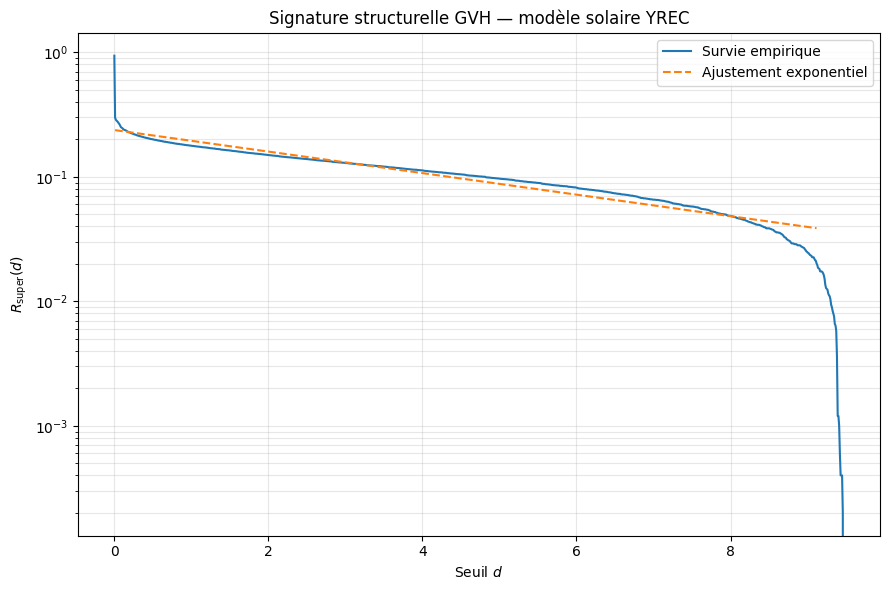


Contrôles
---------
A_H positif : True
B_H positif : True
R² défini   : True
Fit suffisant: True


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.plot(
    solar_survival_table["threshold_d"],
    solar_survival_table["R_super_survival"],
    label="Survie empirique",
)

plt.plot(
    solar_fit_table["threshold_d"],
    solar_fit_table["R_super_fitted"],
    linestyle="--",
    label="Ajustement exponentiel",
)

plt.yscale("log")
plt.xlabel(r"Seuil $d$")
plt.ylabel(r"$R_{\rm super}(d)$")
plt.title("Signature structurelle GVH — modèle solaire YREC")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\nContrôles")
print("---------")
print("A_H positif :", solar_survival_results["A_H"] > 0.0)
print("B_H positif :", solar_survival_results["B_H"] > 0.0)
print("R² défini   :", np.isfinite(solar_survival_results["R2_log"]))
print(
    "Fit suffisant:",
    solar_survival_results["fit_point_count"] >= 3,
)

Signature structurelle GVH
--------------------------
Modèle              : 1146
Nombre de seuils    : 1000
Points du fit       : 962
d minimal du fit    : 9.4766335948e-03
d maximal du fit    : 9.1165215182e+00
A_H                 : 2.3764296364e-01
B_H                 : 1.9909463234e-01
1 / B_H             : 5.0227371189e+00
R² semi-log         : 9.4770510749e-01
RMSE semi-log       : 1.2308096197e-01
RMSE linéaire       : 9.8983436793e-03


,Observable,Valeur
0,A_H,0.237643
1,B_H,0.199095
2,1_over_B_H,5.022737
3,R2_log,0.947705
4,RMSE_log,0.123081
5,RMSE_linear,0.009898
6,d_fit_min,0.009477
7,d_fit_max,9.116522
8,fit_point_count,962.000000



Premiers seuils :


,threshold_d,R_super_survival
0,0.000000,0.9402
1,0.009477,0.2988
2,0.018953,0.2880
3,0.028430,0.2826
4,0.037907,0.2796
5,0.047383,0.2746
6,0.056860,0.2696
7,0.066336,0.2646
8,0.075813,0.2574
9,0.085290,0.2508



Derniers seuils :


,threshold_d,R_super_survival
990,9.381867,0.0036
991,9.391344,0.0012
992,9.400821,0.0012
993,9.410297,0.0010
994,9.419774,0.0006
995,9.429250,0.0004
996,9.438727,0.0004
997,9.448204,0.0004
998,9.457680,0.0002
999,9.467157,0.0000


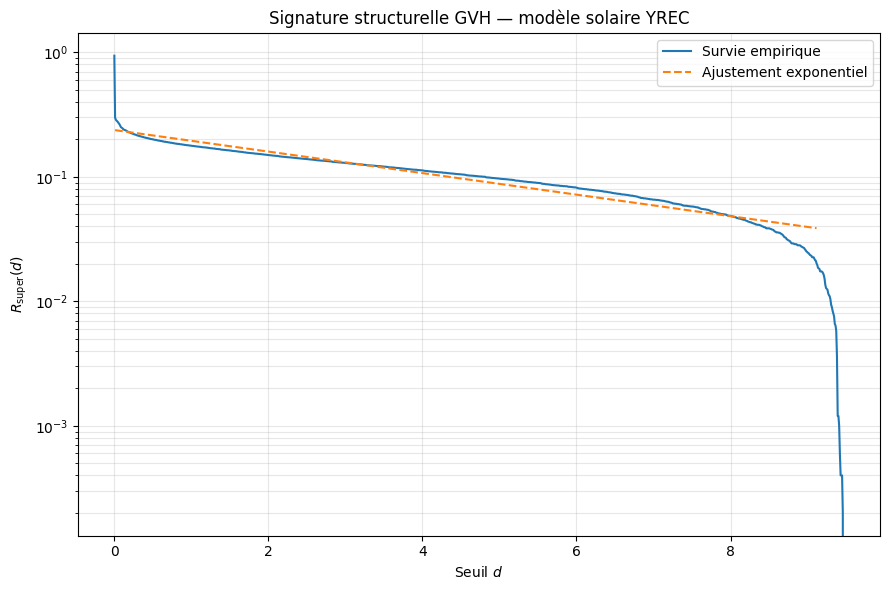


Contrôles
---------
A_H positif : True
B_H positif : True
R² défini   : True
Fit suffisant: True


In [ ]:
# ============================================================
# 48. Signature structurelle du modèle solaire YREC
# ============================================================

solar_survival_results = fit_gvh_survival_signature(
    solar_gvh_results,
    n_thresholds=1000,
    survival_min=0.02,
    survival_max=0.80,
    exclude_zero_threshold=True,
    verbose=True,
)

solar_survival_table = (
    solar_survival_results[
        "survival_table"
    ]
)

solar_fit_table = (
    solar_survival_results[
        "fit_table"
    ]
)

signature_summary = pd.DataFrame(
    {
        "Observable": [
            "A_H",
            "B_H",
            "1_over_B_H",
            "R2_log",
            "RMSE_log",
            "RMSE_linear",
            "d_fit_min",
            "d_fit_max",
            "fit_point_count",
        ],
        "Valeur": [
            solar_survival_results["A_H"],
            solar_survival_results["B_H"],
            solar_survival_results["inverse_B_H"],
            solar_survival_results["R2_log"],
            solar_survival_results["RMSE_log"],
            solar_survival_results["RMSE_linear"],
            solar_survival_results["d_fit_min"],
            solar_survival_results["d_fit_max"],
            solar_survival_results["fit_point_count"],
        ],
    }
)

display(
    signature_summary
)

print("\nPremiers seuils :")

display(
    solar_survival_table.head(10)
)

print("\nDerniers seuils :")

display(
    solar_survival_table.tail(10)
)

plt.figure(figsize=(9, 6))

plt.plot(
    solar_survival_table[
        "threshold_d"
    ],
    solar_survival_table[
        "R_super_survival"
    ],
    label="Survie empirique",
)

plt.plot(
    solar_fit_table[
        "threshold_d"
    ],
    solar_fit_table[
        "R_super_fitted"
    ],
    linestyle="--",
    label="Ajustement exponentiel",
)

plt.yscale("log")

plt.xlabel(
    r"Seuil $d$"
)

plt.ylabel(
    r"$R_{\rm super}(d)$"
)

plt.title(
    "Signature structurelle GVH — modèle solaire YREC"
)

plt.grid(
    True,
    which="both",
    alpha=0.3,
)

plt.legend()
plt.tight_layout()
plt.show()

print("\nContrôles")
print("---------")

print(
    "A_H positif :",
    solar_survival_results["A_H"] > 0.0,
)

print(
    "B_H positif :",
    solar_survival_results["B_H"] > 0.0,
)

print(
    "R² défini   :",
    np.isfinite(
        solar_survival_results["R2_log"]
    ),
)

print(
    "Fit suffisant:",
    solar_survival_results[
        "fit_point_count"
    ] >= 3,
)

In [ ]:
# ============================================================
# 49. Analyse GVH complète d'un modèle YREC
# ============================================================

def analyze_yrec_model_gvh(
    store_df,
    model_id=None,
    *,
    n_radial=5000,
    critical_quantile=0.95,
    n_thresholds=1000,
    survival_min=0.02,
    survival_max=0.80,
    center_mode="constant",
    clip_negative=True,
    luminosity_reference_erg_s=3.8418e33,
    verbose=True,
):
    """
    Exécute toute la chaîne d'analyse GVH pour un modèle YREC :

        1. extraction du modèle ;
        2. validation énergétique ;
        3. préparation du profil radial uniforme ;
        4. calcul des observables GVH ;
        5. ajustement de la signature de survie.

    Paramètres
    ----------
    store_df : pandas.DataFrame
        Table complète retournée par `read_yrec_store()`.

    model_id : int ou None
        Numéro du modèle à analyser.
        Si None, le dernier modèle disponible est sélectionné.

    n_radial : int
        Nombre de points de la grille radiale uniforme.

    critical_quantile : float
        Quantile définissant D_c.

    n_thresholds : int
        Nombre de seuils de la courbe de survie.

    survival_min, survival_max : float
        Plage de survie utilisée pour l'ajustement exponentiel.

    center_mode : {"constant", "linear"}
        Convention de reconstruction du centre.

    clip_negative : bool
        Force epsilon_nuc >= 0 lors de la préparation du profil.

    luminosity_reference_erg_s : float
        Luminosité solaire de référence.

    verbose : bool
        Affiche un résumé de l'analyse.

    Retour
    ------
    dict
        Contient :
        - model
        - energy_balance
        - gvh_profile
        - gvh_results
        - survival_results
        - summary_row
    """

    # --------------------------------------------------------
    # 1. Extraction du modèle
    # --------------------------------------------------------

    model = extract_yrec_model(
        store_df,
        model_id=model_id,
        luminosity_reference_erg_s=(
            luminosity_reference_erg_s
        ),
        verbose=False,
    )

    selected_model_id = model.attrs.get(
        "model_id",
        model_id,
    )

    # --------------------------------------------------------
    # 2. Validation énergétique
    # --------------------------------------------------------

    energy_balance = validate_yrec_energy_balance(
        model,
        luminosity_reference_erg_s=(
            luminosity_reference_erg_s
        ),
        verbose=False,
    )

    # --------------------------------------------------------
    # 3. Profil radial uniforme
    # --------------------------------------------------------

    gvh_profile = prepare_yrec_gvh_profile(
        model,
        n_radial=n_radial,
        center_mode=center_mode,
        clip_negative=clip_negative,
        verbose=False,
    )

    # --------------------------------------------------------
    # 4. Observables GVH radiales
    # --------------------------------------------------------

    gvh_results = compute_radial_gvh_observables(
        gvh_profile,
        critical_quantile=critical_quantile,
        verbose=False,
    )

    # --------------------------------------------------------
    # 5. Signature de survie
    # --------------------------------------------------------

    survival_results = fit_gvh_survival_signature(
        gvh_results,
        n_thresholds=n_thresholds,
        survival_min=survival_min,
        survival_max=survival_max,
        exclude_zero_threshold=True,
        verbose=False,
    )

    # --------------------------------------------------------
    # 6. Métadonnées physiques
    # --------------------------------------------------------

    diagnostics = model.attrs.get(
        "diagnostics",
        {},
    )

    surface_radius_cm = diagnostics.get(
        "surface_radius_cm",
        float(model["radius_cm"].max()),
    )

    surface_mass_g = diagnostics.get(
        "surface_mass_g",
        float(model["mass_g"].max()),
    )

    central_temperature_K = diagnostics.get(
        "central_temperature_K",
        float(model["temperature_K"].iloc[0]),
    )

    central_density_g_cm3 = diagnostics.get(
        "central_density_g_cm3",
        float(model["density_g_cm3"].iloc[0]),
    )

    epsilon_nuc_max_W_m3 = diagnostics.get(
        "epsilon_nuc_max_W_m3",
        float(model["epsilon_nuc_W_m3"].max()),
    )

    # --------------------------------------------------------
    # 7. Ligne récapitulative
    # --------------------------------------------------------

    summary_row = {
        "model_id": selected_model_id,
        "shell_count": len(model),
        "grid_point_count": n_radial,
        "threshold_count": n_thresholds,

        "surface_mass_g": surface_mass_g,
        "surface_radius_cm": surface_radius_cm,
        "surface_luminosity_fraction": (
            energy_balance["L_surface_fraction"]
        ),

        "central_temperature_K": (
            central_temperature_K
        ),
        "central_density_g_cm3": (
            central_density_g_cm3
        ),
        "epsilon_nuc_max_W_m3": (
            epsilon_nuc_max_W_m3
        ),

        "L_nuc_erg_s": (
            energy_balance["L_nuc_erg_s"]
        ),
        "L_grav_erg_s": (
            energy_balance["L_grav_erg_s"]
        ),
        "L_neu_erg_s": (
            energy_balance["L_neu_erg_s"]
        ),
        "L_surface_erg_s": (
            energy_balance["L_surface_erg_s"]
        ),
        "luminosity_relative_error": (
            energy_balance["relative_error_nuc"]
        ),

        "D_T_mean": (
            gvh_results["D_T_mean"]
        ),
        "S_T": (
            gvh_results["S_T"]
        ),
        "S_T_norm": (
            gvh_results["S_T_norm"]
        ),
        "D_c": (
            gvh_results["D_c"]
        ),
        "R_super": (
            gvh_results["R_super"]
        ),
        "D_T_max": (
            gvh_results["D_T_max"]
        ),
        "R_at_D_T_max": (
            gvh_results["R_at_D_T_max"]
        ),
        "R_super_min": (
            gvh_results["R_super_min"]
        ),
        "R_super_max": (
            gvh_results["R_super_max"]
        ),
        "R_super_width": (
            gvh_results["R_super_width"]
        ),

        "A_H": (
            survival_results["A_H"]
        ),
        "B_H": (
            survival_results["B_H"]
        ),
        "inverse_B_H": (
            survival_results["inverse_B_H"]
        ),
        "R2_log": (
            survival_results["R2_log"]
        ),
        "RMSE_log": (
            survival_results["RMSE_log"]
        ),
        "RMSE_linear": (
            survival_results["RMSE_linear"]
        ),
        "fit_point_count": (
            survival_results["fit_point_count"]
        ),
        "d_fit_min": (
            survival_results["d_fit_min"]
        ),
        "d_fit_max": (
            survival_results["d_fit_max"]
        ),

        "critical_quantile": critical_quantile,
        "survival_min": survival_min,
        "survival_max": survival_max,
        "center_mode": center_mode,
    }

    result = {
        "model": model,
        "energy_balance": energy_balance,
        "gvh_profile": gvh_profile,
        "gvh_results": gvh_results,
        "survival_results": survival_results,
        "summary_row": summary_row,
    }

    if verbose:
        print("Analyse GVH complète du modèle YREC")
        print("-----------------------------------")
        print(
            f"Modèle                  : "
            f"{selected_model_id}"
        )
        print(
            f"Coquilles               : "
            f"{len(model)}"
        )
        print(
            f"Erreur luminosité       : "
            f"{100.0 * summary_row['luminosity_relative_error']:.6f} %"
        )
        print(
            f"D_T_max                 : "
            f"{summary_row['D_T_max']:.10e}"
        )
        print(
            f"r(D_T_max)              : "
            f"{summary_row['R_at_D_T_max']:.10e}"
        )
        print(
            f"S_T_norm                : "
            f"{summary_row['S_T_norm']:.10e}"
        )
        print(
            f"A_H                     : "
            f"{summary_row['A_H']:.10e}"
        )
        print(
            f"B_H                     : "
            f"{summary_row['B_H']:.10e}"
        )
        print(
            f"1 / B_H                 : "
            f"{summary_row['inverse_B_H']:.10e}"
        )
        print(
            f"R² semi-log             : "
            f"{summary_row['R2_log']:.10e}"
        )

    return result

In [ ]:
# Liste des modèles disponibles
model_ids = sorted(
    solar_store_df["MODEL"].unique()
)

print(f"Nombre de modèles : {len(model_ids)}")
print(model_ids[:10])
print("...")
print(model_ids[-10:])

Nombre de modèles : 3
[np.int64(62), np.int64(1000), np.int64(1146)]
...
[np.int64(62), np.int64(1000), np.int64(1146)]


In [ ]:
sequence_rows = []

for model_id in model_ids:
    result = analyze_yrec_model_gvh(
        store_df,
        model_id=model_id,
        verbose=False,
    )

    sequence_rows.append(
        result["summary_row"]
    )

sequence_table = pd.DataFrame(
    sequence_rows
).sort_values("model_id")

In [ ]:
sequence_rows = []

for model_id in model_ids:
    result = analyze_yrec_model_gvh(
        solar_store_df,
        model_id=model_id,
        verbose=False,
    )

    sequence_rows.append(result["summary_row"])

sequence_table = (
    pd.DataFrame(sequence_rows)
    .sort_values("model_id")
    .reset_index(drop=True)
)

display(sequence_table.head())

,model_id,shell_count,grid_point_count,threshold_count,surface_mass_g,surface_radius_cm,surface_luminosity_fraction,central_temperature_K,central_density_g_cm3,epsilon_nuc_max_W_m3,...,R2_log,RMSE_log,RMSE_linear,fit_point_count,d_fit_min,d_fit_max,critical_quantile,survival_min,survival_max,center_mode
0,62,747,5000,1000,1.989000e+33,2.910780e+11,6.130246,1.856530e+06,0.123483,0.205488,...,0.889266,0.186973,0.023852,991,0.004927,4.882743,0.95,0.02,0.8,constant
1,1000,859,5000,1000,1.989000e+33,6.361152e+10,0.775506,1.369076e+07,90.702536,135.028866,...,0.924899,0.149799,0.013192,974,0.007599,7.400990,0.95,0.02,0.8,constant
2,1146,871,5000,1000,1.989000e+33,6.957214e+10,1.000032,1.535626e+07,146.746618,241.222091,...,0.947705,0.123081,0.009898,962,0.009477,9.116522,0.95,0.02,0.8,constant


In [ ]:
# ============================================================
# Tableau scientifique réduit de la séquence GVH–YREC
# ============================================================

reduced_columns = [
    "model_id",
    "shell_count",
    "surface_luminosity_fraction",
    "central_temperature_K",
    "central_density_g_cm3",
    "epsilon_nuc_max_W_m3",
    "D_T_mean",
    "S_T",
    "S_T_norm",
    "D_c",
    "R_super",
    "D_T_max",
    "R_at_D_T_max",
    "R_super_width",
    "A_H",
    "B_H",
    "inverse_B_H",
    "R2_log",
    "RMSE_log",
    "luminosity_relative_error",
]

missing_columns = [
    column
    for column in reduced_columns
    if column not in sequence_table.columns
]

if missing_columns:
    raise RuntimeError(
        "Colonnes absentes de sequence_table : "
        + ", ".join(missing_columns)
    )

stellar_gvh_table = (
    sequence_table[reduced_columns]
    .copy()
    .sort_values("model_id")
    .reset_index(drop=True)
)

# Noms plus lisibles pour l'affichage et l'export
stellar_gvh_table = stellar_gvh_table.rename(
    columns={
        "surface_luminosity_fraction": "L_over_Lsun",
        "central_temperature_K": "T_c_K",
        "central_density_g_cm3": "rho_c_g_cm3",
        "epsilon_nuc_max_W_m3": "epsilon_nuc_max_W_m3",
        "R_at_D_T_max": "r_at_D_T_max_over_Rstar",
        "R_super_width": "supercritical_width_over_Rstar",
        "inverse_B_H": "one_over_B_H",
        "luminosity_relative_error": "energy_balance_rel_error",
    }
)

display(stellar_gvh_table)

,model_id,shell_count,L_over_Lsun,T_c_K,rho_c_g_cm3,epsilon_nuc_max_W_m3,D_T_mean,S_T,S_T_norm,D_c,R_super,D_T_max,r_at_D_T_max_over_Rstar,supercritical_width_over_Rstar,A_H,B_H,one_over_B_H,R2_log,RMSE_log,energy_balance_rel_error
0,62,747,6.130246,1.856530e+06,0.123483,0.205488,0.9998,1.617797,1.618120,4.708598,0.0498,4.922160,0.130626,0.04961,0.449102,0.375908,2.660223,0.889266,0.186973,0.936358
1,1000,859,0.775506,1.369076e+07,90.702536,135.028866,0.9998,2.110462,2.110885,6.797685,0.0500,7.590954,0.076415,0.04981,0.294255,0.246056,4.064108,0.924899,0.149799,0.003365
2,1146,871,1.000032,1.535626e+07,146.746618,241.222091,0.9998,2.385479,2.385956,7.905302,0.0500,9.467157,0.056011,0.04981,0.237643,0.199095,5.022737,0.947705,0.123081,0.003379


In [ ]:
# ============================================================
# Vue compacte pour l'interprétation scientifique
# ============================================================

compact_columns = [
    "model_id",
    "L_over_Lsun",
    "T_c_K",
    "rho_c_g_cm3",
    "epsilon_nuc_max_W_m3",
    "D_T_max",
    "r_at_D_T_max_over_Rstar",
    "S_T_norm",
    "A_H",
    "B_H",
    "one_over_B_H",
    "R2_log",
]

stellar_gvh_compact = (
    stellar_gvh_table[compact_columns]
    .copy()
)

display(stellar_gvh_compact)

,model_id,L_over_Lsun,T_c_K,rho_c_g_cm3,epsilon_nuc_max_W_m3,D_T_max,r_at_D_T_max_over_Rstar,S_T_norm,A_H,B_H,one_over_B_H,R2_log
0,62,6.130246,1.856530e+06,0.123483,0.205488,4.922160,0.130626,1.618120,0.449102,0.375908,2.660223,0.889266
1,1000,0.775506,1.369076e+07,90.702536,135.028866,7.590954,0.076415,2.110885,0.294255,0.246056,4.064108,0.924899
2,1146,1.000032,1.535626e+07,146.746618,241.222091,9.467157,0.056011,2.385956,0.237643,0.199095,5.022737,0.947705


In [ ]:
# ============================================================
# 51. Lecture générique du fichier YREC .track
# ============================================================

from pathlib import Path
from io import StringIO
import re

TRACK_FILE = (
    TEST_OUTPUT_DIR
    / "Test_solarGS98_kurucz.track"
)

if not TRACK_FILE.exists():
    raise FileNotFoundError(
        f"Fichier .track introuvable : {TRACK_FILE}"
    )

track_lines = TRACK_FILE.read_text(
    encoding="utf-8",
    errors="replace",
).splitlines()

print("Inspection du fichier .track")
print("----------------------------")
print("Fichier       :", TRACK_FILE)
print("Nombre lignes :", len(track_lines))
print("Taille        :", TRACK_FILE.stat().st_size, "octets")

print("\nPremières lignes :")

for line_number, line in enumerate(
    track_lines[:80],
    start=1,
):
    print(f"{line_number:04d} | {line}")

Inspection du fichier .track
----------------------------
Fichier       : /content/yrec_output/testsuite/Test_solarGS98_kurucz.track
Nombre lignes : 1096
Taille        : 1398383 octets

Premières lignes :
0001 | #
0002 | #====================================================================================================
0003 | # YREC v202602 (d2f5c88)
0004 | # DESCRIPTION OF RUN:YREC release paper test suite                                                   
0005 | #                   : Solar model, GS98 mixture, Kurucz atmospheres                                   
0006 | #====================================================================================================
0007 | #Version=  0  Mtot/Msun =  1.00000000E+00  Initial: X =  7.19600000E-01 Z =  1.64920000E-02  Mix. length =  1.80327900E+00
0008 | # 
0009 |      Step    Shls         Age_gyr       LogL_lsun       LogR_rsun           Log_g        log_Teff        Mco_core         Mco_env     Rco_env     Tco_env     Dco_env     

In [ ]:
# ============================================================
# 52. Lecture corrigée du fichier YREC .track
# ============================================================

def read_yrec_track(
    track_path,
    *,
    verbose=True,
):
    """
    Lit un fichier YREC `.track`.

    Dans cette version de YREC :
    - Step joue le rôle d'identifiant du modèle ;
    - Age_gyr contient directement l'âge en Gyr.
    """

    track_path = Path(track_path)

    if not track_path.exists():
        raise FileNotFoundError(track_path)

    lines = track_path.read_text(
        encoding="utf-8",
        errors="replace",
    ).splitlines()

    header_index = None
    column_names = None

    for index, line in enumerate(lines):

        cleaned = line.lstrip("#").strip()

        if not cleaned:
            continue

        tokens = cleaned.split()

        tokens_upper = {
            token.upper()
            for token in tokens
        }

        has_step = "STEP" in tokens_upper

        has_age = any(
            token in tokens_upper
            for token in {
                "AGE_GYR",
                "AGE",
                "AGE_YR",
                "AGE_YRS",
            }
        )

        if has_step and has_age:
            header_index = index
            column_names = tokens
            break

    if header_index is None:
        raise RuntimeError(
            "L'en-tête Step / Age_gyr n'a pas été détecté."
        )

    expected_count = len(column_names)

    valid_rows = []
    rejected_rows = []

    for line_number, line in enumerate(
        lines[header_index + 1:],
        start=header_index + 2,
    ):

        stripped = line.strip()

        if not stripped:
            continue

        if stripped.startswith("#"):
            continue

        tokens = stripped.split()

        if len(tokens) != expected_count:
            rejected_rows.append(
                {
                    "line_number": line_number,
                    "token_count": len(tokens),
                    "content": stripped[:160],
                }
            )
            continue

        valid_rows.append(tokens)

    if not valid_rows:
        raise RuntimeError(
            "Aucune ligne numérique compatible avec "
            "l'en-tête du fichier .track."
        )

    track_df = pd.DataFrame(
        valid_rows,
        columns=column_names,
    )

    for column in track_df.columns:
        track_df[column] = pd.to_numeric(
            track_df[column],
            errors="coerce",
        )

    track_df = (
        track_df
        .dropna(
            subset=[
                "Step",
                "Age_gyr",
            ]
        )
        .reset_index(drop=True)
    )

    track_df["Step"] = (
        track_df["Step"]
        .astype(int)
    )

    diagnostics = {
        "header_line": header_index + 1,
        "column_count": len(column_names),
        "valid_rows": len(track_df),
        "rejected_rows": len(rejected_rows),
        "step_min": int(track_df["Step"].min()),
        "step_max": int(track_df["Step"].max()),
        "age_min_Gyr": float(
            track_df["Age_gyr"].min()
        ),
        "age_max_Gyr": float(
            track_df["Age_gyr"].max()
        ),
    }

    track_df.attrs["diagnostics"] = diagnostics
    track_df.attrs["rejected_rows"] = rejected_rows

    if verbose:
        print("Lecture YREC .track terminée")
        print("----------------------------")
        print(
            "Ligne d'en-tête    :",
            diagnostics["header_line"],
        )
        print(
            "Nombre de colonnes :",
            diagnostics["column_count"],
        )
        print(
            "Lignes valides     :",
            diagnostics["valid_rows"],
        )
        print(
            "Lignes rejetées    :",
            diagnostics["rejected_rows"],
        )
        print(
            "Intervalle Step    :",
            diagnostics["step_min"],
            "à",
            diagnostics["step_max"],
        )
        print(
            "Intervalle d'âge   :",
            f"{diagnostics['age_min_Gyr']:.6e}",
            "à",
            f"{diagnostics['age_max_Gyr']:.6e}",
            "Gyr",
        )

    return track_df


solar_track_df = read_yrec_track(
    TRACK_FILE,
    verbose=True,
)

display(
    solar_track_df.head()
)

display(
    solar_track_df.tail()
)

Lecture YREC .track terminée
----------------------------
Ligne d'en-tête    : 9
Nombre de colonnes : 83
Lignes valides     : 1086
Lignes rejetées    : 0
Intervalle Step    : 61 à 1146
Intervalle d'âge   : 1.611017e-04 à 4.568000e+00 Gyr


,Step,Shls,Age_gyr,LogL_lsun,LogR_rsun,Log_g,log_Teff,Mco_core,Mco_env,Rco_env,...,Vrot_kms,TauCZ_s,MHshell_base,MHshell_mid,MHshell_top,RHshell_base,RHShell_mid,RHshell_top,logP_phot,Mass_msun
0,61,710,0.000161,0.790545,0.623219,3.191642,3.647351,0.0,1.0,1.437400e-10,...,0.0,17076123.5,0.0,0.0,0.0,0.0,0.0,0.0,4.370971,1.0
1,62,710,0.000163,0.787478,0.621587,3.194906,3.647400,0.0,1.0,1.437400e-10,...,0.0,16690472.1,0.0,0.0,0.0,0.0,0.0,0.0,4.372820,1.0
2,63,710,0.000165,0.785143,0.620345,3.197392,3.647438,0.0,1.0,1.437400e-10,...,0.0,16649265.4,0.0,0.0,0.0,0.0,0.0,0.0,4.374227,1.0
3,64,709,0.000166,0.783099,0.619256,3.199568,3.647470,0.0,1.0,1.437400e-10,...,0.0,16612097.0,0.0,0.0,0.0,0.0,0.0,0.0,4.375460,1.0
4,65,709,0.000168,0.781101,0.618202,3.201678,3.647498,0.0,1.0,1.437400e-10,...,0.0,16575216.1,0.0,0.0,0.0,0.0,0.0,0.0,4.376668,1.0


,Step,Shls,Age_gyr,LogL_lsun,LogR_rsun,Log_g,log_Teff,Mco_core,Mco_env,Rco_env,...,Vrot_kms,TauCZ_s,MHshell_base,MHshell_mid,MHshell_top,RHshell_base,RHShell_mid,RHshell_top,logP_phot,Mass_msun
1081,1142,795,4.489896,-0.002744,-0.001045,4.440170,3.761160,0.0,0.020429,0.72503,...,0.0,893197.254,0.0,0.0,0.0,0.0,0.0,0.0,4.932480,1.0
1082,1143,793,4.513082,-0.001936,-0.000733,4.439547,3.761207,0.0,0.020402,0.72553,...,0.0,892746.515,0.0,0.0,0.0,0.0,0.0,0.0,4.932060,1.0
1083,1144,793,4.536249,-0.001128,-0.000420,4.438921,3.761252,0.0,0.020374,0.72603,...,0.0,892274.509,0.0,0.0,0.0,0.0,0.0,0.0,4.931639,1.0
1084,1145,795,4.559398,-0.000320,-0.000108,4.438296,3.761298,0.0,0.020347,0.72654,...,0.0,891810.502,0.0,0.0,0.0,0.0,0.0,0.0,4.931218,1.0
1085,1146,795,4.568000,0.000014,0.000013,4.438054,3.761321,0.0,0.020332,0.72674,...,0.0,891546.350,0.0,0.0,0.0,0.0,0.0,0.0,4.931047,1.0


In [ ]:
# ============================================================
# 53. Table de correspondance Step ↔ âge
# ============================================================

model_age_table = (
    solar_track_df[
        [
            "Step",
            "Age_gyr",
        ]
    ]
    .copy()
    .rename(
        columns={
            "Step": "model_id",
            "Age_gyr": "age_Gyr",
        }
    )
    .drop_duplicates(
        subset="model_id",
        keep="last",
    )
    .sort_values("model_id")
    .reset_index(drop=True)
)

print(
    "Nombre de correspondances modèle–âge :",
    len(model_age_table),
)

display(
    model_age_table.head(20)
)

display(
    model_age_table.tail(20)
)

print("\nÂges des modèles GVH déjà analysés :")

display(
    model_age_table[
        model_age_table["model_id"].isin(
            stellar_gvh_table["model_id"]
        )
    ]
)

Nombre de correspondances modèle–âge : 1086


,model_id,age_Gyr
0,61,0.000161
1,62,0.000163
2,63,0.000165
3,64,0.000166
4,65,0.000168
5,66,0.000169
6,67,0.000170
7,68,0.000172
8,69,0.000173
9,70,0.000174


,model_id,age_Gyr
1066,1127,4.139903
1067,1128,4.163366
1068,1129,4.186810
1069,1130,4.210236
1070,1131,4.233643
1071,1132,4.257032
1072,1133,4.280402
1073,1134,4.303753
1074,1135,4.327085
1075,1136,4.350399



Âges des modèles GVH déjà analysés :


,model_id,age_Gyr
1,62,0.000163
939,1000,1.019266
1085,1146,4.568000


In [ ]:
# ============================================================
# 54. Fusion des âges avec le tableau scientifique GVH
# ============================================================

stellar_gvh_age_table = (
    stellar_gvh_table
    .merge(
        model_age_table,
        on="model_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values("age_Gyr")
    .reset_index(drop=True)
)

missing_age_count = int(
    stellar_gvh_age_table[
        "age_Gyr"
    ].isna().sum()
)

print(
    "Modèles sans âge associé :",
    missing_age_count,
)

if missing_age_count > 0:
    print(
        stellar_gvh_age_table.loc[
            stellar_gvh_age_table[
                "age_Gyr"
            ].isna(),
            "model_id",
        ].tolist()
    )

scientific_evolution_table = (
    stellar_gvh_age_table[
        [
            "model_id",
            "age_Gyr",
            "L_over_Lsun",
            "T_c_K",
            "rho_c_g_cm3",
            "epsilon_nuc_max_W_m3",
            "r_at_D_T_max_over_Rstar",
            "D_T_max",
            "S_T_norm",
            "A_H",
            "B_H",
            "one_over_B_H",
            "R2_log",
            "energy_balance_rel_error",
        ]
    ]
    .copy()
)

display(
    scientific_evolution_table
)

Modèles sans âge associé : 0


,model_id,age_Gyr,L_over_Lsun,T_c_K,rho_c_g_cm3,epsilon_nuc_max_W_m3,r_at_D_T_max_over_Rstar,D_T_max,S_T_norm,A_H,B_H,one_over_B_H,R2_log,energy_balance_rel_error
0,62,0.000163,6.130246,1.856530e+06,0.123483,0.205488,0.130626,4.922160,1.618120,0.449102,0.375908,2.660223,0.889266,0.936358
1,1000,1.019266,0.775506,1.369076e+07,90.702536,135.028866,0.076415,7.590954,2.110885,0.294255,0.246056,4.064108,0.924899,0.003365
2,1146,4.568000,1.000032,1.535626e+07,146.746618,241.222091,0.056011,9.467157,2.385956,0.237643,0.199095,5.022737,0.947705,0.003379


In [ ]:
# ============================================================
# 55. Vérification des colonnes du fichier YREC .track
# ============================================================

print("Colonnes disponibles dans solar_track_df :")
print(list(solar_track_df.columns))

required_track_columns = [
    "Step",
    "Age_gyr",
]

missing_track_columns = [
    column
    for column in required_track_columns
    if column not in solar_track_df.columns
]

if missing_track_columns:
    raise RuntimeError(
        "Colonnes nécessaires absentes du fichier .track : "
        + ", ".join(missing_track_columns)
    )

print("\nColonnes modèle et âge détectées avec succès.")
print("Identifiant du modèle : Step")
print("Âge physique          : Age_gyr")

Colonnes disponibles dans solar_track_df :
['Step', 'Shls', 'Age_gyr', 'LogL_lsun', 'LogR_rsun', 'Log_g', 'log_Teff', 'Mco_core', 'Mco_env', 'Rco_env', 'Tco_env', 'Dco_env', 'Pco_env', 'Oco_env', 'LogT_cen', 'LogD_cen', 'logP_cen', 'Beta_cen', 'Eta_cen', 'X_cen', 'Y_cen', 'Z_cen', 'ppI_lsun', 'ppII_lsun', 'ppIII_lsun', 'CNO_lsun', '3a_lsun', 'HeC_lsun', 'Egrav_lsun', 'Neut_lsun', 'Cl_snu', 'Ga_snu', 'pp_neut', 'pep_neut', 'hep_neut', 'Be7_neut', 'B8_neut', 'N13_neut', 'O15_neut', 'F17_neut', 'diag1', 'diag2', 'He3_cen', 'C12_cen', 'C13_cen', 'N14_cen', 'N15_cen', 'O16_cen', 'O17_cen', 'O18_cen', 'He3_sur', 'C12_sur', 'C13_sur', 'N14_sur', 'N15_sur', 'O16_sur', 'O17_sur', 'O18_sur', 'H2_sur', 'Li6_sur', 'Li7_sur', 'Be9_sur', 'X_sur', 'Y_sur', 'Z_sur', 'Z_X_sur', 'Jtot', 'KE_rot_tot', 'I_tot', 'I_cz', 'Omega_sur', 'Omega_cen', 'Prot_sur_d', 'Vrot_kms', 'TauCZ_s', 'MHshell_base', 'MHshell_mid', 'MHshell_top', 'RHshell_base', 'RHShell_mid', 'RHshell_top', 'logP_phot', 'Mass_msun']

Colonne

In [ ]:
# ============================================================
# 56. Construction de la table modèle–âge
# ============================================================

model_age_table = (
    solar_track_df[
        [
            "Step",
            "Age_gyr",
        ]
    ]
    .copy()
    .rename(
        columns={
            "Step": "model_id",
            "Age_gyr": "age_Gyr",
        }
    )
    .dropna()
)

model_age_table["model_id"] = (
    model_age_table["model_id"]
    .astype(int)
)

model_age_table["age_Gyr"] = (
    model_age_table["age_Gyr"]
    .astype(float)
)

model_age_table = (
    model_age_table
    .drop_duplicates(
        subset="model_id",
        keep="last",
    )
    .sort_values("model_id")
    .reset_index(drop=True)
)

print("Table modèle–âge construite")
print("---------------------------")
print(
    "Nombre de modèles :",
    len(model_age_table),
)
print(
    "Model ID minimal  :",
    model_age_table["model_id"].min(),
)
print(
    "Model ID maximal  :",
    model_age_table["model_id"].max(),
)
print(
    "Âge minimal       :",
    f"{model_age_table['age_Gyr'].min():.8f} Gyr",
)
print(
    "Âge maximal       :",
    f"{model_age_table['age_Gyr'].max():.8f} Gyr",
)

display(
    model_age_table.head(15)
)

display(
    model_age_table.tail(15)
)

Table modèle–âge construite
---------------------------
Nombre de modèles : 1086
Model ID minimal  : 61
Model ID maximal  : 1146
Âge minimal       : 0.00016110 Gyr
Âge maximal       : 4.56800000 Gyr


,model_id,age_Gyr
0,61,0.000161
1,62,0.000163
2,63,0.000165
3,64,0.000166
4,65,0.000168
5,66,0.000169
6,67,0.000170
7,68,0.000172
8,69,0.000173
9,70,0.000174


,model_id,age_Gyr
1071,1132,4.257032
1072,1133,4.280402
1073,1134,4.303753
1074,1135,4.327085
1075,1136,4.350399
1076,1137,4.373695
1077,1138,4.396972
1078,1139,4.420231
1079,1140,4.443471
1080,1141,4.466693


In [ ]:
# ============================================================
# 57. Âges des modèles GVH déjà analysés
# ============================================================

analyzed_model_ids = (
    stellar_gvh_table["model_id"]
    .astype(int)
    .tolist()
)

analyzed_model_age_table = (
    model_age_table[
        model_age_table["model_id"].isin(
            analyzed_model_ids
        )
    ]
    .copy()
    .sort_values("model_id")
    .reset_index(drop=True)
)

print("Modèles GVH déjà analysés :")
print(analyzed_model_ids)

print("\nCorrespondance avec les âges :")

display(
    analyzed_model_age_table
)

missing_model_ids = sorted(
    set(analyzed_model_ids)
    - set(
        analyzed_model_age_table["model_id"]
    )
)

print(
    "\nModèles sans âge associé :",
    missing_model_ids,
)

Modèles GVH déjà analysés :
[62, 1000, 1146]

Correspondance avec les âges :


,model_id,age_Gyr
0,62,0.000163
1,1000,1.019266
2,1146,4.568000



Modèles sans âge associé : []


In [ ]:
# ============================================================
# 58. Fusion du tableau GVH avec les âges physiques
# ============================================================

stellar_gvh_age_table = (
    stellar_gvh_table
    .merge(
        model_age_table,
        on="model_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values("age_Gyr")
    .reset_index(drop=True)
)

missing_age_count = int(
    stellar_gvh_age_table[
        "age_Gyr"
    ].isna().sum()
)

print("Fusion modèle–âge terminée")
print("--------------------------")
print(
    "Nombre de modèles GVH :",
    len(stellar_gvh_age_table),
)
print(
    "Âges manquants        :",
    missing_age_count,
)

if missing_age_count > 0:
    print(
        "Modèles concernés :",
        stellar_gvh_age_table.loc[
            stellar_gvh_age_table[
                "age_Gyr"
            ].isna(),
            "model_id",
        ].tolist(),
    )

display(
    stellar_gvh_age_table[
        [
            "model_id",
            "age_Gyr",
            "L_over_Lsun",
            "T_c_K",
            "rho_c_g_cm3",
            "epsilon_nuc_max_W_m3",
            "r_at_D_T_max_over_Rstar",
            "D_T_max",
            "S_T_norm",
            "A_H",
            "B_H",
            "one_over_B_H",
            "R2_log",
        ]
    ]
)

Fusion modèle–âge terminée
--------------------------
Nombre de modèles GVH : 3
Âges manquants        : 0


,model_id,age_Gyr,L_over_Lsun,T_c_K,rho_c_g_cm3,epsilon_nuc_max_W_m3,r_at_D_T_max_over_Rstar,D_T_max,S_T_norm,A_H,B_H,one_over_B_H,R2_log
0,62,0.000163,6.130246,1.856530e+06,0.123483,0.205488,0.130626,4.922160,1.618120,0.449102,0.375908,2.660223,0.889266
1,1000,1.019266,0.775506,1.369076e+07,90.702536,135.028866,0.076415,7.590954,2.110885,0.294255,0.246056,4.064108,0.924899
2,1146,4.568000,1.000032,1.535626e+07,146.746618,241.222091,0.056011,9.467157,2.385956,0.237643,0.199095,5.022737,0.947705


In [ ]:
# ============================================================
# 59. Sélection des modèles proches des âges cibles disponibles
# ============================================================

target_ages_Gyr = np.array(
    [
        0.5,
        1.0,
        2.0,
        4.568,
    ],
    dtype=float,
)

selected_age_rows = []

for target_age in target_ages_Gyr:

    distance = np.abs(
        model_age_table["age_Gyr"]
        - target_age
    )

    nearest_index = int(
        distance.idxmin()
    )

    nearest_row = (
        model_age_table.loc[
            nearest_index
        ]
    )

    selected_age_rows.append(
        {
            "target_age_Gyr": target_age,
            "model_id": int(
                nearest_row["model_id"]
            ),
            "actual_age_Gyr": float(
                nearest_row["age_Gyr"]
            ),
            "age_difference_Gyr": float(
                abs(
                    nearest_row["age_Gyr"]
                    - target_age
                )
            ),
        }
    )

target_model_table = pd.DataFrame(
    selected_age_rows
)

display(target_model_table)

,target_age_Gyr,model_id,actual_age_Gyr,age_difference_Gyr
0,0.500,980,0.505864,0.005864
1,1.000,999,0.993712,0.006288
2,2.000,1039,2.005009,0.005009
3,4.568,1146,4.568000,0.000000


In [ ]:
# ============================================================
# 59. Sélection des modèles stockés proches des âges cibles
# ============================================================

target_ages_Gyr = np.array(
    [0.5, 1.0, 2.0, 4.568],
    dtype=float,
)

available_store_models = np.sort(
    solar_store_df["MODEL"]
    .dropna()
    .astype(int)
    .unique()
)

print(
    "Modèles disponibles dans le .store :",
    available_store_models.tolist(),
)

available_model_age_table = (
    model_age_table[
        model_age_table["model_id"].isin(
            available_store_models
        )
    ]
    .copy()
    .sort_values("age_Gyr")
    .reset_index(drop=True)
)

display(available_model_age_table)

selected_age_rows = []

for target_age in target_ages_Gyr:

    distances = np.abs(
        available_model_age_table["age_Gyr"]
        - target_age
    )

    nearest_index = distances.idxmin()

    nearest_row = available_model_age_table.loc[
        nearest_index
    ]

    selected_age_rows.append(
        {
            "target_age_Gyr": target_age,
            "model_id": int(
                nearest_row["model_id"]
            ),
            "actual_age_Gyr": float(
                nearest_row["age_Gyr"]
            ),
            "age_difference_Gyr": float(
                abs(
                    nearest_row["age_Gyr"]
                    - target_age
                )
            ),
        }
    )

target_model_table = pd.DataFrame(
    selected_age_rows
)

display(target_model_table)

Modèles disponibles dans le .store : [62, 1000, 1146]


,model_id,age_Gyr
0,62,0.000163
1,1000,1.019266
2,1146,4.568000


,target_age_Gyr,model_id,actual_age_Gyr,age_difference_Gyr
0,0.500,62,0.000163,0.499837
1,1.000,1000,1.019266,0.019266
2,2.000,1000,1.019266,0.980734
3,4.568,1146,4.568000,0.000000


In [ ]:
# ============================================================
# 60. Analyse des profils réellement disponibles dans le .store
# ============================================================

stored_model_table = (
    available_model_age_table[
        [
            "model_id",
            "age_Gyr",
        ]
    ]
    .copy()
)

stored_sequence_rows = []
stored_sequence_results = {}

for _, row in stored_model_table.iterrows():

    model_id = int(
        row["model_id"]
    )

    age_Gyr = float(
        row["age_Gyr"]
    )

    print(
        f"Analyse du modèle {model_id} "
        f"à {age_Gyr:.6f} Gyr..."
    )

    result = analyze_yrec_model_gvh(
        solar_store_df,
        model_id=model_id,
        n_radial=5000,
        critical_quantile=0.95,
        n_thresholds=1000,
        survival_min=0.02,
        survival_max=0.80,
        center_mode="constant",
        clip_negative=True,
        luminosity_reference_erg_s=3.8418e33,
        verbose=False,
    )

    summary_row = result[
        "summary_row"
    ].copy()

    summary_row["age_Gyr"] = age_Gyr

    stored_sequence_rows.append(
        summary_row
    )

    stored_sequence_results[
        model_id
    ] = result

stored_sequence_table = (
    pd.DataFrame(stored_sequence_rows)
    .sort_values("age_Gyr")
    .reset_index(drop=True)
)

display(stored_sequence_table)

Analyse du modèle 62 à 0.000163 Gyr...
Analyse du modèle 1000 à 1.019266 Gyr...
Analyse du modèle 1146 à 4.568000 Gyr...


,model_id,shell_count,grid_point_count,threshold_count,surface_mass_g,surface_radius_cm,surface_luminosity_fraction,central_temperature_K,central_density_g_cm3,epsilon_nuc_max_W_m3,...,RMSE_log,RMSE_linear,fit_point_count,d_fit_min,d_fit_max,critical_quantile,survival_min,survival_max,center_mode,age_Gyr
0,62,747,5000,1000,1.989000e+33,2.910780e+11,6.130246,1.856530e+06,0.123483,0.205488,...,0.186973,0.023852,991,0.004927,4.882743,0.95,0.02,0.8,constant,0.000163
1,1000,859,5000,1000,1.989000e+33,6.361152e+10,0.775506,1.369076e+07,90.702536,135.028866,...,0.149799,0.013192,974,0.007599,7.400990,0.95,0.02,0.8,constant,1.019266
2,1146,871,5000,1000,1.989000e+33,6.957214e+10,1.000032,1.535626e+07,146.746618,241.222091,...,0.123081,0.009898,962,0.009477,9.116522,0.95,0.02,0.8,constant,4.568000


In [ ]:
# ============================================================
# 60. Séquence GVH réellement disponible dans le fichier .store
# ============================================================

available_store_models = np.sort(
    solar_store_df["MODEL"]
    .dropna()
    .astype(int)
    .unique()
)

stored_model_age_table = (
    model_age_table[
        model_age_table["model_id"].isin(
            available_store_models
        )
    ]
    .copy()
    .sort_values("age_Gyr")
    .reset_index(drop=True)
)

display(stored_model_age_table)

stored_sequence_rows = []
stored_sequence_results = {}

for _, row in stored_model_age_table.iterrows():

    model_id = int(row["model_id"])
    age_Gyr = float(row["age_Gyr"])

    print(
        f"Analyse du modèle {model_id} "
        f"à {age_Gyr:.6f} Gyr..."
    )

    result = analyze_yrec_model_gvh(
        solar_store_df,
        model_id=model_id,
        n_radial=5000,
        critical_quantile=0.95,
        n_thresholds=1000,
        survival_min=0.02,
        survival_max=0.80,
        center_mode="constant",
        clip_negative=True,
        luminosity_reference_erg_s=3.8418e33,
        verbose=False,
    )

    summary_row = result["summary_row"].copy()
    summary_row["age_Gyr"] = age_Gyr

    stored_sequence_rows.append(summary_row)
    stored_sequence_results[model_id] = result

stored_sequence_table = (
    pd.DataFrame(stored_sequence_rows)
    .sort_values("age_Gyr")
    .reset_index(drop=True)
)

display(stored_sequence_table)

,model_id,age_Gyr
0,62,0.000163
1,1000,1.019266
2,1146,4.568000


Analyse du modèle 62 à 0.000163 Gyr...
Analyse du modèle 1000 à 1.019266 Gyr...
Analyse du modèle 1146 à 4.568000 Gyr...


,model_id,shell_count,grid_point_count,threshold_count,surface_mass_g,surface_radius_cm,surface_luminosity_fraction,central_temperature_K,central_density_g_cm3,epsilon_nuc_max_W_m3,...,RMSE_log,RMSE_linear,fit_point_count,d_fit_min,d_fit_max,critical_quantile,survival_min,survival_max,center_mode,age_Gyr
0,62,747,5000,1000,1.989000e+33,2.910780e+11,6.130246,1.856530e+06,0.123483,0.205488,...,0.186973,0.023852,991,0.004927,4.882743,0.95,0.02,0.8,constant,0.000163
1,1000,859,5000,1000,1.989000e+33,6.361152e+10,0.775506,1.369076e+07,90.702536,135.028866,...,0.149799,0.013192,974,0.007599,7.400990,0.95,0.02,0.8,constant,1.019266
2,1146,871,5000,1000,1.989000e+33,6.957214e+10,1.000032,1.535626e+07,146.746618,241.222091,...,0.123081,0.009898,962,0.009477,9.116522,0.95,0.02,0.8,constant,4.568000


In [ ]:
# ============================================================
# 61. Tableau scientifique de la séquence disponible
# ============================================================

stored_scientific_table = (
    stored_sequence_table[
        [
            "model_id",
            "age_Gyr",
            "surface_luminosity_fraction",
            "central_temperature_K",
            "central_density_g_cm3",
            "epsilon_nuc_max_W_m3",
            "R_at_D_T_max",
            "D_T_max",
            "S_T_norm",
            "A_H",
            "B_H",
            "inverse_B_H",
            "R2_log",
            "RMSE_log",
            "luminosity_relative_error",
        ]
    ]
    .copy()
    .rename(
        columns={
            "surface_luminosity_fraction": "L_over_Lsun",
            "central_temperature_K": "T_c_K",
            "central_density_g_cm3": "rho_c_g_cm3",
            "R_at_D_T_max": "r_at_D_T_max_over_Rstar",
            "inverse_B_H": "one_over_B_H",
            "luminosity_relative_error": "energy_balance_rel_error",
        }
    )
)

display(stored_scientific_table)

print(
    "Aucune valeur manquante :",
    not stored_scientific_table.isna().any().any(),
)

,model_id,age_Gyr,L_over_Lsun,T_c_K,rho_c_g_cm3,epsilon_nuc_max_W_m3,r_at_D_T_max_over_Rstar,D_T_max,S_T_norm,A_H,B_H,one_over_B_H,R2_log,RMSE_log,energy_balance_rel_error
0,62,0.000163,6.130246,1.856530e+06,0.123483,0.205488,0.130626,4.922160,1.618120,0.449102,0.375908,2.660223,0.889266,0.186973,0.936358
1,1000,1.019266,0.775506,1.369076e+07,90.702536,135.028866,0.076415,7.590954,2.110885,0.294255,0.246056,4.064108,0.924899,0.149799,0.003365
2,1146,4.568000,1.000032,1.535626e+07,146.746618,241.222091,0.056011,9.467157,2.385956,0.237643,0.199095,5.022737,0.947705,0.123081,0.003379


Aucune valeur manquante : True


In [ ]:
# ============================================================
# 62. Repérage des paramètres du run solaire YREC
# ============================================================

from pathlib import Path
import re

if not SOLAR_NML1.exists():
    raise FileNotFoundError(SOLAR_NML1)

if not SOLAR_NML2.exists():
    raise FileNotFoundError(SOLAR_NML2)

nml1_text = SOLAR_NML1.read_text(
    encoding="utf-8",
    errors="replace",
)

nml2_text = SOLAR_NML2.read_text(
    encoding="utf-8",
    errors="replace",
)

control_terms = [
    "ENDAGE",
    "NMODLS",
    "SETDT",
    "LFIRST",
    "KINDRN",
    "LCALS",
    "LSTPHYS",
    "LSTCH",
    "FTRACK",
    "FLAST",
    "FSTORE",
    "FSTCH",
    "FMODEL",
    "FSHORT",
    "FSTART",
    "FFIRST",
]

def show_namelist_matches(text, terms, label):
    print(f"\n{label}")
    print("-" * len(label))

    lines = text.splitlines()

    for term in terms:
        matches = [
            (line_number, line)
            for line_number, line in enumerate(lines, start=1)
            if re.search(
                rf"\b{re.escape(term)}\b",
                line,
                flags=re.IGNORECASE,
            )
        ]

        print(f"\n{term}: {len(matches)} occurrence(s)")

        for line_number, line in matches:
            print(f"{line_number:04d} | {line}")


show_namelist_matches(
    nml1_text,
    control_terms,
    "Paramètres détectés dans NML1",
)

show_namelist_matches(
    nml2_text,
    control_terms,
    "Paramètres détectés dans NML2",
)


Paramètres détectés dans NML1
-----------------------------

ENDAGE: 1 occurrence(s)
0045 |  ENDAGE(2) = 4.568D9 ! Run stops if NMODLS(I) is reached or this age is reached

NMODLS: 9 occurrence(s)
0031 |  NMODLS(1) = 2 ! Stop after this number of models. An initial rescaling with 2 models is recommended, followed by an evolve run
0041 |  NMODLS(2) = 10000 
0045 |  ENDAGE(2) = 4.568D9 ! Run stops if NMODLS(I) is reached or this age is reached
0046 |  ! END_DCEN(2) = 2.75d-5 ! Run stops if NMODLS(I) is reached or this central deuterium is reached (D bl, start)
0047 |  ! END_DCEN(2) = 2.75d-7 ! Run stops if NMODLS(I) is reached or this central deuterium is reached (D bl, end)
0048 |  ! END_XCEN(2) = 0.714620 ! Run stops if NMODLS(I) is reached or this central hydrogen is reached (ZAMS)
0049 |  ! END_XCEN(2) = 0.0001 ! Run stops if NMODLS(I) is reached or this central hydrogen is reached (TAMS)
0050 |  ! END_YCEN(2) = 0.0001 ! Run stops if NMODLS(I) is reached or this central helium is re

In [ ]:
# ============================================================
# 63. Création du run isolé YREC à 0,5 Gyr
# ============================================================

import shutil

AGE_RUN_ROOT = Path(
    "/content/yrec_age_sequence"
)

RUN_0P5_DIR = (
    AGE_RUN_ROOT
    / "solar_0p5_Gyr"
)

RUN_0P5_OUTPUT_DIR = (
    RUN_0P5_DIR
    / "output"
)

RUN_0P5_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RUN_0P5_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RUN_0P5_NML1 = (
    RUN_0P5_DIR
    / "solar_0p5_Gyr.nml1"
)

RUN_0P5_NML2 = (
    RUN_0P5_DIR
    / "solar_0p5_Gyr.nml2"
)

shutil.copy2(
    SOLAR_NML1,
    RUN_0P5_NML1,
)

shutil.copy2(
    SOLAR_NML2,
    RUN_0P5_NML2,
)

print("Run isolé préparé")
print("------------------")
print("Répertoire       :", RUN_0P5_DIR)
print("Répertoire sortie:", RUN_0P5_OUTPUT_DIR)
print("NML1             :", RUN_0P5_NML1)
print("NML2             :", RUN_0P5_NML2)

print("\nFichiers officiels inchangés :")
print(SOLAR_NML1)
print(SOLAR_NML2)

Run isolé préparé
------------------
Répertoire       : /content/yrec_age_sequence/solar_0p5_Gyr
Répertoire sortie: /content/yrec_age_sequence/solar_0p5_Gyr/output
NML1             : /content/yrec_age_sequence/solar_0p5_Gyr/solar_0p5_Gyr.nml1
NML2             : /content/yrec_age_sequence/solar_0p5_Gyr/solar_0p5_Gyr.nml2

Fichiers officiels inchangés :
/content/yrec_2026_release/testsuite/Test_solarGS98_kurucz.nml1
/content/yrec_2026_release/testsuite/Test_solarGS98_kurucz.nml2


In [ ]:
# ============================================================
# 64. Inspection ciblée de ENDAGE et des sorties
# ============================================================

run_nml1_lines = RUN_0P5_NML1.read_text(
    encoding="utf-8",
    errors="replace",
).splitlines()

inspection_terms = [
    "ENDAGE",
    "NMODLS",
    "SETDT",
    "FTRACK",
    "FLAST",
    "FSTORE",
    "FSTCH",
    "FMODEL",
    "FSHORT",
]

for term in inspection_terms:
    matches = [
        (line_number, line)
        for line_number, line in enumerate(
            run_nml1_lines,
            start=1,
        )
        if re.search(
            rf"\b{re.escape(term)}\b",
            line,
            flags=re.IGNORECASE,
        )
    ]

    print(f"\n{term}: {len(matches)} occurrence(s)")

    for line_number, line in matches:
        print(f"{line_number:04d} | {line}")


ENDAGE: 1 occurrence(s)
0045 |  ENDAGE(2) = 4.568D9 ! Run stops if NMODLS(I) is reached or this age is reached

NMODLS: 9 occurrence(s)
0031 |  NMODLS(1) = 2 ! Stop after this number of models. An initial rescaling with 2 models is recommended, followed by an evolve run
0041 |  NMODLS(2) = 10000 
0045 |  ENDAGE(2) = 4.568D9 ! Run stops if NMODLS(I) is reached or this age is reached
0046 |  ! END_DCEN(2) = 2.75d-5 ! Run stops if NMODLS(I) is reached or this central deuterium is reached (D bl, start)
0047 |  ! END_DCEN(2) = 2.75d-7 ! Run stops if NMODLS(I) is reached or this central deuterium is reached (D bl, end)
0048 |  ! END_XCEN(2) = 0.714620 ! Run stops if NMODLS(I) is reached or this central hydrogen is reached (ZAMS)
0049 |  ! END_XCEN(2) = 0.0001 ! Run stops if NMODLS(I) is reached or this central hydrogen is reached (TAMS)
0050 |  ! END_YCEN(2) = 0.0001 ! Run stops if NMODLS(I) is reached or this central helium is reached (TAHB)
0051 |  ! END_YCEN(2) = 0.9700 ! Run stops if NM

In [ ]:
# ============================================================
# 65. Configuration du run YREC à 0,5 Gyr
# ============================================================

import re

run_nml1_text = RUN_0P5_NML1.read_text(
    encoding="utf-8",
    errors="replace",
)

replacement_counts = {}

def replace_once(text, pattern, replacement, label):
    updated_text, count = re.subn(
        pattern,
        replacement,
        text,
        count=1,
        flags=re.IGNORECASE | re.MULTILINE,
    )

    replacement_counts[label] = count

    if count != 1:
        raise RuntimeError(
            f"Remplacement {label} impossible ou ambigu : "
            f"{count} occurrence(s)."
        )

    return updated_text


# ------------------------------------------------------------
# Âge final : 0,5 Gyr = 5,0 × 10^8 ans
# ------------------------------------------------------------

run_nml1_text = replace_once(
    run_nml1_text,
    r"^\s*ENDAGE\s*\(\s*2\s*\)\s*=\s*[^!\n]+",
    " ENDAGE(2) = 5.0D8 ",
    "ENDAGE(2)",
)

# ------------------------------------------------------------
# Noms des sorties
# ------------------------------------------------------------

output_replacements = {
    "FLAST": (
        '{YREC_OUTPUT}/solar_0p5_Gyr/'
        'solar_0p5_Gyr.last'
    ),
    "FSTOR": (
        '{YREC_OUTPUT}/solar_0p5_Gyr/'
        'solar_0p5_Gyr.store'
    ),
    "FTRACK": (
        '{YREC_OUTPUT}/solar_0p5_Gyr/'
        'solar_0p5_Gyr.track'
    ),
    "FSHORT": (
        '{YREC_OUTPUT}/solar_0p5_Gyr/'
        'solar_0p5_Gyr.short'
    ),
    "FPMOD": (
        '{YREC_OUTPUT}/solar_0p5_Gyr/'
        'solar_0p5_Gyr.pmod'
    ),
    "FPENV": (
        '{YREC_OUTPUT}/solar_0p5_Gyr/'
        'solar_0p5_Gyr.penv'
    ),
    "FPATM": (
        '{YREC_OUTPUT}/solar_0p5_Gyr/'
        'solar_0p5_Gyr.patm'
    ),
}

for variable, new_path in output_replacements.items():

    pattern = (
        rf'^\s*{variable}\s*=\s*"[^"]*"'
    )

    replacement = (
        f' {variable} = "{new_path}"'
    )

    run_nml1_text = replace_once(
        run_nml1_text,
        pattern,
        replacement,
        variable,
    )

RUN_0P5_NML1.write_text(
    run_nml1_text,
    encoding="utf-8",
)

print("Configuration 0,5 Gyr terminée")
print("--------------------------------")
print("Fichier :", RUN_0P5_NML1)
print()

for label, count in replacement_counts.items():
    print(f"{label:12s} : {count} remplacement")

Configuration 0,5 Gyr terminée
--------------------------------
Fichier : /content/yrec_age_sequence/solar_0p5_Gyr/solar_0p5_Gyr.nml1

ENDAGE(2)    : 1 remplacement
FLAST        : 1 remplacement
FSTOR        : 1 remplacement
FTRACK       : 1 remplacement
FSHORT       : 1 remplacement
FPMOD        : 1 remplacement
FPENV        : 1 remplacement
FPATM        : 1 remplacement
